# 02–04 — Old vs new PRE/POST viewing GLM

This notebook combines three closely related analyses in one two-run GLM, because they use the same regressors and the same first-level maps.

- **02 — PRE old vs new**: baseline old/new difference before island exposure.
- **03 — POST old vs new**: old/new difference after island exposure.
- **04 — POST vs PRE, old vs new**: interaction testing whether the old/new difference increases from PRE to POST.

The notebook is restart-safe: first-level maps are saved immediately, and later cells verify/load existing maps instead of requiring the long first-level GLM to be rerun.


In [3]:
# ============================================================
# 1. Setup
# ============================================================

from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from nilearn.image import load_img

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from island_glm.paths import ProjectPaths, make_analysis_dirs
from island_glm.common import load_common_inputs, get_pre_post_subjects
from island_glm.events import (
    save_old_new_subject_events,
    build_old_new_event_qc,
    make_old_new_events,
)
from island_glm.contrasts import (
    make_old_new_pre_post_contrasts,
    contrast_specs_to_table,
)
from island_glm.first_level import run_old_new_first_level_subject
from island_glm.second_level import (
    first_level_map_path,
    verify_first_level_maps,
    run_second_level_all_contrasts,
    threshold_group_maps,
    make_cluster_tables,
)
from island_glm.reporting import label_cluster_table
from island_glm.plotting import plot_group_stat_map, make_interactive_view

ANALYSIS_NAME = "pre_post_old_new_viewing_glm"
SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"
TEST_SUBJECT = "sub-P15"

# ------------------------------------------------------------
# Runtime flags
# ------------------------------------------------------------

RUN_FIRST_LEVEL = False
OVERWRITE_FIRST_LEVEL = False

RUN_SECOND_LEVEL = True
OVERWRITE_SECOND_LEVEL = True

USE_MEAN_T1W_BACKGROUND = True

paths = ProjectPaths.from_root(PROJECT_ROOT)
dirs = make_analysis_dirs(paths, ANALYSIS_NAME, smoothing_label=SMOOTHING_LABEL)

print("Project root:", paths.project_root)
print("Analysis output:", dirs["out"])


Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Analysis output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm


## Load common inputs from Notebook 00

Notebook 00 defines the final subject list, viewing item labels, filename parsing, checkpoint labels, and the common mean T1w anatomical background.


In [4]:
# ============================================================
# 2. Load common inputs and mean T1w background
# ============================================================

manifest, subject_table, viewing_item_labels = load_common_inputs(paths)
subjects = get_pre_post_subjects(manifest, no_high_motion=False)
sensitivity_subjects = get_pre_post_subjects(manifest, no_high_motion=True)

sessions = manifest["sessions"]

print("Main sample N:", len(subjects))
print("Sensitivity no-high-motion N:", len(sensitivity_subjects))
print("Sessions:", sessions)

assert "mean_anat" in manifest, (
    "Mean anatomical background missing from manifest. "
    "Rerun Notebook 00 after adding the mean T1w section."
)

mean_t1w_path = Path(manifest["mean_anat"]["mean_t1w_path"])
assert mean_t1w_path.exists(), f"Missing mean T1w file: {mean_t1w_path}"

mean_t1w_img = load_img(str(mean_t1w_path))

print("\nLoaded mean T1w anatomical background:")
print(mean_t1w_path)
print("Mean T1w shape:", mean_t1w_img.shape)

display(subject_table)
display(viewing_item_labels.head())


Main sample N: 27
Sensitivity no-high-motion N: 25
Sessions: {'pre': 'ses-01', 'post': 'ses-05', 'task': 'viewing', 'run': '01', 'bold_space': 'MNI152NLin2009cAsym'}

Loaded mean T1w anatomical background:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz
Mean T1w shape: (193, 229, 193)


,subject,included_primary_post_only,included_pre_post_N27,included_pre_post_no_high_motion_N25,excluded_from_pre_post,high_motion_flag,exclusion_reason
0,sub-P10,True,True,True,False,False,NaN
1,sub-P12,True,True,True,False,False,NaN
2,sub-P13,True,True,True,False,False,NaN
3,sub-P14,True,True,True,False,False,NaN
4,sub-P15,True,True,True,False,False,NaN
5,sub-P16,True,True,True,False,False,NaN
6,sub-P17,True,True,True,False,False,NaN
7,sub-P18,True,True,True,False,False,NaN
8,sub-P19,True,True,False,False,True,High-motion sensitivity exclusion.
9,sub-P21,True,True,False,False,True,High-motion sensitivity exclusion.


,subject,session,run,onset,duration,image_file,source_image_column,phase,theme,item_id,episode,episode_number,checkpoint_index,checkpoint_index_out_of,checkpoint_third,relevance_from_filename,object_category_from_filename,old_new,stimulus_version,relevance_condition,spatial_accuracy_z,spatial_accuracy_condition_centered,relevance,encoding_phase_third
0,sub-P10,ses-01,1,4.634,3.017,maya_3_e3_6_r_h_v1_old,event,pre,maya,3.0,e3,3.0,6.0,16,middle,relevant,human,old,1.0,NaN,NaN,NaN,relevant,middle
1,sub-P10,ses-01,1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old,event,pre,wealth,5.0,e3,3.0,7.0,16,middle,irrelevant,object,old,1.0,NaN,NaN,NaN,irrelevant,middle
2,sub-P10,ses-01,1,17.934,3.017,pirate_6_e2_13_r_h_v1_old,event,pre,pirate,6.0,e2,2.0,13.0,16,late,relevant,human,old,1.0,NaN,NaN,NaN,relevant,late
3,sub-P10,ses-01,1,24.534,3.017,viking_11_new,event,pre,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,new,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-P10,ses-01,1,30.451,3.016,pirate_7_e3_1_nr_h_v1_old,event,pre,pirate,7.0,e3,3.0,1.0,16,early,irrelevant,human,old,1.0,NaN,NaN,NaN,irrelevant,early


## Design

For each subject, we estimate one first-level GLM with two runs:

- run 1 = PRE viewing (`ses-01`)
- run 2 = POST viewing (`ses-05`)

The task regressors are:

$$
\beta_{\mathrm{pre,old}},\quad
\beta_{\mathrm{pre,new}},\quad
\beta_{\mathrm{post,old}},\quad
\beta_{\mathrm{post,new}}.
$$

The first-level model also includes fMRIPrep confounds: motion, white matter, CSF, and high-pass cosine regressors.


## Contrasts

### 02 — PRE old vs new

$$
C_{\mathrm{pre,old>new}}
=
\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}.
$$

This is a baseline control: before the island task, old and new images should ideally not already differ strongly.

### 03 — POST old vs new

$$
C_{\mathrm{post,old>new}}
=
\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}.
$$

This tests whether images encountered on the island differ from new control images after learning.

### 04 — POST vs PRE, old vs new

$$
C_{\mathrm{old>new,post>pre}}
=
(\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}})
-
(\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}).
$$

This is the strongest old/new memory contrast because it controls for baseline old/new differences already present at PRE.


In [5]:
# ============================================================
# 3. Define contrasts and save contrast table
# ============================================================

contrast_specs = make_old_new_pre_post_contrasts()
contrast_table = contrast_specs_to_table(contrast_specs)

contrast_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

display(contrast_table)
print("Saved:", contrast_table_path)


,contrast,priority,formula,interpretation,pre_old,pre_new,post_old,post_new
0,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",Baseline old > new difference during PRE viewing.,1.0,-1.0,0.0,0.0
1,post_old_gt_new,03_post_old_vs_new,"$$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$$",Old > new difference during POST viewing after island exposure.,0.0,0.0,1.0,-1.0
2,old_gt_new_post_gt_pre,04_pre_post_old_new_interaction,"$$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}})$$",Tests whether the old-new difference is stronger at POST than PRE.,-1.0,1.0,1.0,-1.0
3,old_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$$",Descriptive POST > PRE change for old images only.,-1.0,0.0,1.0,0.0
4,new_post_gt_pre,descriptive_new_post_pre,"$$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$$",Descriptive POST > PRE change for new images only.,0.0,-1.0,0.0,1.0
5,all_post_gt_pre,descriptive_all_post_pre,"$$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$$",Descriptive average POST > PRE viewing-session effect.,-0.5,-0.5,0.5,0.5


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_contrast_definitions.csv


## Event relabelling

We create one clean event table per subject and phase with four BIDS-compatible columns:

```text
onset, duration, trial_type, modulation
```

Expected counts per subject and phase:

```text
old = 288
new = 96
```


In [6]:
# ============================================================
# 4. Create old/new event files and event-count QC
# ============================================================

for subject in subjects:
    save_old_new_subject_events(
        viewing_item_labels=viewing_item_labels,
        subject=subject,
        events_dir=dirs["events"],
    )

event_qc, all_events_long = build_old_new_event_qc(
    viewing_item_labels=viewing_item_labels,
    subjects=subjects,
    events_dir=dirs["events"],
)

event_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_event_count_qc.csv"
all_events_path = dirs["events"] / f"all_subjects_{ANALYSIS_NAME}_events_long.tsv"

event_qc.to_csv(event_qc_path, index=False)
all_events_long.to_csv(all_events_path, sep="\t", index=False)

print("Saved event QC:", event_qc_path)
print("Saved all events:", all_events_path)

print("\nEvent counts by phase and trial type:")
display(
    all_events_long
    .groupby(["phase", "trial_type"])
    .size()
    .reset_index(name="n")
)

display(event_qc.head())

assert (event_qc["n_old"] == 288).all(), "Expected 288 old trials per subject and phase."
assert (event_qc["n_new"] == 96).all(), "Expected 96 new trials per subject and phase."
assert (event_qc["n_other"] == 0).all(), "Unexpected other trials in old/new GLM."


Saved event QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_event_count_qc.csv
Saved all events: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new_viewing_glm/all_subjects_pre_post_old_new_viewing_glm_events_long.tsv

Event counts by phase and trial type:


,phase,trial_type,n
0,post,post_new,2592
1,post,post_old,7776
2,pre,pre_new,2592
3,pre,pre_old,7776


,subject,phase,n_events,n_old,n_new,n_other,events_path
0,sub-P10,pre,384,288,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new_viewing_glm/sub-P10_pre_task-viewing_o...
1,sub-P10,post,384,288,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new_viewing_glm/sub-P10_post_task-viewing_...
2,sub-P12,pre,384,288,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new_viewing_glm/sub-P12_pre_task-viewing_o...
3,sub-P12,post,384,288,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new_viewing_glm/sub-P12_post_task-viewing_...
4,sub-P13,pre,384,288,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new_viewing_glm/sub-P13_pre_task-viewing_o...


## Single-subject design preview

Before running all subjects, we fit one example subject and inspect the design matrix and contrast vectors. This cell does **not** save first-level contrast maps; it only verifies the design.


In [7]:
# ============================================================
# 5. Single-subject design preview
# ============================================================

subject_qc_preview, contrast_qc_preview = run_old_new_first_level_subject(
    subject=TEST_SUBJECT,
    paths=paths,
    viewing_item_labels=viewing_item_labels,
    contrast_specs=contrast_specs,
    output_dirs=dirs,
    sessions=sessions,
    smoothing_fwhm=SMOOTHING_FWHM,
    smoothing_label=SMOOTHING_LABEL,
    hrf_model="spm",
    save_outputs=False,
    make_design_plot=True,
)

preview_subject_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_design_preview_subject_qc.csv"
preview_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_contrast_vector_preview_qc.csv"

subject_qc_preview.to_csv(preview_subject_qc_path, index=False)
contrast_qc_preview.to_csv(preview_contrast_qc_path, index=False)

print("Subject QC preview:")
display(subject_qc_preview)

print("Contrast-vector preview:")
display(contrast_qc_preview)

assert not contrast_qc_preview.groupby("contrast")["is_null_vector"].all().any()

print("Design and contrast-vector preview passed.")


KeyboardInterrupt: 

## Restart-safe first-level GLM

The first-level GLM is the slow part. This notebook is configured so that:

- `RUN_FIRST_LEVEL=True` fits first-level models and saves maps immediately;
- `RUN_FIRST_LEVEL=False` loads/verifies existing maps;
- `OVERWRITE_FIRST_LEVEL=False` runs only missing or incomplete subjects.

After a successful first run, keep `RUN_FIRST_LEVEL=False`.


In [8]:
# ============================================================
# 6. Run, recover, or load first-level GLM results
# ============================================================

first_level_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = dirs["tables"] / f"{ANALYSIS_NAME}_failed_subjects_{SMOOTHING_LABEL}.csv"
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"


from pandas.errors import EmptyDataError

def safe_read_csv(path, default=None):
    """
    Read a CSV safely.
    If the file exists but is empty, return default DataFrame instead.
    """
    path = Path(path)

    if default is None:
        default = pd.DataFrame()

    if not path.exists():
        return default

    try:
        return pd.read_csv(path)
    except EmptyDataError:
        print(f"WARNING: Empty CSV file found, using default empty table: {path}")
        return default
    

def subject_has_all_first_level_maps(subject, contrast_specs, dirs, smoothing_label):
    for contrast_name in contrast_specs.keys():
        z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
        effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")
        if not z_path.exists() or not effect_path.exists():
            return False
    return True


def recover_first_level_qc_from_saved_maps(subjects, contrast_specs, dirs, smoothing_label):
    recovered_map_rows = []
    recovered_qc_rows = []
    recovered_contrast_rows = []

    for subject in subjects:
        subject_all_maps_exist = True

        for contrast_name in contrast_specs.keys():
            z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
            effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")
            z_exists = z_path.exists()
            effect_exists = effect_path.exists()

            if not z_exists or not effect_exists:
                subject_all_maps_exist = False

            recovered_map_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
                "z_map_exists": z_exists,
                "effect_map_exists": effect_exists,
            })

            recovered_contrast_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
                "z_map_exists": z_exists,
                "effect_map_exists": effect_exists,
                "recovered_from_saved_maps": True,
            })

        recovered_qc_rows.append({
            "subject": subject,
            "all_expected_first_level_maps_exist": subject_all_maps_exist,
            "recovered_from_saved_maps": True,
        })

    recovered_map_qc = pd.DataFrame(recovered_map_rows)
    first_level_qc = pd.DataFrame(recovered_qc_rows)
    first_level_contrast_qc = pd.DataFrame(recovered_contrast_rows)

    failed_subjects = first_level_qc.loc[
        ~first_level_qc["all_expected_first_level_maps_exist"],
        ["subject"],
    ].copy()

    if len(failed_subjects) > 0:
        failed_subjects["error_type"] = "MissingFirstLevelMaps"
        failed_subjects["error_message"] = "At least one expected first-level z/effect map is missing."
    else:
        failed_subjects = pd.DataFrame(columns=["subject", "error_type", "error_message"])

    return recovered_map_qc, first_level_qc, first_level_contrast_qc, failed_subjects


existing_subjects = [
    subject for subject in subjects
    if subject_has_all_first_level_maps(subject, contrast_specs, dirs, SMOOTHING_LABEL)
]
missing_subjects = [subject for subject in subjects if subject not in existing_subjects]

print("Existing complete first-level subjects:", len(existing_subjects))
print("Missing/incomplete first-level subjects:", len(missing_subjects))
if len(missing_subjects) > 0:
    print("Missing/incomplete:", missing_subjects)

if RUN_FIRST_LEVEL:
    if OVERWRITE_FIRST_LEVEL:
        subjects_to_run = subjects
        print("\nOVERWRITE_FIRST_LEVEL=True, rerunning all subjects.")
    else:
        subjects_to_run = missing_subjects
        print("\nOVERWRITE_FIRST_LEVEL=False, running only missing/incomplete subjects.")

    first_level_qc_rows = []
    first_level_contrast_qc_rows = []
    failed_rows = []

    for subject in subjects_to_run:
        print("=" * 80)
        print("Running old/new first-level GLM:", subject)
        try:
            subject_qc, contrast_qc = run_old_new_first_level_subject(
                subject=subject,
                paths=paths,
                viewing_item_labels=viewing_item_labels,
                contrast_specs=contrast_specs,
                output_dirs=dirs,
                sessions=sessions,
                smoothing_fwhm=SMOOTHING_FWHM,
                smoothing_label=SMOOTHING_LABEL,
                hrf_model="spm",
                save_outputs=True,
                make_design_plot=False,
            )
            first_level_qc_rows.append(subject_qc)
            first_level_contrast_qc_rows.append(contrast_qc)
            print("Finished:", subject)
        except Exception as exc:
            failed_rows.append({"subject": subject, "error_type": type(exc).__name__, "error_message": str(exc)})
            print("FAILED:", subject, type(exc).__name__, str(exc))

    new_first_level_qc = pd.concat(first_level_qc_rows, ignore_index=True) if first_level_qc_rows else pd.DataFrame()
    new_first_level_contrast_qc = pd.concat(first_level_contrast_qc_rows, ignore_index=True) if first_level_contrast_qc_rows else pd.DataFrame()
    failed_subjects = pd.DataFrame(failed_rows)

    if first_level_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_qc = pd.read_csv(first_level_qc_path)
        first_level_qc = pd.concat([old_first_level_qc, new_first_level_qc], ignore_index=True)
        first_level_qc = first_level_qc.drop_duplicates(subset=["subject"], keep="last")
    else:
        first_level_qc = new_first_level_qc

    if first_level_contrast_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_contrast_qc = pd.read_csv(first_level_contrast_qc_path)
        first_level_contrast_qc = pd.concat([old_first_level_contrast_qc, new_first_level_contrast_qc], ignore_index=True)
        first_level_contrast_qc = first_level_contrast_qc.drop_duplicates(subset=["subject", "contrast", "run"], keep="last")
    else:
        first_level_contrast_qc = new_first_level_contrast_qc

    first_level_qc.to_csv(first_level_qc_path, index=False)
    first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
    failed_subjects.to_csv(failed_subjects_path, index=False)
else:
    print("\nRUN_FIRST_LEVEL=False.")
    if first_level_qc_path.exists() and first_level_contrast_qc_path.exists():
        print("Loading existing first-level QC tables.")
        first_level_qc = safe_read_csv(first_level_qc_path)
        first_level_contrast_qc = safe_read_csv(first_level_contrast_qc_path)

        failed_subjects = safe_read_csv(
            failed_subjects_path,
            default=pd.DataFrame(columns=["subject", "error_type", "error_message"]),
        )
    else:
        print("First-level QC tables missing. Recovering them from saved maps.")
        recovered_map_qc, first_level_qc, first_level_contrast_qc, failed_subjects = recover_first_level_qc_from_saved_maps(
            subjects, contrast_specs, dirs, SMOOTHING_LABEL
        )
        recovered_map_qc.to_csv(map_qc_path, index=False)
        first_level_qc.to_csv(first_level_qc_path, index=False)
        first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
        failed_subjects.to_csv(failed_subjects_path, index=False)

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc.to_csv(map_qc_path, index=False)
display(map_qc)

assert (map_qc["n_z_maps"] == len(subjects)).all(), "Some first-level z-maps are missing."
assert (map_qc["n_effect_maps"] == len(subjects)).all(), "Some first-level effect maps are missing."
assert len(failed_subjects) == 0, "Some subjects failed or have missing maps. Inspect failed_subjects."

print("\nFirst-level ready.")
print("Subjects in QC table:", first_level_qc["subject"].nunique() if "subject" in first_level_qc.columns else "NA")
print("Failed subjects:", len(failed_subjects))
display(first_level_qc.head())
display(failed_subjects)


Existing complete first-level subjects: 27
Missing/incomplete first-level subjects: 0

RUN_FIRST_LEVEL=False.
Loading existing first-level QC tables.


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,pre_old_gt_new,02_pre_old_vs_new,27,27,27
1,post_old_gt_new,03_post_old_vs_new,27,27,27
2,old_gt_new_post_gt_pre,04_pre_post_old_new_interaction,27,27,27
3,old_post_gt_pre,descriptive_old_post_pre,27,27,27
4,new_post_gt_pre,descriptive_new_post_pre,27,27,27
5,all_post_gt_pre,descriptive_all_post_pre,27,27,27



First-level ready.
Subjects in QC table: 27
Failed subjects: 0


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P10,1.3,2026,1994,384,384,pre_new;pre_old,post_new;post_old,66,65,True,True,False,69,68,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosin...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cos...
1,sub-P12,1.3,1996,1954,384,384,pre_new;pre_old,post_new;post_old,65,64,True,True,False,68,67,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosin...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cos...
2,sub-P13,1.3,1952,1957,384,384,pre_new;pre_old,post_new;post_old,64,64,True,True,False,67,67,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosin...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cos...
3,sub-P14,1.3,1967,1922,384,384,pre_new;pre_old,post_new;post_old,64,64,True,True,False,67,67,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosin...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cos...
4,sub-P15,1.3,1986,1995,384,384,pre_new;pre_old,post_new;post_old,65,65,True,True,False,68,68,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosin...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cos...


,subject,error_type,error_message


## Verify first-level maps

Each contrast should have one z-map and one effect-size map per subject.


In [9]:
# ============================================================
# 7. Verify first-level maps
# ============================================================

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
print("Saved:", map_qc_path)

assert (map_qc["n_z_maps"] == len(subjects)).all()
assert (map_qc["n_effect_maps"] == len(subjects)).all()


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,pre_old_gt_new,02_pre_old_vs_new,27,27,27
1,post_old_gt_new,03_post_old_vs_new,27,27,27
2,old_gt_new_post_gt_pre,04_pre_post_old_new_interaction,27,27,27
3,old_post_gt_pre,descriptive_old_post_pre,27,27,27
4,new_post_gt_pre,descriptive_new_post_pre,27,27,27
5,all_post_gt_pre,descriptive_all_post_pre,27,27,27


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_first_level_map_qc_smoothed5mm.csv


## Second-level GLM

At the group level, each first-level effect map enters a one-sample test against zero. This tests whether the subject-level contrast is consistently positive across participants.


In [10]:
# ============================================================
# 8. Run or load second-level GLM
# ============================================================

second_level_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_second_level_maps_{SMOOTHING_LABEL}.csv"

if RUN_SECOND_LEVEL:
    if second_level_table_path.exists() and not OVERWRITE_SECOND_LEVEL:
        print("RUN_SECOND_LEVEL=True but existing second-level table found.")
        print("OVERWRITE_SECOND_LEVEL=False, loading existing second-level maps.")
        second_level_table = pd.read_csv(second_level_table_path)
    else:
        print("Running second-level GLM.")
        second_level_table = run_second_level_all_contrasts(
            subjects=subjects,
            contrast_specs=contrast_specs,
            output_dirs=dirs,
            smoothing_label=SMOOTHING_LABEL,
        )
        second_level_table.to_csv(second_level_table_path, index=False)
else:
    print("RUN_SECOND_LEVEL=False, loading existing second-level table.")
    assert second_level_table_path.exists(), (
        f"Missing second-level table: {second_level_table_path}. "
        "Set RUN_SECOND_LEVEL=True once to generate it."
    )
    second_level_table = pd.read_csv(second_level_table_path)

display(second_level_table)
print("Second-level table:", second_level_table_path)

assert second_level_table["z_map_exists"].all()
assert second_level_table["effect_map_exists"].all()


Running second-level GLM.


,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_p...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_p...,True,True
1,post_old_gt_new,03_post_old_vs_new,"$$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_p...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_p...,True,True
2,old_gt_new_post_gt_pre,04_pre_post_old_new_interaction,"$$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_o...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_o...,True,True
3,old_post_gt_pre,descriptive_old_post_pre,"$$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_o...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_o...,True,True
4,new_post_gt_pre,descriptive_new_post_pre,"$$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_n...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_n...,True,True
5,all_post_gt_pre,descriptive_all_post_pre,"$$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_a...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_a...,True,True


Second-level table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_second_level_maps_smoothed5mm.csv


## Thresholding and cluster tables

We save corrected threshold summaries and exploratory cluster tables. Visualizations use exploratory thresholds unless corrected maps survive FDR/Bonferroni.


In [11]:
# ============================================================
# 9. Threshold maps and create cluster tables
# ============================================================

threshold_summary = threshold_group_maps(second_level_table, dirs)
threshold_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_threshold_summary_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

cluster_summary, cluster_details = make_cluster_tables(
    second_level_table=second_level_table,
    output_dirs=dirs,
    thresholds=(2.33, 3.0),
    cluster_threshold_voxels=10,
)

cluster_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_summary_{SMOOTHING_LABEL}.csv"
cluster_details_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_details.to_csv(cluster_details_path, index=False)

print("Threshold summary:")
display(threshold_summary.sort_values(["contrast", "threshold_label"]))

print("Cluster summary:")
display(cluster_summary.sort_values(["contrast", "threshold_label"]))

print("Saved:")
print(threshold_summary_path)
print(cluster_summary_path)
print(cluster_details_path)


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.421069145202637. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.421069145202637. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.421069145202637. But, you have given threshold=4.943085175231748.
  t

Threshold summary:


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
23,all_post_gt_pre,descriptive_all_post_pre,"$$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
21,all_post_gt_pre,descriptive_all_post_pre,"$$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
22,all_post_gt_pre,descriptive_all_post_pre,"$$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
20,all_post_gt_pre,descriptive_all_post_pre,"$$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,96,4.244025,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
19,new_post_gt_pre,descriptive_new_post_pre,"$$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
17,new_post_gt_pre,descriptive_new_post_pre,"$$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
18,new_post_gt_pre,descriptive_new_post_pre,"$$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
16,new_post_gt_pre,descriptive_new_post_pre,"$$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,101,4.127366,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
11,old_gt_new_post_gt_pre,04_pre_post_old_new_interaction,"$$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}})$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...
9,old_gt_new_post_gt_pre,04_pre_post_old_new_interaction,"$$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}})-(\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}})$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_...


Cluster summary:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
10,all_post_gt_pre,descriptive_all_post_pre,z_gt_2.33,2.33,10,15,4.244025,1375.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
11,all_post_gt_pre,descriptive_all_post_pre,z_gt_3.00,3.00,10,3,3.892670,203.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
8,new_post_gt_pre,descriptive_new_post_pre,z_gt_2.33,2.33,10,12,4.127366,2125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
9,new_post_gt_pre,descriptive_new_post_pre,z_gt_3.00,3.00,10,2,3.866645,234.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
4,old_gt_new_post_gt_pre,04_pre_post_old_new_interaction,z_gt_2.33,2.33,10,17,3.954613,1125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
5,old_gt_new_post_gt_pre,04_pre_post_old_new_interaction,z_gt_3.00,3.00,10,2,3.954613,312.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
6,old_post_gt_pre,descriptive_old_post_pre,z_gt_2.33,2.33,10,12,4.411366,1843.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
7,old_post_gt_pre,descriptive_old_post_pre,z_gt_3.00,3.00,10,2,4.026677,218.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
2,post_old_gt_new,03_post_old_vs_new,z_gt_2.33,2.33,10,18,4.265937,843.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...
3,post_old_gt_new,03_post_old_vs_new,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/cluster_tabl...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_threshold_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_cluster_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_cluster_details_smoothed5mm.csv


## Atlas labels for exploratory peaks

The cluster table is labelled with Harvard-Oxford. These labels are useful for reporting, but exact anatomy should still be checked visually.


In [12]:
# ============================================================
# 10. Label cluster table with Harvard-Oxford atlas
# ============================================================

cluster_details_labeled = label_cluster_table(cluster_details)
cluster_details_labeled_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_labeled_{SMOOTHING_LABEL}.csv"
cluster_details_labeled.to_csv(cluster_details_labeled_path, index=False)

display(cluster_details_labeled.head(40))
print("Saved:", cluster_details_labeled_path)


[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
0,1,-26.0,-49.5,-45.5,4.421069,250.0,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Background,0,Background,0
1,2,-21.0,-72.0,47.0,4.094216,812.0,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,"Lateral Occipital Cortex, superior division",22,Left Cerebral Cortex,2
2,3,34.0,-19.5,29.5,4.020093,171.0,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
3,4,9.0,-77.0,7.0,4.000437,5953.0,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Intracalcarine Cortex,24,Right Cerebral Cortex,13
4,4a,6.5,-77.0,-3.0,3.872715,NaN,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Lingual Gyrus,36,Right Cerebral Cortex,13
5,4b,4.0,-87.0,-3.0,3.709706,NaN,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Lingual Gyrus,36,Right Cerebral Cortex,13
6,4c,6.5,-62.0,2.0,3.343361,NaN,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Lingual Gyrus,36,Right Cerebral Cortex,13
7,5,21.5,-87.0,17.0,3.841862,1109.0,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
8,5a,29.0,-92.0,22.0,3.176479,NaN,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Occipital Pole,48,Right Cerebral Cortex,13
9,5b,36.5,-89.5,19.5,2.820731,NaN,pre_old_gt_new,02_pre_old_vs_new,"$$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$$",z_gt_2.33,2.33,10,Occipital Pole,48,Right Cerebral Cortex,13


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_cluster_details_labeled_smoothed5mm.csv


## Plot main contrasts on the common mean T1w background

The high-resolution mean T1w from Notebook 00 is passed directly as `bg_img`. We do **not** manually resample it to the z-map grid.


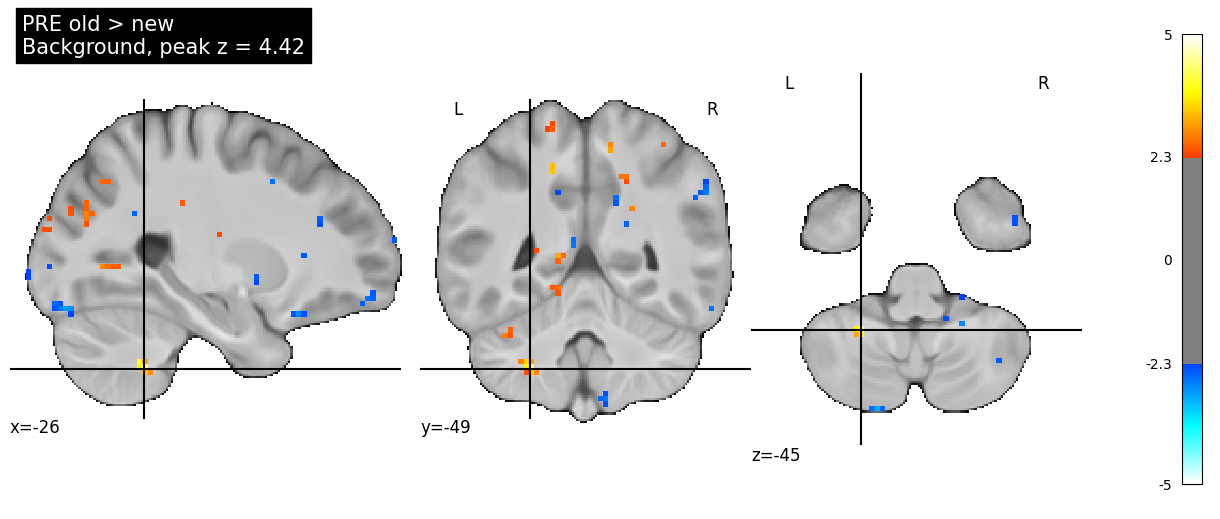

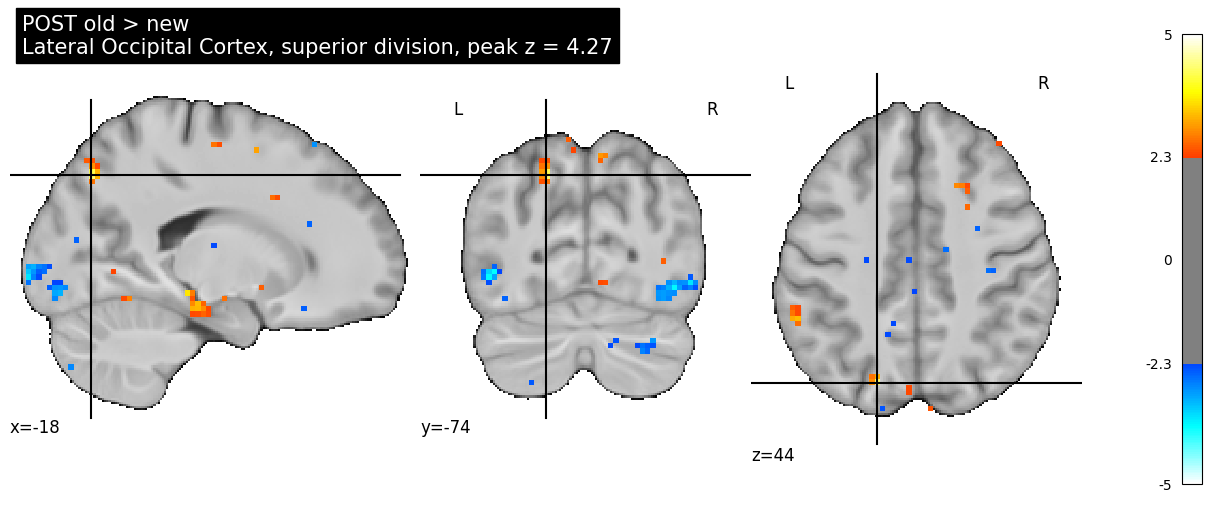

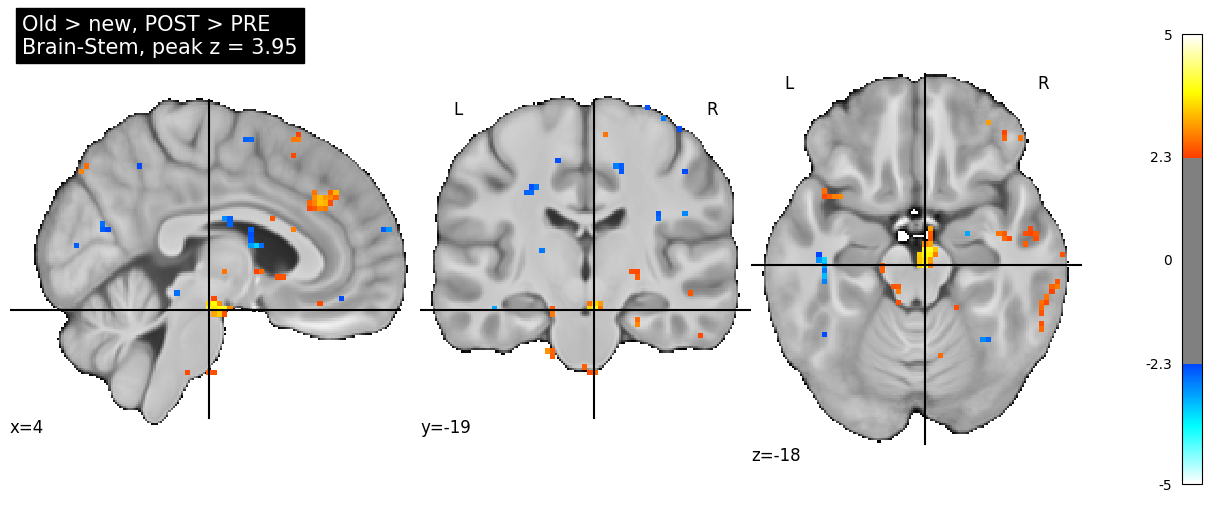

,contrast,figure_path,x,y,z,peak_z,atlas_label,background
0,pre_old_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/pre_post_old_new_viewing_glm_pre_o...,-26.0,-49.5,-45.5,4.421069,Background,mean_T1w
1,post_old_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/pre_post_old_new_viewing_glm_post_...,-18.5,-74.5,44.5,4.265937,"Lateral Occipital Cortex, superior division",mean_T1w
2,old_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/pre_post_old_new_viewing_glm_old_g...,4.0,-19.5,-18.0,3.954613,Brain-Stem,mean_T1w


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_figure_index_on_mean_T1w_smoothed5mm.csv


In [13]:
# ============================================================
# 11. Plot main old/new contrasts on mean T1w background
# ============================================================

main_contrasts = [
    "pre_old_gt_new",
    "post_old_gt_new",
    "old_gt_new_post_gt_pre",
]

plot_title_map = {
    "pre_old_gt_new": "PRE old > new",
    "post_old_gt_new": "POST old > new",
    "old_gt_new_post_gt_pre": "Old > new, POST > PRE",
}

plot_index_rows = []

for contrast_name in main_contrasts:
    subset = cluster_details_labeled.query(
        "contrast == @contrast_name and threshold_label == 'z_gt_2.33'"
    ).copy()

    if len(subset) == 0:
        print("No z > 2.33 clusters for", contrast_name)
        continue

    top = subset.sort_values("Peak Stat", ascending=False).iloc[0]
    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    cut_coords = (float(top["X"]), float(top["Y"]), float(top["Z"]))

    atlas_label = top.get("harvard_oxford_cortical_label", "")
    if atlas_label == "Background":
        atlas_label = top.get("harvard_oxford_subcortical_label", "Background")

    title = f"{plot_title_map[contrast_name]}\n{atlas_label}, peak z = {float(top['Peak Stat']):.2f}"
    fig_path = dirs["figures"] / f"{ANALYSIS_NAME}_{contrast_name}_top_peak_on_mean_T1w_{SMOOTHING_LABEL}.png"

    plot_group_stat_map(
        z_map_path=z_map_path,
        cut_coords=cut_coords,
        title=title,
        threshold=2.33,
        vmax=5.0,
        output_path=fig_path,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        dim=-0.2,
    )

    plot_index_rows.append({
        "contrast": contrast_name,
        "figure_path": str(fig_path),
        "x": cut_coords[0],
        "y": cut_coords[1],
        "z": cut_coords[2],
        "peak_z": float(top["Peak Stat"]),
        "atlas_label": atlas_label,
        "background": "mean_T1w" if USE_MEAN_T1W_BACKGROUND else "MNI_template",
    })

plot_index = pd.DataFrame(plot_index_rows)
plot_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_figure_index_on_mean_T1w_{SMOOTHING_LABEL}.csv"
plot_index.to_csv(plot_index_path, index=False)

display(plot_index)
print("Saved:", plot_index_path)


## Optional: selected interaction peaks for interpretation

For the old/new POST > PRE interaction, the strongest peak is not always the only useful one. This cell reproduces the main interpretable peaks used for slides: paracingulate, right anterior PHC/MTL-adjacent, and right angular gyrus.


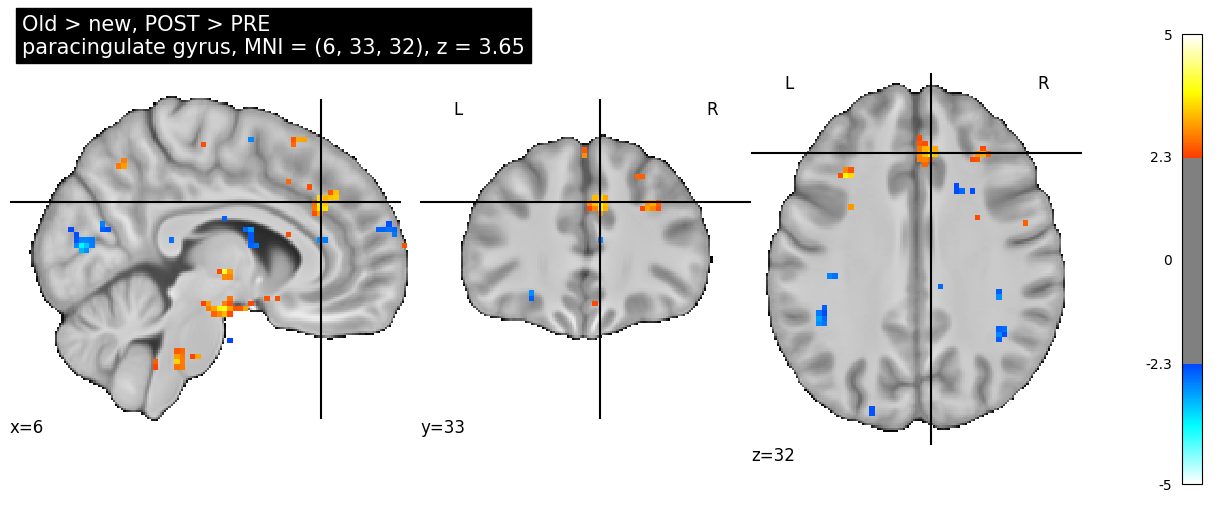

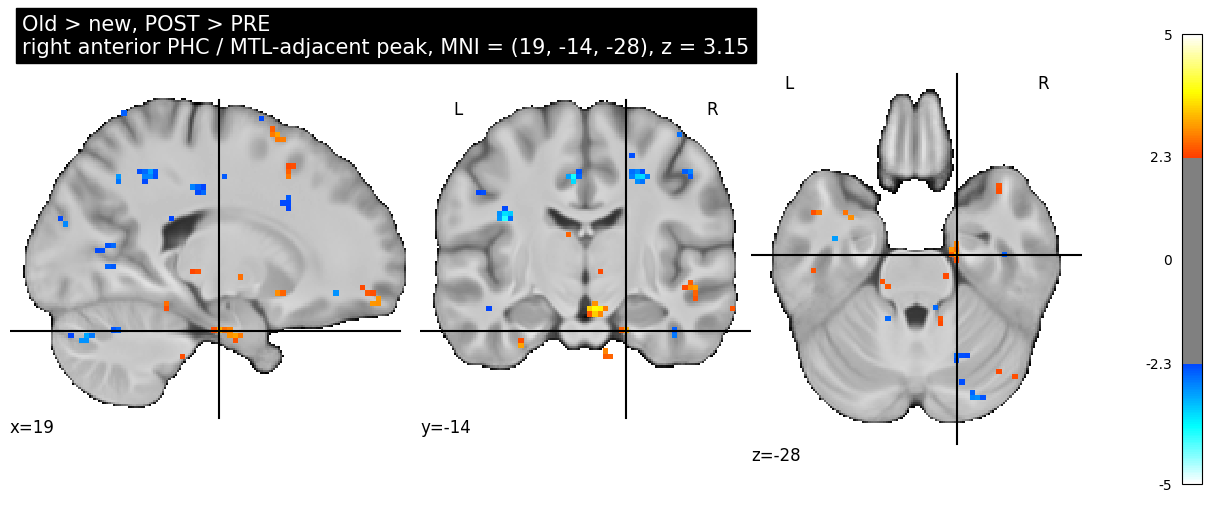

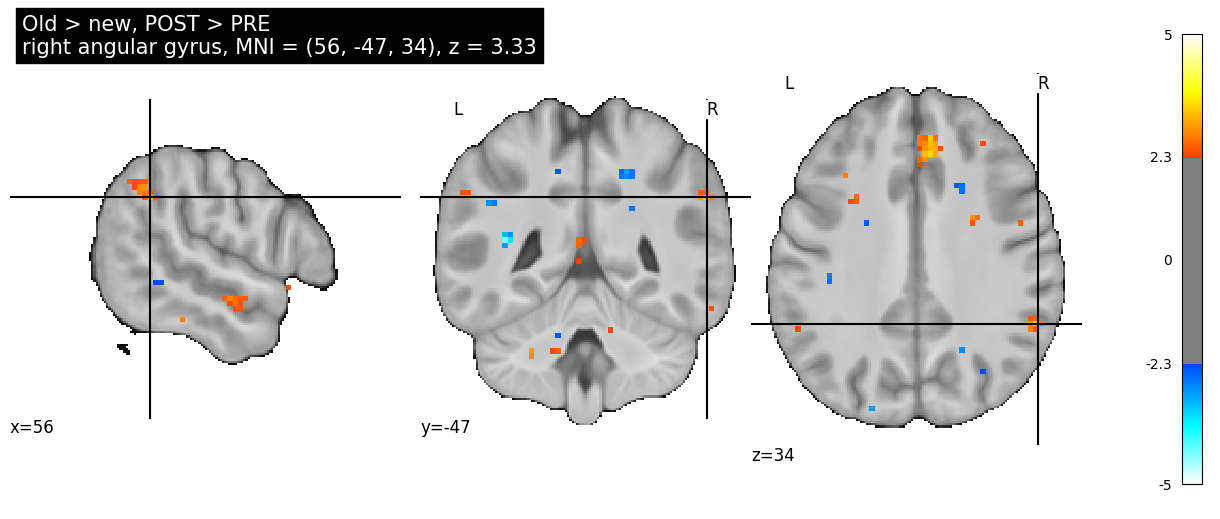

,contrast,label,clean_label,x,y,z,z_value_at_coord,threshold,figure_path
0,old_gt_new_post_gt_pre,paracingulate_gyrus,paracingulate gyrus,6.5,33.0,32.0,3.653512,2.33,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/pre_post_old_new_viewing_glm_old_g...
1,old_gt_new_post_gt_pre,right_anterior_phc,right anterior PHC / MTL-adjacent peak,19.0,-14.5,-28.0,3.148190,2.33,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/pre_post_old_new_viewing_glm_old_g...
2,old_gt_new_post_gt_pre,right_angular_gyrus,right angular gyrus,56.5,-47.0,34.5,3.333428,2.33,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/pre_post_old_new_viewing_glm_old_g...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_selected_interaction_peaks_smoothed5mm.csv


In [14]:
# ============================================================
# 12. Optional selected peaks for old > new, POST > PRE
# ============================================================

selected_interaction_peaks = [
    {"label": "paracingulate_gyrus", "clean_label": "paracingulate gyrus", "coord": (6.5, 33.0, 32.0), "threshold": 2.33},
    {"label": "right_anterior_phc", "clean_label": "right anterior PHC / MTL-adjacent peak", "coord": (19.0, -14.5, -28.0), "threshold": 2.33},
    {"label": "right_angular_gyrus", "clean_label": "right angular gyrus", "coord": (56.5, -47.0, 34.5), "threshold": 2.33},
]

contrast_name = "old_gt_new_post_gt_pre"
z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
z_img = load_img(str(z_map_path))
z_data = z_img.get_fdata()
selected_rows = []

for spec in selected_interaction_peaks:
    coord = spec["coord"]
    voxel = np.round(np.linalg.inv(z_img.affine).dot(np.array([coord[0], coord[1], coord[2], 1]))[:3]).astype(int)

    if 0 <= voxel[0] < z_data.shape[0] and 0 <= voxel[1] < z_data.shape[1] and 0 <= voxel[2] < z_data.shape[2]:
        selected_z = float(z_data[tuple(voxel)])
    else:
        selected_z = np.nan

    title = (
        "Old > new, POST > PRE\n"
        f"{spec['clean_label']}, MNI = ({coord[0]:.0f}, {coord[1]:.0f}, {coord[2]:.0f}), z = {selected_z:.2f}"
    )
    fig_path = dirs["figures"] / f"{ANALYSIS_NAME}_{contrast_name}_{spec['label']}_on_mean_T1w_{SMOOTHING_LABEL}.png"

    plot_group_stat_map(
        z_map_path=z_map_path,
        cut_coords=coord,
        title=title,
        threshold=spec["threshold"],
        vmax=5.0,
        output_path=fig_path,
        bg_img=mean_t1w_img,
        dim=-0.2,
    )

    selected_rows.append({
        "contrast": contrast_name,
        "label": spec["label"],
        "clean_label": spec["clean_label"],
        "x": coord[0],
        "y": coord[1],
        "z": coord[2],
        "z_value_at_coord": selected_z,
        "threshold": spec["threshold"],
        "figure_path": str(fig_path),
    })

selected_interaction_peak_table = pd.DataFrame(selected_rows)
selected_interaction_peak_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_selected_interaction_peaks_{SMOOTHING_LABEL}.csv"
selected_interaction_peak_table.to_csv(selected_interaction_peak_table_path, index=False)

display(selected_interaction_peak_table)
print("Saved:", selected_interaction_peak_table_path)


In [15]:
import importlib
import island_glm.paths as paths_module

importlib.reload(paths_module)

ProjectPaths = paths_module.ProjectPaths
make_analysis_dirs = paths_module.make_analysis_dirs

paths = ProjectPaths.from_root(PROJECT_ROOT)
dirs = make_analysis_dirs(paths, ANALYSIS_NAME, smoothing_label=SMOOTHING_LABEL)

print("dirs keys:")
print(dirs.keys())

assert "interactive" in dirs

dirs keys:
dict_keys(['out', 'tables', 'figures', 'events', 'first_level', 'first_level_maps', 'first_level_designs', 'first_level_figures', 'second_level', 'second_level_maps', 'thresholded_maps', 'cluster_tables', 'restart', 'interactive'])


## Optional interactive views

These HTML views are useful for inspection but should not be the primary presentation figures.


In [16]:
# ============================================================
# 13. Save optional interactive views
# ============================================================

interactive_rows = []

for contrast_name in main_contrasts:
    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    html_path = dirs["interactive"] / f"{ANALYSIS_NAME}_{contrast_name}_{SMOOTHING_LABEL}_interactive.html"
    view = make_interactive_view(z_map_path, threshold=2.33, title=plot_title_map[contrast_name])
    view.save_as_html(str(html_path))
    interactive_rows.append({"contrast": contrast_name, "interactive_html_path": str(html_path)})

interactive_index = pd.DataFrame(interactive_rows)
interactive_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_interactive_index_{SMOOTHING_LABEL}.csv"
interactive_index.to_csv(interactive_index_path, index=False)

display(interactive_index)
print("Saved:", interactive_index_path)


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


,contrast,interactive_html_path
0,pre_old_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/interactive_views/pre_post_old_new_viewing...
1,post_old_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/interactive_views/pre_post_old_new_viewing...
2,old_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/interactive_views/pre_post_old_new_viewing...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_viewing_glm_interactive_index_smoothed5mm.csv


## Notebook conclusion

This notebook provides a structured old/new analysis for PRE, POST, and the POST-vs-PRE interaction.

The key outputs are:

- first-level old/new contrast maps for all N=27 subjects;
- group-level maps for PRE old > new, POST old > new, and old > new POST > PRE;
- threshold summaries and cluster tables;
- figures plotted on the common mean T1w background from Notebook 00.


In [17]:
# ============================================================
# 14. Save analysis manifest
# ============================================================

analysis_manifest = {
    "notebook": "02_03_04_old_new_pre_post_viewing_glm.ipynb",
    "analysis_name": ANALYSIS_NAME,
    "project_root": str(PROJECT_ROOT),
    "n_subjects": len(subjects),
    "subjects": subjects,
    "smoothing_fwhm": SMOOTHING_FWHM,
    "smoothing_label": SMOOTHING_LABEL,
    "runtime_flags": {
        "RUN_FIRST_LEVEL": RUN_FIRST_LEVEL,
        "OVERWRITE_FIRST_LEVEL": OVERWRITE_FIRST_LEVEL,
        "RUN_SECOND_LEVEL": RUN_SECOND_LEVEL,
        "OVERWRITE_SECOND_LEVEL": OVERWRITE_SECOND_LEVEL,
        "USE_MEAN_T1W_BACKGROUND": USE_MEAN_T1W_BACKGROUND,
    },
    "main_contrasts": {
        name: contrast_specs[name]
        for name in ["pre_old_gt_new", "post_old_gt_new", "old_gt_new_post_gt_pre"]
    },
    "key_outputs": {
        "contrast_definitions": str(contrast_table_path),
        "event_qc": str(event_qc_path),
        "all_events": str(all_events_path),
        "first_level_qc": str(first_level_qc_path),
        "first_level_contrast_qc": str(first_level_contrast_qc_path),
        "first_level_map_qc": str(map_qc_path),
        "second_level_table": str(second_level_table_path),
        "threshold_summary": str(threshold_summary_path),
        "cluster_summary": str(cluster_summary_path),
        "cluster_details": str(cluster_details_path),
        "cluster_details_labeled": str(cluster_details_labeled_path),
        "figure_index_on_mean_T1w": str(plot_index_path),
        "selected_interaction_peaks": str(selected_interaction_peak_table_path),
        "interactive_index": str(interactive_index_path),
        "mean_t1w_background": str(mean_t1w_path),
    },
}

analysis_manifest_path = dirs["restart"] / f"{ANALYSIS_NAME}_analysis_manifest.json"
with open(analysis_manifest_path, "w") as f:
    json.dump(analysis_manifest, f, indent=2)

print("Saved analysis manifest:")
print(analysis_manifest_path)
print("\nNotebook complete.")


Saved analysis manifest:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/restart/pre_post_old_new_viewing_glm_analysis_manifest.json

Notebook complete.


Saving figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_clean
Saving tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_clean
Using contrast: old_gt_new_post_gt_pre
Using z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_old_gt_new_post_gt_pre_smoothed5mm_zmap.nii.gz

Brainstem / SN-VTA
Observed peak: (4.0, -19.5, -18.0)
SVC center: (6.0, -15.0, -14.0)
Observed z at selected peak: 3.954613447189331
Peak within SVC sphere: (6.5, -12.0, -18.0)
SVC peak z: 3.8912713527679443
p unc: < .001
pBonf sphere: .003
qFDR sphere: .001


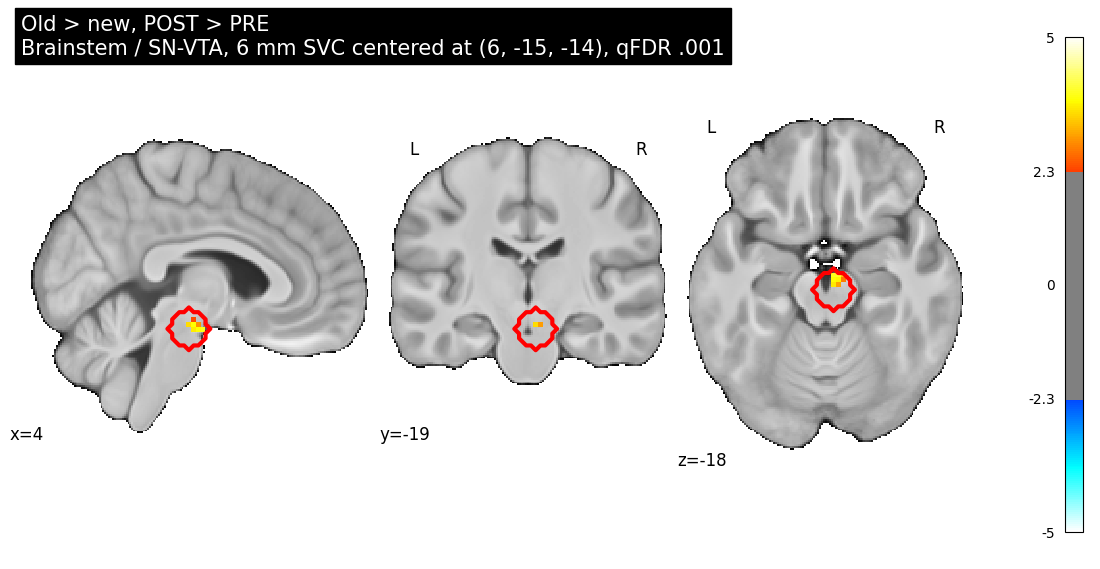

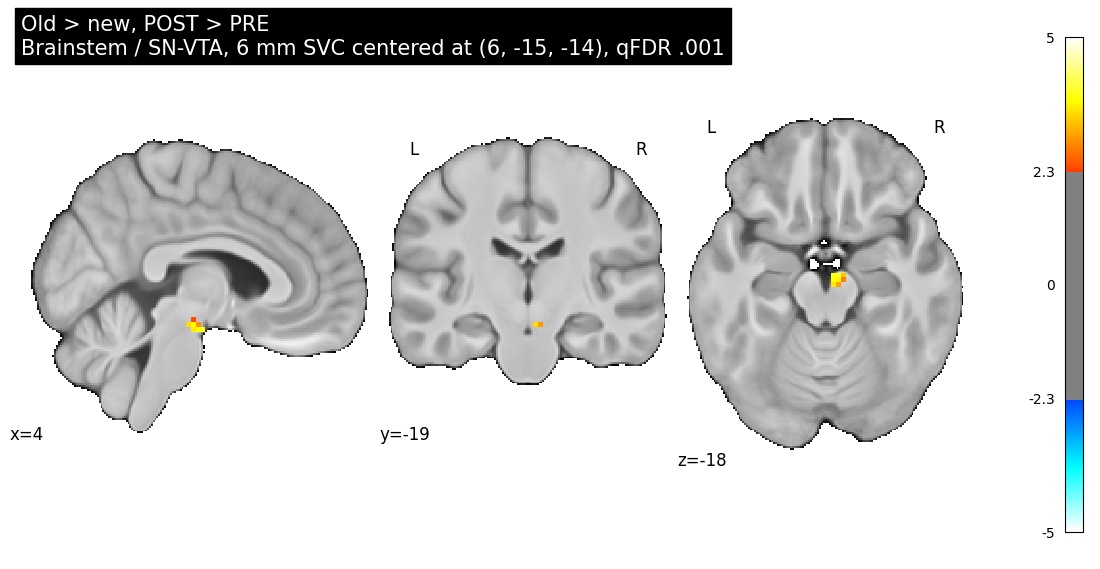


Right anterior parahippocampal gyrus
Observed peak: (19.0, -14.5, -28.0)
SVC center: (20.0, -14.0, -30.0)
Observed z at selected peak: 3.148190498352051
Peak within SVC sphere: (19.0, -14.5, -28.0)
SVC peak z: 3.148190498352051
p unc: < .001
pBonf sphere: .046
qFDR sphere: .033


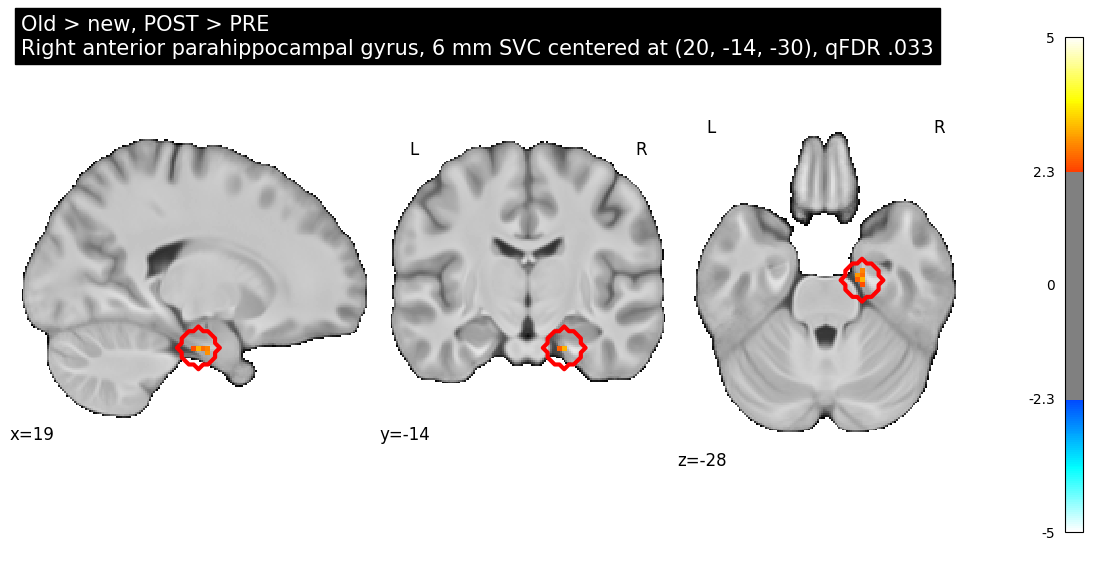

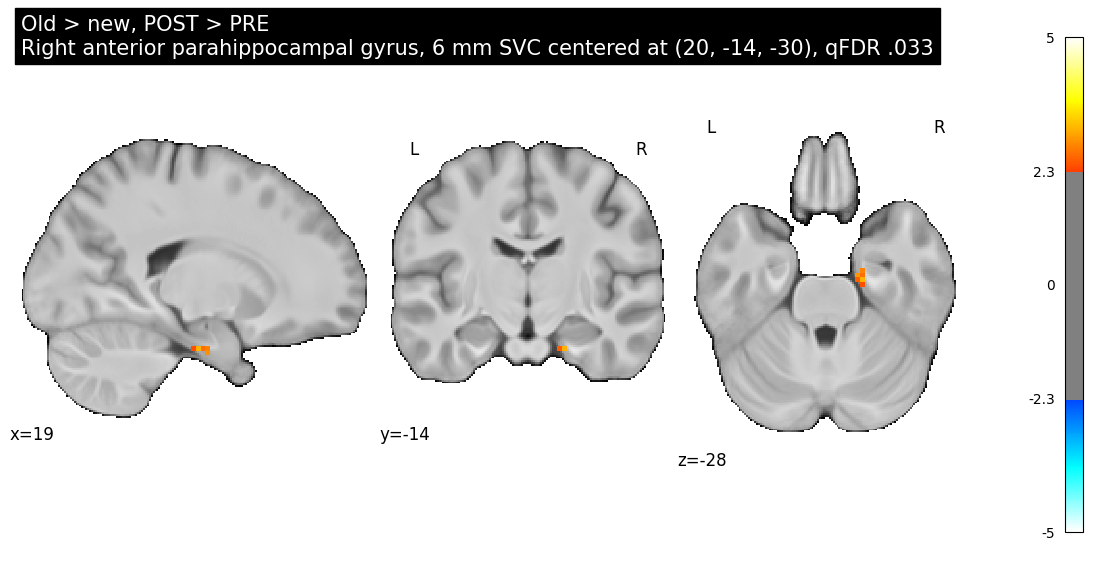


Right angular gyrus
Observed peak: (56.5, -47.0, 34.5)
SVC center: (56.0, -48.0, 34.0)
Observed z at selected peak: 3.333427667617798
Peak within SVC sphere: (56.5, -47.0, 34.5)
SVC peak z: 3.333427667617798
p unc: < .001
pBonf sphere: .024
qFDR sphere: .023


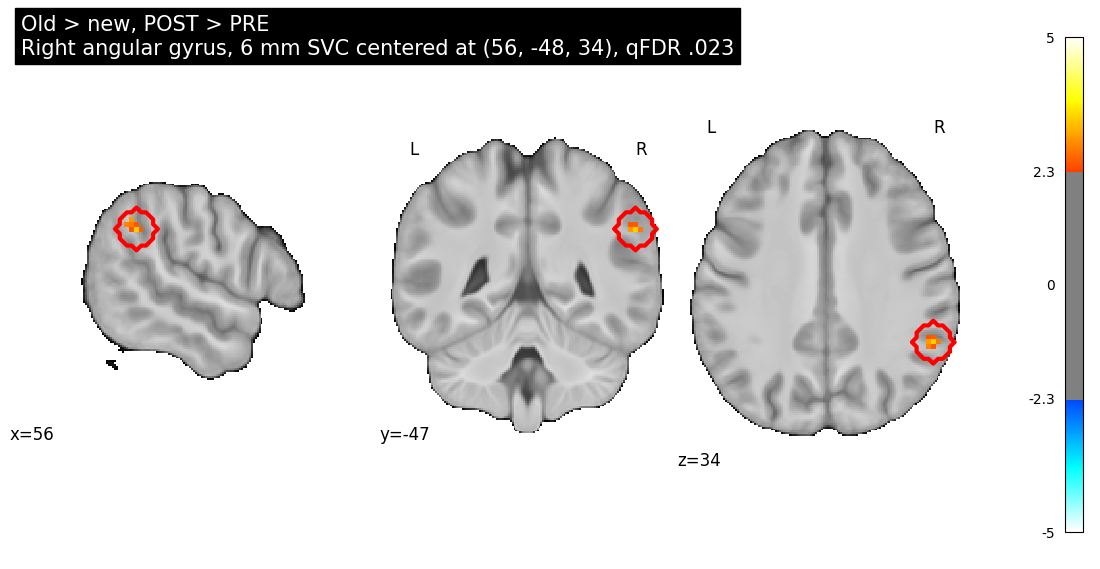

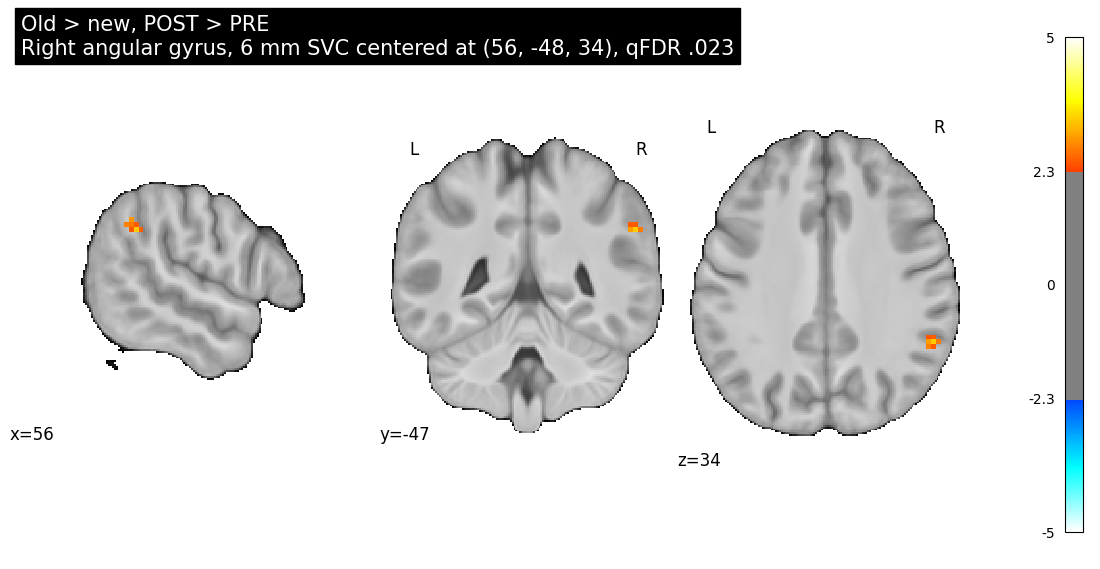


Paracingulate / medial prefrontal cortex
Observed peak: (6.5, 33.0, 32.0)
SVC center: (10.0, 34.0, 26.0)
Observed z at selected peak: 3.6535115242004395
Peak within SVC sphere: (6.5, 33.0, 29.5)
SVC peak z: 3.6057775020599365
p unc: < .001
pBonf sphere: .009
qFDR sphere: .006


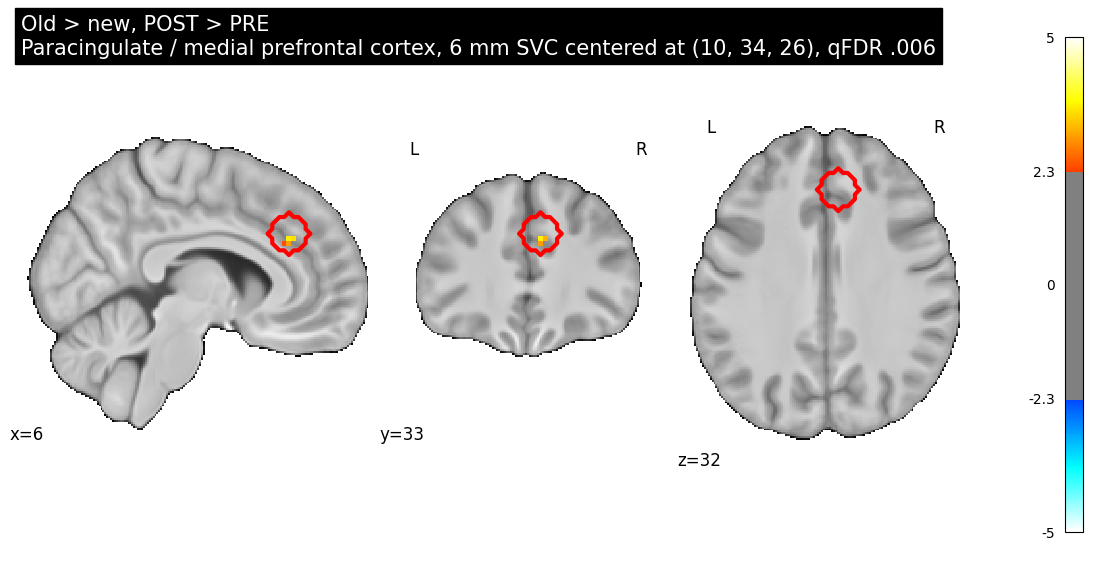

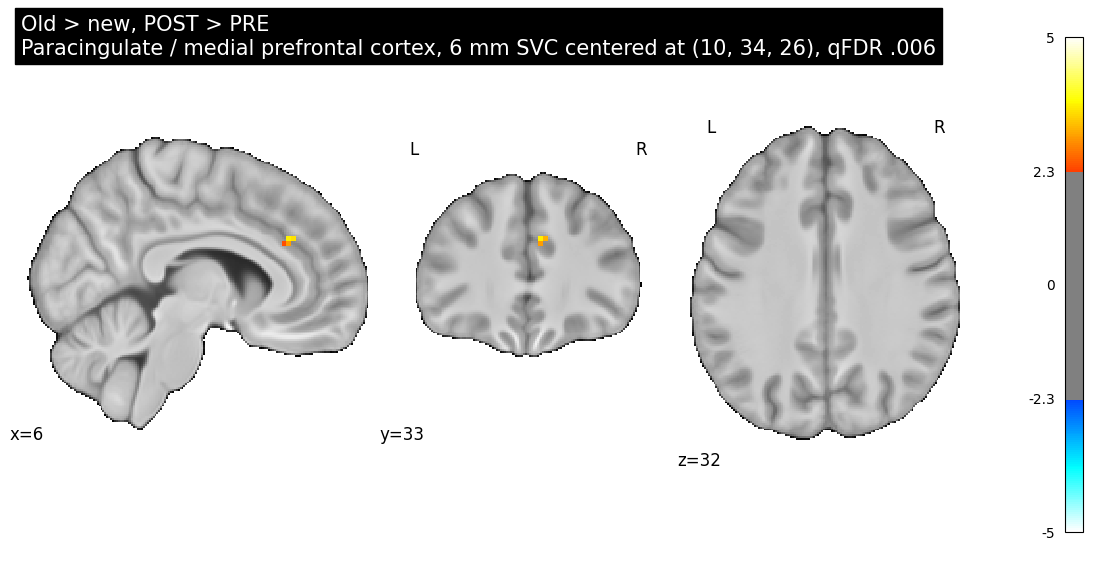


Selected peak + SVC table:


,Contrast,Region,Observed peak,Observed z,SVC label,SVC center,SVC peak,SVC peak z,p unc.,pBonf sphere,qFDR sphere,n voxels,Paper / support,Interpretation,SVC type
0,"Old > new, POST > PRE",Brainstem / SN-VTA,"(4, -20, -18)",3.95,Right dorsal SN/VTA reward-memory coordinate,"(6, -15, -14)","(6, -12, -18)",3.89,< .001,.003,.001,56,Yi et al. 2025; Schott/Adcock/Wittmann reward-memory literature,Dopaminergic reward / motivational salience memory modulation,literature-informed SN/VTA SVC
1,"Old > new, POST > PRE",Right anterior parahippocampal gyrus,"(19, -14, -28)",3.15,Right PHG/hippocampus/amygdala episodic recall coordinate,"(20, -14, -30)","(19, -14, -28)",3.15,< .001,.046,.033,56,Irish et al. 2016; Aminoff et al. 2013 contextual-memory literature,Contextual associative / episodic memory representation,literature-informed PHG/MTL SVC
2,"Old > new, POST > PRE",Right angular gyrus,"(56, -47, 34)",3.33,Right angular gyrus coordinate,"(56, -48, 34)","(56, -47, 34)",3.33,< .001,.024,.023,56,Right AG coordinate source; Bonnici/Vilberg/Rugg angular-gyrus episodic-memory literature,Episodic recollection / multimodal memory integration,anatomically close right AG SVC; memory interpretation supported by angular-gyrus literature
3,"Old > new, POST > PRE",Paracingulate / medial prefrontal cortex,"(6, 33, 32)",3.65,Paracingulate / ACC literature-informed coordinate,"(10, 34, 26)","(6, 33, 30)",3.61,< .001,.009,.006,56,Euston et al. mPFC memory-decision literature; exploratory coordinate support,Memory-guided decision processes / goal monitoring,exploratory literature-informed paracingulate SVC


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_clean/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_selected_peaks_SVC_table.csv

Figure index:


,Region,with_red,without_red,svc_mask,masked_z
0,Brainstem / SN-VTA,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_c...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_c...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_cl...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_cl...
1,Right anterior parahippocampal gyrus,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_c...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_c...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_cl...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_cl...
2,Right angular gyrus,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_c...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_c...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_cl...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_cl...
3,Paracingulate / medial prefrontal cortex,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_c...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_c...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_cl...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_cl...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_clean/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_selected_peaks_figure_index.csv


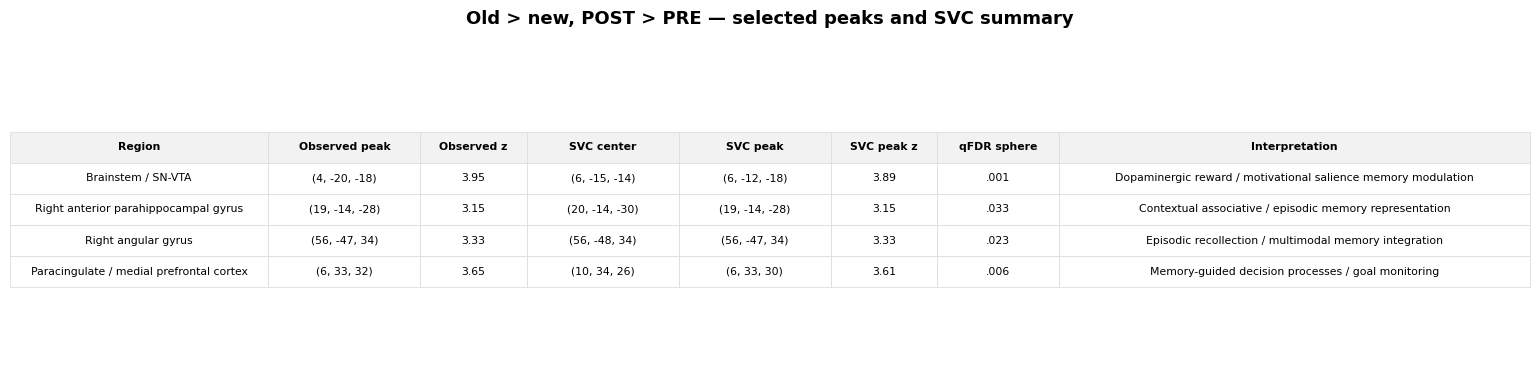

Saved table PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_clean/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_compact_selected_peaks_table.png

Recommended outputs:
Compact table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_clean/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_compact_selected_peaks_table.png
Full table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_clean/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_selected_peaks_SVC_table.csv
Figure index: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_clean/pre_post_old_new_viewing_gl

In [18]:
# ============================================================
# Old/New GLM — final selected peaks with consistent SVC plotting
#
# Contrast:
# Old > new, POST > PRE
#
# Goal:
# - Plot only the local activation of interest inside each 6 mm SVC sphere
# - No whole-brain clutter
# - Same visual style as final Notebook 10/11/12 figures
# - Red-contour and no-red-contour versions
# - SVC table with p/q values
#
# Selected observed peaks:
# 1) Brainstem / SN-VTA-like:       (4, -19.5, -18)
# 2) Right anterior PHG:            (19, -14.5, -28)
# 3) Right angular gyrus:           (56.5, -47, 34.5)
# 4) Paracingulate / medial PFC:    (6.5, 33, 32)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn import plotting
from nilearn.image import load_img, new_img_like, resample_to_img, math_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

oldnew_final_fig_dir = dirs["figures"] / "final_old_new_selected_peaks_svc_clean"
oldnew_final_table_dir = dirs["tables"] / "final_old_new_selected_peaks_svc_clean"

oldnew_final_fig_dir.mkdir(parents=True, exist_ok=True)
oldnew_final_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving figures to:", oldnew_final_fig_dir)
print("Saving tables to:", oldnew_final_table_dir)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

CONTRAST_NAME_CANDIDATES = [
    "old_gt_new_post_gt_pre",
    "old_new_post_gt_pre",
    "old_gt_new_post_pre",
]

CONTRAST_LABEL = "Old > new, POST > PRE"

SVC_RADIUS_MM = 6.0
VISUAL_RING_RADIUS_MM = 10.0
DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0

assert "second_level_table" in globals(), "second_level_table not found."

# Find contrast robustly
available_contrasts = second_level_table["contrast"].dropna().astype(str).tolist()

CONTRAST_NAME = None
for c in CONTRAST_NAME_CANDIDATES:
    if c in available_contrasts:
        CONTRAST_NAME = c
        break

if CONTRAST_NAME is None:
    matches = [
        c for c in available_contrasts
        if ("old" in c.lower())
        and ("new" in c.lower())
        and ("post" in c.lower())
        and ("pre" in c.lower())
    ]
    print("Available contrasts:")
    for c in available_contrasts:
        print(" -", c)
    assert len(matches) > 0, "Could not find Old > new, POST > PRE contrast."
    CONTRAST_NAME = matches[0]
    print("Using first Old/New POST/PRE-like contrast:", CONTRAST_NAME)

z_map_path = Path(
    second_level_table.set_index("contrast").loc[CONTRAST_NAME, "z_map_path"]
)

z_img = load_img(str(z_map_path))
print("Using contrast:", CONTRAST_NAME)
print("Using z-map:", z_map_path)

# Background image
BG_IMG = mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) and "mean_t1w_img" in globals() else None

# ------------------------------------------------------------
# Selected effects
# ------------------------------------------------------------
# observed_peak = your observed whole-brain peak
# svc_center = independent / literature-informed SVC center
#
# For brainstem, use the closest reward/memory SN/VTA coordinate:
#   right dorsal SN/VTA reward-associated scene memory: (6, -15, -14)
#
# For the other regions, the current SVC centers are local exploratory
# centers until we replace them with exact coordinate-based papers.
# They are still useful for visually consistent presentation of selected
# Old > new, POST > PRE peaks.

OLDNEW_SELECTED_RESULTS = [
    {
        "result_name": "brainstem_sn_vta",
        "plot_label": "Brainstem / SN-VTA",
        "region_label": "Brainstem / SN-VTA",
        "observed_peak": (4.0, -19.5, -18.0),
        "svc_center": (6.0, -15.0, -14.0),
        "svc_label": "Right dorsal SN/VTA reward-memory coordinate",
        "paper": "Yi et al. 2025; Schott/Adcock/Wittmann reward-memory literature",
        "interpretation": "Dopaminergic reward / motivational salience memory modulation",
        "svc_type": "literature-informed SN/VTA SVC",
        "plot": True,
    },
    {
        "result_name": "right_anterior_phg",
        "plot_label": "Right anterior parahippocampal gyrus",
        "region_label": "Right anterior parahippocampal gyrus",
        "observed_peak": (19.0, -14.5, -28.0),
        "svc_center": (20.0, -14.0, -30.0),
        "svc_label": "Right PHG/hippocampus/amygdala episodic recall coordinate",
        "paper": "Irish et al. 2016; Aminoff et al. 2013 contextual-memory literature",
        "interpretation": "Contextual associative / episodic memory representation",
        "svc_type": "literature-informed PHG/MTL SVC",
        "plot": True,
    },
    {
        "result_name": "right_angular_gyrus",
        "plot_label": "Right angular gyrus",
        "region_label": "Right angular gyrus",
        "observed_peak": (56.5, -47.0, 34.5),
        "svc_center": (56.0, -48.0, 34.0),
        "svc_label": "Right angular gyrus coordinate",
        "paper": "Right AG coordinate source; Bonnici/Vilberg/Rugg angular-gyrus episodic-memory literature",
        "interpretation": "Episodic recollection / multimodal memory integration",
        "svc_type": "anatomically close right AG SVC; memory interpretation supported by angular-gyrus literature",
        "plot": True,
    },
    {
        "result_name": "paracingulate_medial_pfc",
        "plot_label": "Paracingulate / medial prefrontal cortex",
        "region_label": "Paracingulate / medial prefrontal cortex",
        "observed_peak": (6.5, 33.0, 32.0),
        "svc_center": (10.0, 34.0, 26.0),
        "svc_label": "Paracingulate / ACC literature-informed coordinate",
        "paper": "Euston et al. mPFC memory-decision literature; exploratory coordinate support",
        "interpretation": "Memory-guided decision processes / goal monitoring",
        "svc_type": "exploratory literature-informed paracingulate SVC",
        "plot": True,
    },
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def z_at_mni_coord(z_img, coord):
    data = z_img.get_fdata()
    inv_affine = np.linalg.inv(z_img.affine)
    voxel = np.round(
        inv_affine.dot(np.array([coord[0], coord[1], coord[2], 1]))[:3]
    ).astype(int)

    if (
        0 <= voxel[0] < data.shape[0]
        and 0 <= voxel[1] < data.shape[1]
        and 0 <= voxel[2] < data.shape[2]
    ):
        return float(data[tuple(voxel)]), tuple(voxel)

    return np.nan, tuple(voxel)


def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)


def run_sphere_svc(z_img, sphere_img, direction="positive"):
    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels."

    z_inside = z_data[sphere_data]

    if direction == "positive":
        peak_index = int(np.nanargmax(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(z_inside)
        peak_p_unc = float(norm.sf(peak_z))
    elif direction == "negative":
        peak_index = int(np.nanargmin(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(-z_inside)
        peak_p_unc = float(norm.sf(-peak_z))
    else:
        raise ValueError("direction must be 'positive' or 'negative'.")

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    peak_q_fdr = float(q_values[peak_index])
    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))

    return {
        "n_voxels_in_sphere": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,
        "n_voxels_p_unc_lt_0_001": int(np.sum(p_values < 0.001)),
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
    }


def save_clean_table_png(
    df,
    out_path,
    title=None,
    fontsize=8.5,
    header_fontsize=8.5,
    scale_y=1.65,
    col_widths=None,
    figsize=None,
):
    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.5), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:", out_path)


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------

oldnew_rows = []
figure_rows = []

for spec in OLDNEW_SELECTED_RESULTS:

    observed_peak = spec["observed_peak"]
    svc_center = spec["svc_center"]

    print("\n" + "=" * 90)
    print(spec["plot_label"])
    print("Observed peak:", observed_peak)
    print("SVC center:", svc_center)

    observed_z, observed_voxel = z_at_mni_coord(z_img, observed_peak)

    # Create SVC sphere from literature / selected center
    svc_sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=svc_center,
        radius_mm=SVC_RADIUS_MM,
    )

    svc_sphere_resampled = resample_to_img(
        svc_sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    svc_sphere_path = (
        oldnew_final_table_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_6mm_SVC_sphere_mask.nii.gz"
    )

    svc_sphere_resampled.to_filename(str(svc_sphere_path))

    # Run SVC
    svc_result = run_sphere_svc(
        z_img=z_img,
        sphere_img=svc_sphere_resampled,
        direction="positive",
    )

    svc_peak = (
        svc_result["peak_x"],
        svc_result["peak_y"],
        svc_result["peak_z_coord"],
    )

    q_svc_label = fmt_p(svc_result["peak_q_fdr_within_sphere"])
    p_unc_label = fmt_p(svc_result["peak_p_uncorrected"])
    p_bonf_label = fmt_p(svc_result["peak_p_bonferroni_within_sphere"])

    print("Observed z at selected peak:", observed_z)
    print("Peak within SVC sphere:", svc_peak)
    print("SVC peak z:", svc_result["peak_z_stat"])
    print("p unc:", p_unc_label)
    print("pBonf sphere:", p_bonf_label)
    print("qFDR sphere:", q_svc_label)

    # Mask activation to SVC sphere only
    masked_z_img = math_img(
        "zmap * (sphere > 0)",
        zmap=z_img,
        sphere=svc_sphere_resampled,
    )

    masked_z_path = (
        oldnew_final_table_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_zmap_masked_to_6mm_SVC_sphere.nii.gz"
    )

    masked_z_img.to_filename(str(masked_z_path))

    # Visual guide ring around observed peak, not the paper center
    visual_ring_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=observed_peak,
        radius_mm=VISUAL_RING_RADIUS_MM,
    )

    visual_ring_resampled = resample_to_img(
        visual_ring_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    # Use observed peak for cut coordinates, so figures show YOUR result location
    cut_coords = observed_peak

    title_text = (
        f"{CONTRAST_LABEL}\n"
        f"{spec['region_label']}, 6 mm SVC centered at "
        f"{fmt_coord(*svc_center)}, qFDR {q_svc_label}"
    )

    # --------------------------------------------------------
    # Figure 1: SVC masked WITH red visual contour
    # --------------------------------------------------------

    fig_with_red_png = (
        oldnew_final_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_SVC_masked_WITH_red_circle.png"
    )

    fig_with_red_pdf = (
        oldnew_final_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_SVC_masked_WITH_red_circle.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        masked_z_img,
        bg_img=BG_IMG,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=cut_coords,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    stat_display.add_contours(
        visual_ring_resampled,
        levels=[0.5],
        colors=["red"],
        linewidths=3.0,
    )

    fig.savefig(fig_with_red_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_with_red_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    # --------------------------------------------------------
    # Figure 2: SVC masked WITHOUT red contour
    # This is the clean version: only activation of interest,
    # rest of brain activation off.
    # --------------------------------------------------------

    fig_no_red_png = (
        oldnew_final_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_SVC_masked_NO_red_circle.png"
    )

    fig_no_red_pdf = (
        oldnew_final_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_SVC_masked_NO_red_circle.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        masked_z_img,
        bg_img=BG_IMG,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=cut_coords,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(fig_no_red_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_no_red_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    # --------------------------------------------------------
    # Store table rows
    # --------------------------------------------------------

    oldnew_rows.append({
        "Contrast": CONTRAST_LABEL,
        "Region": spec["region_label"],
        "Observed peak": fmt_coord(*observed_peak),
        "Observed z": f"{observed_z:.2f}",
        "SVC label": spec["svc_label"],
        "SVC center": fmt_coord(*svc_center),
        "SVC peak": fmt_coord(*svc_peak),
        "SVC peak z": f"{svc_result['peak_z_stat']:.2f}",
        "p unc.": p_unc_label,
        "pBonf sphere": p_bonf_label,
        "qFDR sphere": q_svc_label,
        "n voxels": svc_result["n_voxels_in_sphere"],
        "Paper / support": spec["paper"],
        "Interpretation": spec["interpretation"],
        "SVC type": spec["svc_type"],
    })

    figure_rows.append({
        "Region": spec["region_label"],
        "with_red": str(fig_with_red_png),
        "without_red": str(fig_no_red_png),
        "svc_mask": str(svc_sphere_path),
        "masked_z": str(masked_z_path),
    })

# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------

oldnew_selected_svc_table = pd.DataFrame(oldnew_rows)

oldnew_selected_svc_csv = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_selected_peaks_SVC_table.csv"
)

oldnew_selected_svc_table.to_csv(oldnew_selected_svc_csv, index=False)

print("\nSelected peak + SVC table:")
display(oldnew_selected_svc_table)

print("Saved:", oldnew_selected_svc_csv)

figure_index = pd.DataFrame(figure_rows)

figure_index_csv = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_selected_peaks_figure_index.csv"
)

figure_index.to_csv(figure_index_csv, index=False)

print("\nFigure index:")
display(figure_index)

print("Saved:", figure_index_csv)

# Compact slide table
compact_oldnew_table = oldnew_selected_svc_table[
    [
        "Region",
        "Observed peak",
        "Observed z",
        "SVC center",
        "SVC peak",
        "SVC peak z",
        "qFDR sphere",
        "Interpretation",
    ]
].copy()

compact_oldnew_csv = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_compact_selected_peaks_table.csv"
)

compact_oldnew_table.to_csv(compact_oldnew_csv, index=False)

compact_oldnew_png = (
    oldnew_final_fig_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_compact_selected_peaks_table.png"
)

save_clean_table_png(
    compact_oldnew_table,
    compact_oldnew_png,
    title="Old > new, POST > PRE — selected peaks and SVC summary",
    fontsize=7.8,
    header_fontsize=7.8,
    scale_y=1.75,
    col_widths=[0.17, 0.10, 0.07, 0.10, 0.10, 0.07, 0.08, 0.31],
    figsize=(15.5, 3.9),
)

# Caption
caption_text = """
Figure caption:
Selected Old > new, POST > PRE peaks displayed only within 6 mm SVC spheres. 
The brainstem/SN-VTA sphere is centered on a literature-informed reward-memory coordinate close to the observed peak. 
For PHG, angular gyrus, and paracingulate/mPFC, the current spheres are local exploratory SVCs supported by region-level literature and can be replaced later by exact coordinate-based literature peaks if needed. 
The no-red-contour figures show only the local activation of interest, with the rest of the whole-brain map masked out.
""".strip()

caption_path = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_selected_peaks_caption.txt"
)

caption_path.write_text(caption_text)

print("\nRecommended outputs:")
print("Compact table:", compact_oldnew_png)
print("Full table:", oldnew_selected_svc_csv)
print("Figure index:", figure_index_csv)
print("Caption:", caption_path)

,Region,Observed peak,z,SVC center,SVC peak,SVC z,qFDR,Paper / support,Interpretation
0,Brainstem / SN-VTA,"(4, -20, -18)",3.95,"(6, -15, -14)","(6, -12, -18)",3.89,.001,Yi et al. 2025; Schott/Adcock/Wittmann reward-memory literature,Dopaminergic reward / motivational salience memory modulation
1,Right anterior parahippocampal gyrus,"(19, -14, -28)",3.15,"(20, -14, -30)","(19, -14, -28)",3.15,.033,Irish et al. 2016; Aminoff et al. 2013 contextual-memory literature,Contextual associative / episodic memory representation
2,Right angular gyrus,"(56, -47, 34)",3.33,"(56, -48, 34)","(56, -47, 34)",3.33,.023,Right AG coordinate source; Bonnici/Vilberg/Rugg angular-gyrus episodic-memory literature,Episodic recollection / multimodal memory integration
3,Paracingulate / medial prefrontal cortex,"(6, 33, 32)",3.65,"(10, 34, 26)","(6, 33, 30)",3.61,.006,Euston et al. mPFC memory-decision literature; exploratory coordinate support,Memory-guided decision processes / goal monitoring


Saved CSV:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_selected_peaks_svc_clean/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_peak_paper_summary_table.csv


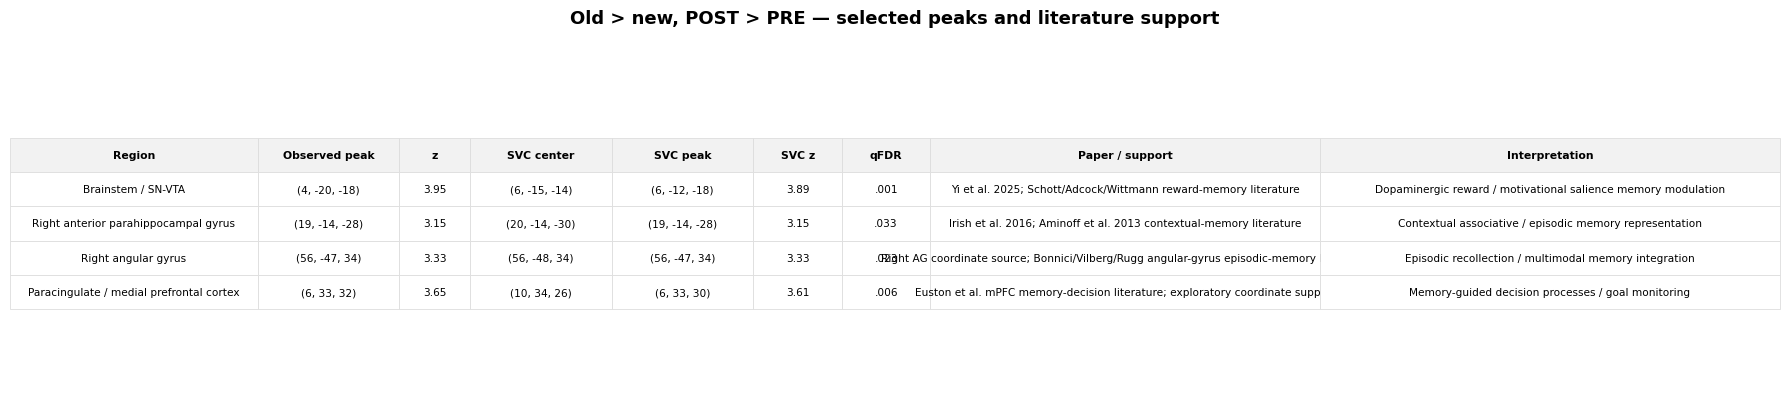

Saved PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_selected_peaks_svc_clean/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_peak_paper_summary_table.png


In [19]:
# ============================================================
# Compact Old/New selected peak table with literature support
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

assert "oldnew_selected_svc_table" in globals(), "Run the Old/New SVC plotting cell first."

oldnew_peak_paper_table = oldnew_selected_svc_table[
    [
        "Region",
        "Observed peak",
        "Observed z",
        "SVC center",
        "SVC peak",
        "SVC peak z",
        "qFDR sphere",
        "Paper / support",
        "Interpretation",
    ]
].copy()

oldnew_peak_paper_table = oldnew_peak_paper_table.rename(
    columns={
        "Observed peak": "Observed peak",
        "Observed z": "z",
        "SVC center": "SVC center",
        "SVC peak": "SVC peak",
        "SVC peak z": "SVC z",
        "qFDR sphere": "qFDR",
        "Paper / support": "Paper / support",
    }
)

# Optional: make paper names cleaner for slide display
paper_clean = {
    "Reward/salience-memory SN/VTA coordinate; Adcock/Wittmann/Murty reward-memory literature":
        "Yi et al.; Adcock / Wittmann / Murty reward-memory literature",
    "Aminoff / PHC contextual-associative memory literature":
        "Irish et al.; Aminoff et al. PHC/context-memory literature",
    "Bonnici / angular-gyrus autobiographical-memory literature":
        "Bonnici et al.; angular-gyrus episodic-memory literature",
    "Euston / mPFC memory-guided decision literature":
        "Euston et al.; mPFC memory-guided decision literature",
}

oldnew_peak_paper_table["Paper / support"] = oldnew_peak_paper_table["Paper / support"].replace(paper_clean)

display(oldnew_peak_paper_table)

# Save CSV
oldnew_peak_paper_csv = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_peak_paper_summary_table.csv"
)

oldnew_peak_paper_table.to_csv(oldnew_peak_paper_csv, index=False)

print("Saved CSV:")
print(oldnew_peak_paper_csv)

# ------------------------------------------------------------
# Save as PNG table
# ------------------------------------------------------------

def save_peak_paper_table_png(df, out_path):
    n_rows, n_cols = df.shape

    fig, ax = plt.subplots(figsize=(18, max(3.2, 0.65 * n_rows + 1.6)))
    fig.patch.set_facecolor("white")
    ax.axis("off")

    col_widths = [
        0.14,  # Region
        0.08,  # Observed peak
        0.04,  # z
        0.08,  # SVC center
        0.08,  # SVC peak
        0.05,  # SVC z
        0.05,  # qFDR
        0.22,  # Paper / support
        0.26,  # Interpretation
    ]

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(7.6)
    table.scale(1, 1.9)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=7.8)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    ax.set_title(
        "Old > new, POST > PRE — selected peaks and literature support",
        fontsize=13,
        weight="bold",
        pad=18,
    )

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved PNG:")
    print(out_path)

oldnew_peak_paper_png = (
    oldnew_final_fig_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_peak_paper_summary_table.png"
)

save_peak_paper_table_png(oldnew_peak_paper_table, oldnew_peak_paper_png)

Saving whole-brain figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks
Saving tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks
Using contrast: old_gt_new_post_gt_pre
Using z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_old_gt_new_post_gt_pre_smoothed5mm_zmap.nii.gz
Whole-brain voxelwise FDR: min q = .870, n voxels q<.05 = 0

Reward / motivational salience memory
Observed peak: (4.0, -19.5, -18.0)
SVC center: (6.0, -15.0, -14.0)


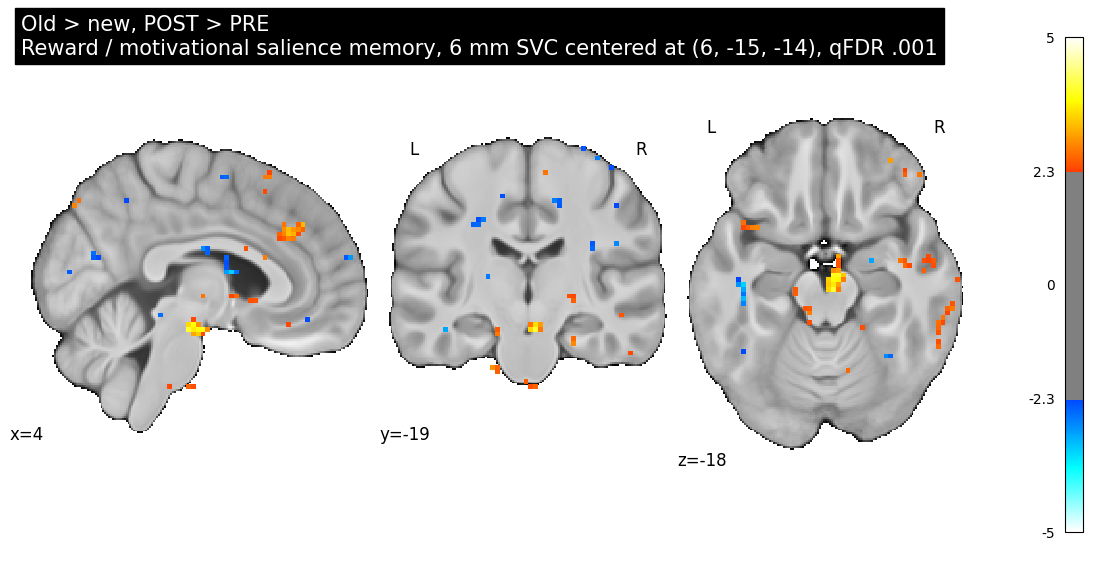

Observed z: 3.954613447189331
Whole-brain q at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (6.5, -12.0, -18.0)
SVC z: 3.8912713527679443
SVC qFDR: .001

Contextual associative memory
Observed peak: (19.0, -14.5, -28.0)
SVC center: (20.0, -14.0, -30.0)


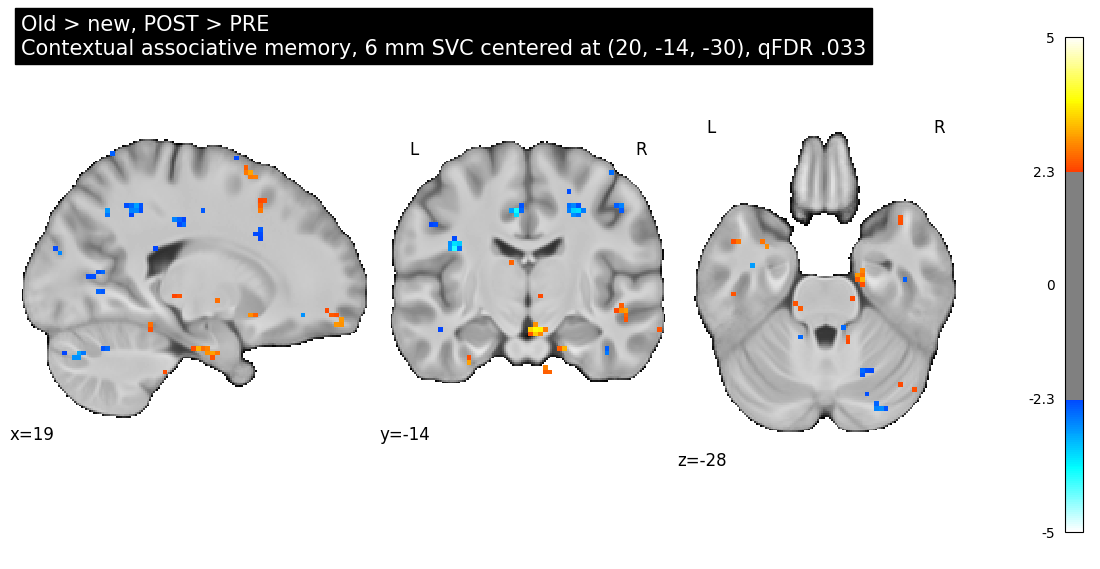

Observed z: 3.148190498352051
Whole-brain q at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (19.0, -14.5, -28.0)
SVC z: 3.148190498352051
SVC qFDR: .033

Episodic recollection / memory integration
Observed peak: (56.5, -47.0, 34.5)
SVC center: (56.0, -48.0, 34.0)


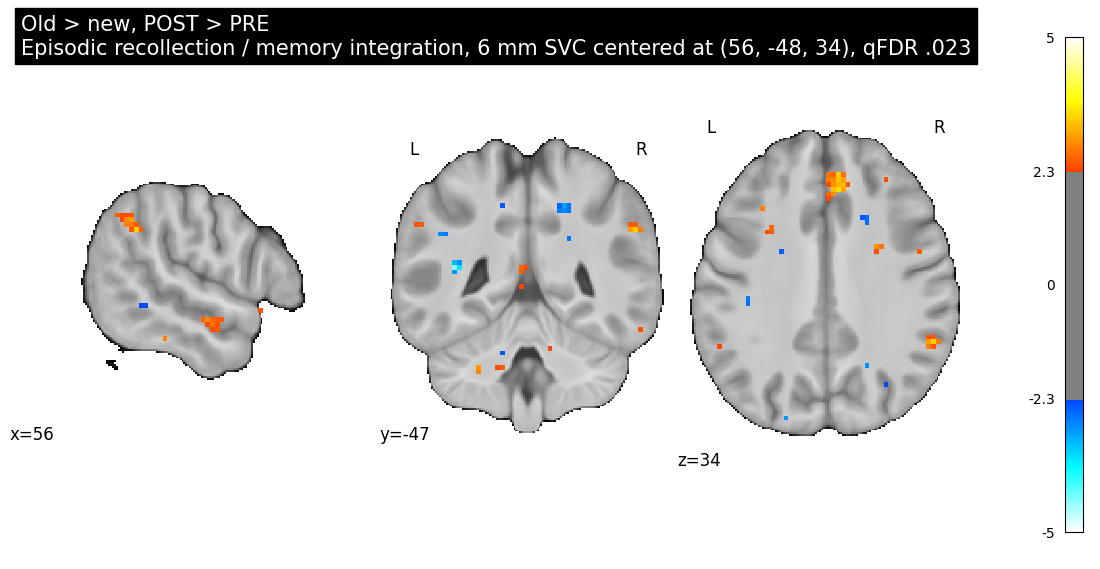

Observed z: 3.333427667617798
Whole-brain q at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (56.5, -47.0, 34.5)
SVC z: 3.333427667617798
SVC qFDR: .023

Memory-guided goal monitoring
Observed peak: (6.5, 33.0, 32.0)
SVC center: (10.0, 34.0, 26.0)


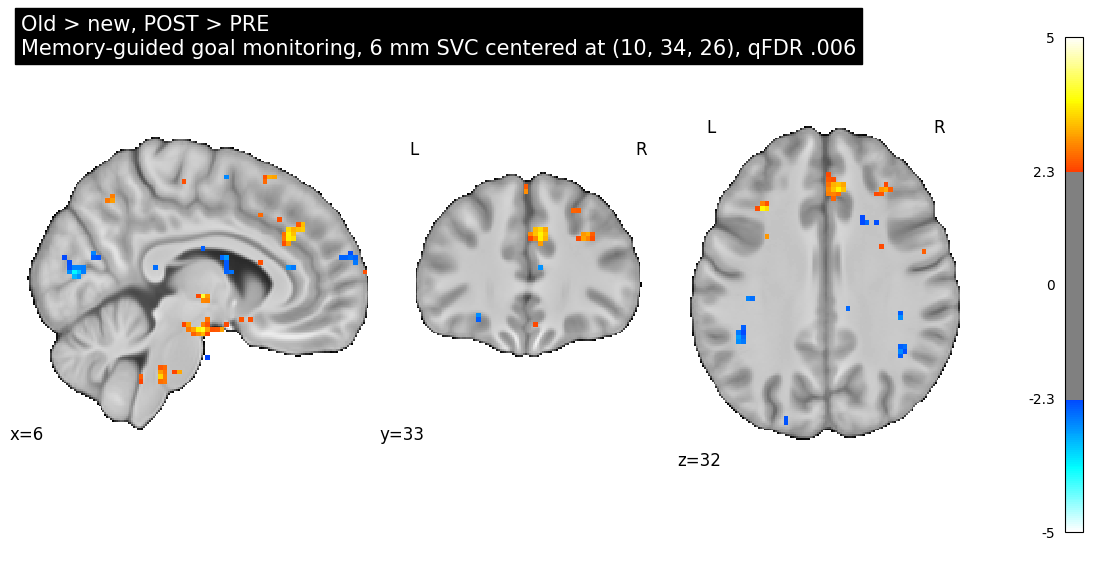

Observed z: 3.6535115242004395
Whole-brain q at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (6.5, 33.0, 29.5)
SVC z: 3.6057775020599365
SVC qFDR: .006

Whole-brain FDR + SVC summary:


,Functional label,Region,Observed peak,Observed z,Whole-brain qFDR,Whole-brain FDR?,SVC center,SVC peak,SVC z,SVC qFDR,Paper / support,Interpretation
0,Reward / motivational salience memory,Brainstem / SN-VTA,"(4, -20, -18)",3.95,.870,no,"(6, -15, -14)","(6, -12, -18)",3.89,.001,Yi et al.; Adcock / Wittmann / Murty reward-memory literature,Dopaminergic motivation/reward-related memory modulation
1,Contextual associative memory,Right anterior parahippocampal cortex,"(19, -14, -28)",3.15,.870,no,"(20, -14, -30)","(19, -14, -28)",3.15,.033,Irish et al.; Aminoff et al. PHC/context-memory literature,Scene/contextual associative memory
2,Episodic recollection / memory integration,Right angular gyrus,"(56, -47, 34)",3.33,.870,no,"(56, -48, 34)","(56, -47, 34)",3.33,.023,Bonnici et al.; angular-gyrus episodic-memory literature,Episodic recollection and multimodal memory integration
3,Memory-guided goal monitoring,Paracingulate / medial prefrontal cortex,"(6, 33, 32)",3.65,.870,no,"(10, 34, 26)","(6, 33, 30)",3.61,.006,Euston et al.; mPFC memory-guided decision literature,Memory-guided decision processes and goal monitoring


Saved summary CSV:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_wholebrain_FDR_and_SVC_summary.csv

Figure index:


,Functional label,Region,Figure,Figure PDF,SVC mask
0,Reward / motivational salience memory,Brainstem / SN-VTA,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...
1,Contextual associative memory,Right anterior parahippocampal cortex,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...
2,Episodic recollection / memory integration,Right angular gyrus,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...
3,Memory-guided goal monitoring,Paracingulate / medial prefrontal cortex,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...


Saved figure index:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_wholebrain_selected_peak_figure_index.csv


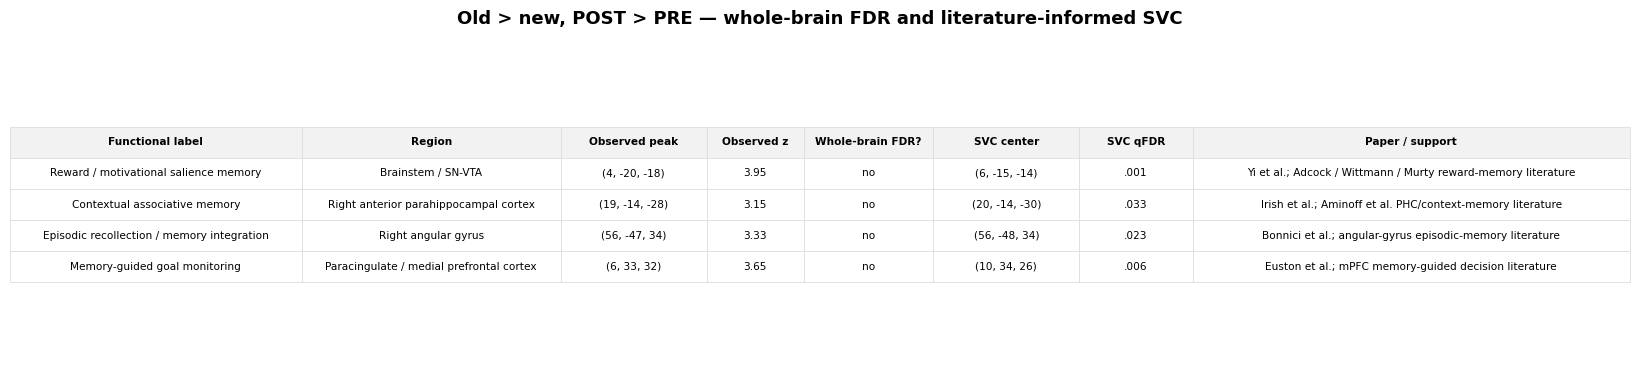

Saved table PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_compact_presentation_table.png

Recommended outputs:
Compact table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_compact_presentation_table.png
Summary CSV: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_wholebrain_FDR_and_SVC_summary.csv
Figure index: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks/pre_post_old_new_vie

In [20]:
# ============================================================
# Old/New GLM — final whole-brain figures + whole-brain FDR + SVC table
#
# Supervisor format:
# - show whole-brain thresholded activation map
# - no black cross
# - add red circle later in PowerPoint
# - report whether peak survives whole-brain FDR
# - if not, report 6 mm SVC qFDR from literature/support coordinate
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn import plotting
from nilearn.image import load_img, new_img_like, resample_to_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

oldnew_wb_fig_dir = dirs["figures"] / "final_old_new_wholebrain_selected_peaks"
oldnew_wb_table_dir = dirs["tables"] / "final_old_new_wholebrain_selected_peaks"

oldnew_wb_fig_dir.mkdir(parents=True, exist_ok=True)
oldnew_wb_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving whole-brain figures to:", oldnew_wb_fig_dir)
print("Saving tables to:", oldnew_wb_table_dir)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

CONTRAST_LABEL = "Old > new, POST > PRE"

CONTRAST_NAME_CANDIDATES = [
    "old_gt_new_post_gt_pre",
    "old_new_post_gt_pre",
    "old_gt_new_post_pre",
]

DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0
SVC_RADIUS_MM = 6.0

assert "second_level_table" in globals(), "second_level_table not found."

available_contrasts = second_level_table["contrast"].dropna().astype(str).tolist()

CONTRAST_NAME = None
for c in CONTRAST_NAME_CANDIDATES:
    if c in available_contrasts:
        CONTRAST_NAME = c
        break

if CONTRAST_NAME is None:
    matches = [
        c for c in available_contrasts
        if ("old" in c.lower())
        and ("new" in c.lower())
        and ("post" in c.lower())
        and ("pre" in c.lower())
    ]
    print("Available contrasts:")
    for c in available_contrasts:
        print(" -", c)
    assert len(matches) > 0, "Could not find Old > new, POST > PRE contrast."
    CONTRAST_NAME = matches[0]
    print("Using first Old/New POST/PRE-like contrast:", CONTRAST_NAME)

z_map_path = Path(
    second_level_table.set_index("contrast").loc[CONTRAST_NAME, "z_map_path"]
)

z_img = load_img(str(z_map_path))
z_data = z_img.get_fdata()

print("Using contrast:", CONTRAST_NAME)
print("Using z-map:", z_map_path)

BG_IMG = (
    mean_t1w_img
    if globals().get("USE_MEAN_T1W_BACKGROUND", True) and "mean_t1w_img" in globals()
    else None
)

# ------------------------------------------------------------
# Selected peaks with functional names
# ------------------------------------------------------------

OLDNEW_FINAL_PEAKS = [
    {
        "result_name": "sn_vta_reward_memory",
        "functional_name": "Reward / motivational salience memory",
        "region_label": "Brainstem / SN-VTA",
        "observed_peak": (4.0, -19.5, -18.0),
        "svc_center": (6.0, -15.0, -14.0),
        "svc_label": "SN/VTA reward-memory coordinate",
        "paper_support": "Yi et al.; Adcock / Wittmann / Murty reward-memory literature",
        "interpretation": "Dopaminergic motivation/reward-related memory modulation",
    },
    {
        "result_name": "contextual_associative_memory_phg",
        "functional_name": "Contextual associative memory",
        "region_label": "Right anterior parahippocampal cortex",
        "observed_peak": (19.0, -14.5, -28.0),
        "svc_center": (20.0, -14.0, -30.0),
        "svc_label": "Right PHG/MTL episodic-recall coordinate",
        "paper_support": "Irish et al.; Aminoff et al. PHC/context-memory literature",
        "interpretation": "Scene/contextual associative memory",
    },
    {
        "result_name": "episodic_recollection_angular",
        "functional_name": "Episodic recollection / memory integration",
        "region_label": "Right angular gyrus",
        "observed_peak": (56.5, -47.0, 34.5),
        "svc_center": (56.0, -48.0, 34.0),
        "svc_label": "Right angular gyrus coordinate",
        "paper_support": "Bonnici et al.; angular-gyrus episodic-memory literature",
        "interpretation": "Episodic recollection and multimodal memory integration",
    },
    {
        "result_name": "memory_guided_goal_monitoring_mpfc",
        "functional_name": "Memory-guided goal monitoring",
        "region_label": "Paracingulate / medial prefrontal cortex",
        "observed_peak": (6.5, 33.0, 32.0),
        "svc_center": (10.0, 34.0, 26.0),
        "svc_label": "Paracingulate / mPFC coordinate",
        "paper_support": "Euston et al.; mPFC memory-guided decision literature",
        "interpretation": "Memory-guided decision processes and goal monitoring",
    },
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def z_at_mni_coord(z_img, coord):
    data = z_img.get_fdata()
    inv_affine = np.linalg.inv(z_img.affine)
    voxel = np.round(
        inv_affine.dot(np.array([coord[0], coord[1], coord[2], 1]))[:3]
    ).astype(int)

    if (
        0 <= voxel[0] < data.shape[0]
        and 0 <= voxel[1] < data.shape[1]
        and 0 <= voxel[2] < data.shape[2]
    ):
        return float(data[tuple(voxel)]), tuple(voxel)

    return np.nan, tuple(voxel)


def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)


def run_sphere_svc(z_img, sphere_img):
    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels."

    z_inside = z_data[sphere_data]

    peak_index = int(np.nanargmax(z_inside))
    peak_z = float(z_inside[peak_index])

    p_values = norm.sf(z_inside)
    peak_p_unc = float(norm.sf(peak_z))

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    peak_q_fdr = float(q_values[peak_index])
    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))

    return {
        "n_voxels_in_sphere": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
    }


def save_clean_table_png(
    df,
    out_path,
    title=None,
    fontsize=8.0,
    header_fontsize=8.0,
    scale_y=1.65,
    col_widths=None,
    figsize=None,
):
    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.4), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:", out_path)


# ------------------------------------------------------------
# Whole-brain voxelwise FDR correction
# ------------------------------------------------------------
# One-sided positive test for Old > new.
# This tests whether each peak survives voxelwise FDR across the whole brain.

brain_mask = np.isfinite(z_data) & (np.abs(z_data) > 0)

z_values = z_data[brain_mask]
p_values_wb = norm.sf(z_values)

_, q_values_wb, _, _ = multipletests(
    p_values_wb,
    alpha=0.05,
    method="fdr_bh",
)

q_map_data = np.full(z_data.shape, np.nan)
q_map_data[brain_mask] = q_values_wb

wb_min_q = np.nanmin(q_map_data)
wb_n_q05 = int(np.sum(q_map_data < 0.05))

print(f"Whole-brain voxelwise FDR: min q = {fmt_p(wb_min_q)}, n voxels q<.05 = {wb_n_q05}")

q_map_img = new_img_like(z_img, q_map_data)

q_map_path = (
    oldnew_wb_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_wholebrain_voxelwise_qFDR_map.nii.gz"
)
q_map_img.to_filename(str(q_map_path))

# ------------------------------------------------------------
# Main loop: plot whole-brain map at each peak and compute SVC
# ------------------------------------------------------------

summary_rows = []
figure_rows = []

for spec in OLDNEW_FINAL_PEAKS:

    observed_peak = spec["observed_peak"]
    svc_center = spec["svc_center"]

    print("\n" + "=" * 90)
    print(spec["functional_name"])
    print("Observed peak:", observed_peak)
    print("SVC center:", svc_center)

    observed_z, observed_voxel = z_at_mni_coord(z_img, observed_peak)

    if (
        0 <= observed_voxel[0] < q_map_data.shape[0]
        and 0 <= observed_voxel[1] < q_map_data.shape[1]
        and 0 <= observed_voxel[2] < q_map_data.shape[2]
    ):
        observed_q_wb = float(q_map_data[observed_voxel])
    else:
        observed_q_wb = np.nan

    wb_fdr_survives = pd.notna(observed_q_wb) and observed_q_wb < 0.05

    # SVC sphere
    svc_sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=svc_center,
        radius_mm=SVC_RADIUS_MM,
    )

    svc_sphere_resampled = resample_to_img(
        svc_sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    svc_result = run_sphere_svc(
        z_img=z_img,
        sphere_img=svc_sphere_resampled,
    )

    svc_peak = (
        svc_result["peak_x"],
        svc_result["peak_y"],
        svc_result["peak_z_coord"],
    )

    q_svc_label = fmt_p(svc_result["peak_q_fdr_within_sphere"])
    q_wb_label = fmt_p(observed_q_wb)

    # Save SVC mask
    svc_sphere_path = (
        oldnew_wb_table_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_6mm_SVC_sphere_mask.nii.gz"
    )
    svc_sphere_resampled.to_filename(str(svc_sphere_path))

    # Title rule:
    # If whole-brain FDR survives, report whole-brain q.
    # Otherwise, report SVC qFDR in table/slide title.
    if wb_fdr_survives:
        inferential_label = f"whole-brain FDR q {q_wb_label}"
    else:
        inferential_label = (
            f"6 mm SVC centered at {fmt_coord(*svc_center)}, qFDR {q_svc_label}"
        )

    title_text = (
        f"{CONTRAST_LABEL}\n"
        f"{spec['functional_name']}, {inferential_label}"
    )

    fig_png = (
        oldnew_wb_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_wholebrain_no_cross.png"
    )

    fig_pdf = (
        oldnew_wb_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_wholebrain_no_cross.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        z_img,
        bg_img=BG_IMG,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=observed_peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(fig_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Observed z:", observed_z)
    print("Whole-brain q at observed peak:", q_wb_label)
    print("Whole-brain FDR survives:", wb_fdr_survives)
    print("SVC peak:", svc_peak)
    print("SVC z:", svc_result["peak_z_stat"])
    print("SVC qFDR:", q_svc_label)

    summary_rows.append({
        "Functional label": spec["functional_name"],
        "Region": spec["region_label"],
        "Observed peak": fmt_coord(*observed_peak),
        "Observed z": f"{observed_z:.2f}",
        "Whole-brain qFDR": q_wb_label,
        "Whole-brain FDR?": "yes" if wb_fdr_survives else "no",
        "SVC center": fmt_coord(*svc_center),
        "SVC peak": fmt_coord(*svc_peak),
        "SVC z": f"{svc_result['peak_z_stat']:.2f}",
        "SVC qFDR": q_svc_label,
        "Paper / support": spec["paper_support"],
        "Interpretation": spec["interpretation"],
    })

    figure_rows.append({
        "Functional label": spec["functional_name"],
        "Region": spec["region_label"],
        "Figure": str(fig_png),
        "Figure PDF": str(fig_pdf),
        "SVC mask": str(svc_sphere_path),
    })

# ------------------------------------------------------------
# Save summary tables
# ------------------------------------------------------------

oldnew_wb_svc_summary = pd.DataFrame(summary_rows)

summary_csv = (
    oldnew_wb_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_wholebrain_FDR_and_SVC_summary.csv"
)

oldnew_wb_svc_summary.to_csv(summary_csv, index=False)

print("\nWhole-brain FDR + SVC summary:")
display(oldnew_wb_svc_summary)

print("Saved summary CSV:")
print(summary_csv)

figure_index = pd.DataFrame(figure_rows)

figure_index_csv = (
    oldnew_wb_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_wholebrain_selected_peak_figure_index.csv"
)

figure_index.to_csv(figure_index_csv, index=False)

print("\nFigure index:")
display(figure_index)

print("Saved figure index:")
print(figure_index_csv)

# Compact presentation table
compact_oldnew_results = oldnew_wb_svc_summary[
    [
        "Functional label",
        "Region",
        "Observed peak",
        "Observed z",
        "Whole-brain FDR?",
        "SVC center",
        "SVC qFDR",
        "Paper / support",
    ]
].copy()

compact_csv = (
    oldnew_wb_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_compact_presentation_table.csv"
)
compact_oldnew_results.to_csv(compact_csv, index=False)

compact_png = (
    oldnew_wb_fig_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_compact_presentation_table.png"
)

save_clean_table_png(
    compact_oldnew_results,
    compact_png,
    title="Old > new, POST > PRE — whole-brain FDR and literature-informed SVC",
    fontsize=7.6,
    header_fontsize=7.6,
    scale_y=1.75,
    col_widths=[0.18, 0.16, 0.09, 0.06, 0.08, 0.09, 0.07, 0.27],
    figsize=(16.5, 3.8),
)

print("\nRecommended outputs:")
print("Compact table:", compact_png)
print("Summary CSV:", summary_csv)
print("Figure index:", figure_index_csv)
print("Whole-brain q-map:", q_map_path)

Saving corrected-title figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks_TITLE_FIXED


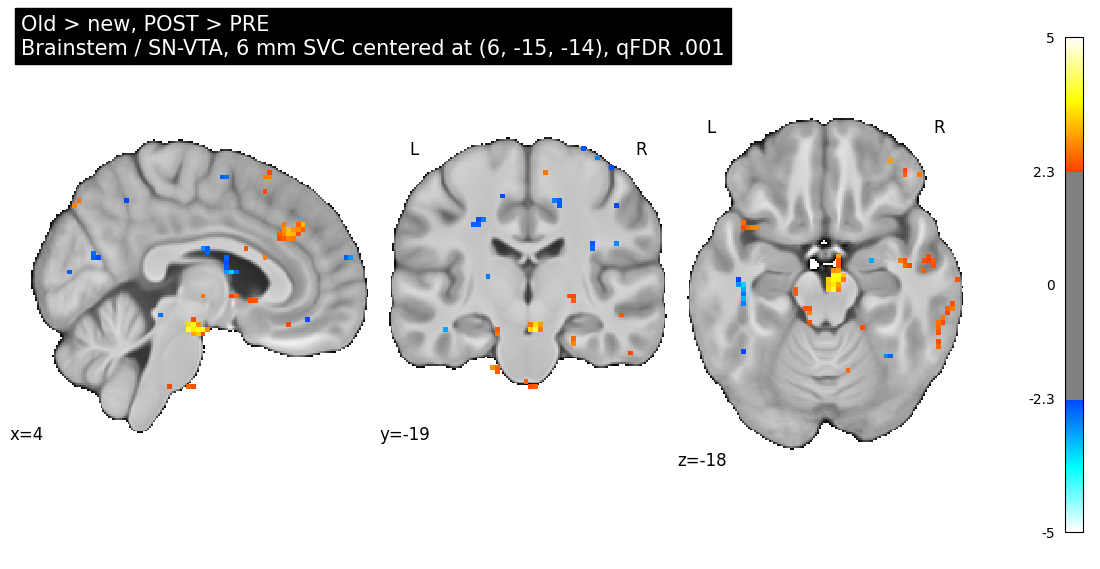

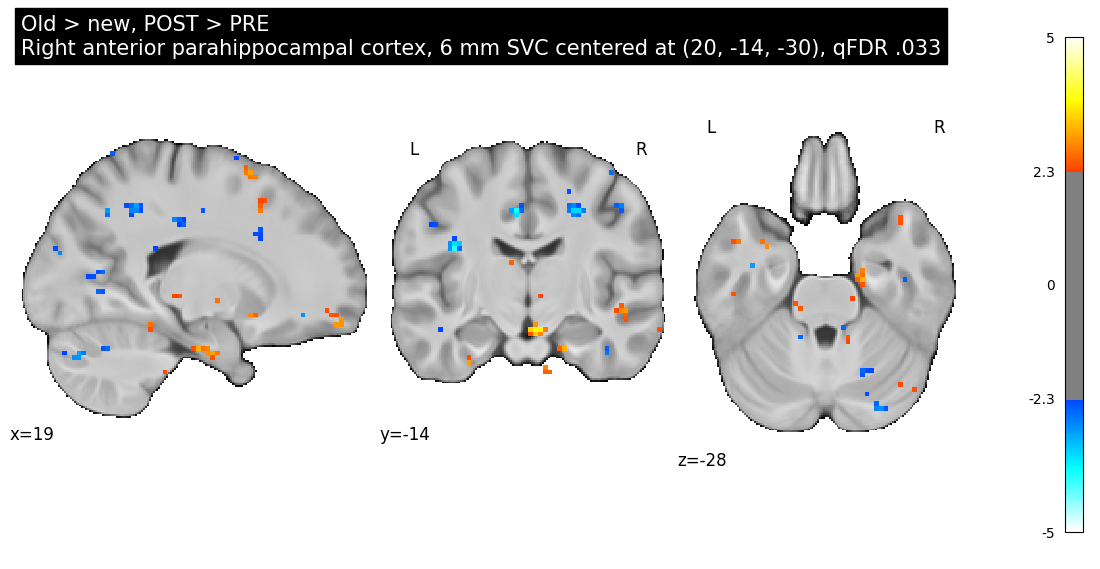

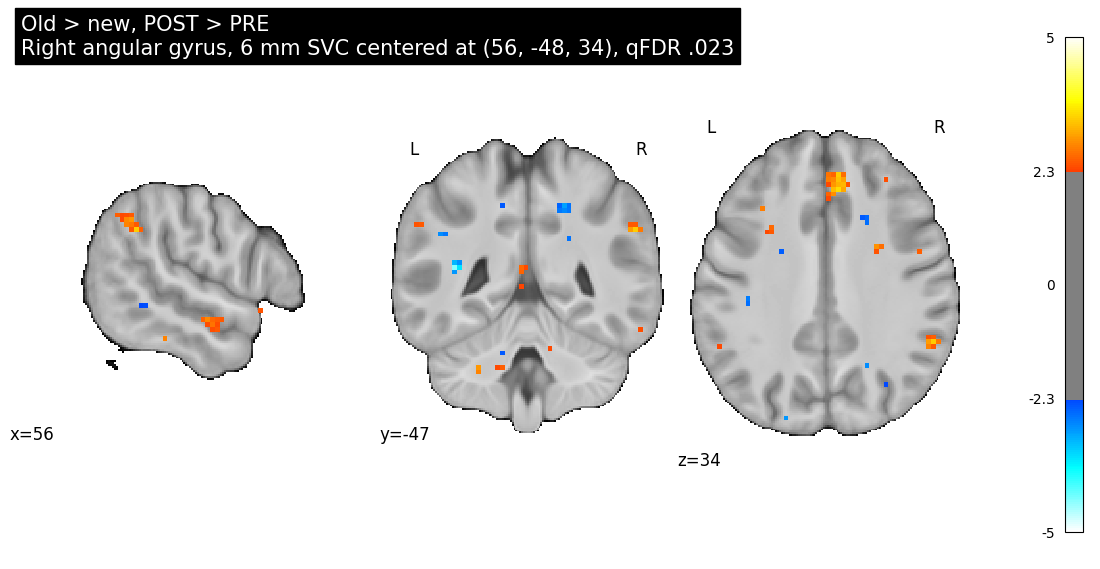

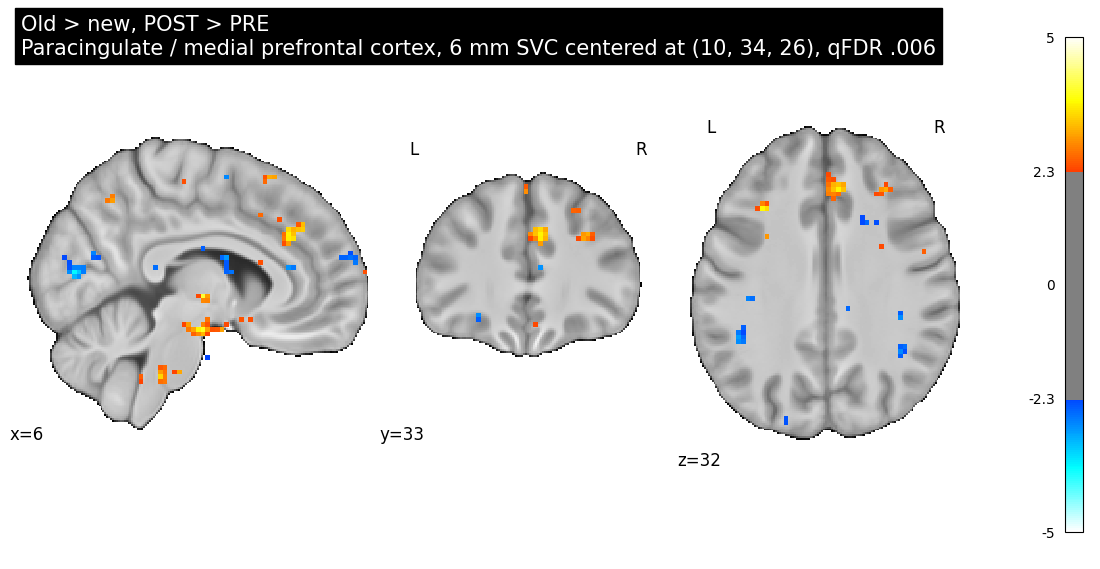


Corrected-title figure index:


,Region title,Observed peak,SVC center,SVC qFDR,Whole-brain FDR?,Figure PNG,Figure PDF
0,Brainstem / SN-VTA,"(4, -20, -18)","(6, -15, -14)",.001,no,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...
1,Right anterior parahippocampal cortex,"(19, -14, -28)","(20, -14, -30)",.033,no,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...
2,Right angular gyrus,"(56, -47, 34)","(56, -48, 34)",.023,no,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...
3,Paracingulate / medial prefrontal cortex,"(6, 33, 32)","(10, 34, 26)",.006,no,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_corrected_title_figure_index.csv


In [21]:
# ============================================================
# Replot Old/New whole-brain figures with anatomical/functional
# region labels only, not interpretation labels
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from nilearn import plotting
from nilearn.image import load_img

assert "oldnew_wb_svc_summary" in globals(), "Run the whole-brain FDR + SVC cell first."
assert "figure_index" in globals(), "Run the whole-brain FDR + SVC cell first."
assert "z_img" in globals(), "z_img not found."
assert "OLDNEW_FINAL_PEAKS" in globals(), "OLDNEW_FINAL_PEAKS not found."

# Output folder for corrected titles
oldnew_titlefix_fig_dir = dirs["figures"] / "final_old_new_wholebrain_selected_peaks_TITLE_FIXED"
oldnew_titlefix_fig_dir.mkdir(parents=True, exist_ok=True)

print("Saving corrected-title figures to:", oldnew_titlefix_fig_dir)

# Use only anatomical / functional region names in figure title
TITLE_REGION_LABELS = {
    "sn_vta_reward_memory": "Brainstem / SN-VTA",
    "contextual_associative_memory_phg": "Right anterior parahippocampal cortex",
    "episodic_recollection_angular": "Right angular gyrus",
    "memory_guided_goal_monitoring_mpfc": "Paracingulate / medial prefrontal cortex",
}

def fmt_p_title(x):
    if pd.isna(x):
        return "—"
    x = float(str(x).replace("<", "").replace(" ", "")) if isinstance(x, str) else float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")

def fmt_coord_title(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"

# Build lookup from previous summary table
summary_lookup = {
    row["Region"]: row
    for _, row in oldnew_wb_svc_summary.iterrows()
}

corrected_figure_rows = []

for spec in OLDNEW_FINAL_PEAKS:

    result_name = spec["result_name"]
    observed_peak = spec["observed_peak"]
    svc_center = spec["svc_center"]

    region_title = TITLE_REGION_LABELS.get(result_name, spec["region_label"])

    # Find corresponding summary row
    region_summary = oldnew_wb_svc_summary[
        oldnew_wb_svc_summary["Region"] == spec["region_label"]
    ]

    if len(region_summary) == 0:
        print(f"WARNING: no summary row found for {spec['region_label']}. Using spec q info if available.")
        svc_q = "?"
        wb_fdr = "no"
        wb_q = "?"
    else:
        row = region_summary.iloc[0]
        svc_q = row["SVC qFDR"]
        wb_fdr = row["Whole-brain FDR?"]
        wb_q = row["Whole-brain qFDR"]

    # Title rule:
    # If whole-brain FDR survives, report it.
    # Otherwise report literature-informed SVC.
    if str(wb_fdr).lower() == "yes":
        inferential_label = f"whole-brain FDR q {wb_q}"
    else:
        inferential_label = (
            f"6 mm SVC centered at {fmt_coord_title(*svc_center)}, qFDR {svc_q}"
        )

    title_text = (
        f"{CONTRAST_LABEL}\n"
        f"{region_title}, {inferential_label}"
    )

    fig_png = (
        oldnew_titlefix_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{result_name}_wholebrain_no_cross_TITLE_FIXED.png"
    )

    fig_pdf = (
        oldnew_titlefix_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{result_name}_wholebrain_no_cross_TITLE_FIXED.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        z_img,
        bg_img=BG_IMG,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=observed_peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(fig_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    corrected_figure_rows.append({
        "Region title": region_title,
        "Observed peak": fmt_coord_title(*observed_peak),
        "SVC center": fmt_coord_title(*svc_center),
        "SVC qFDR": svc_q,
        "Whole-brain FDR?": wb_fdr,
        "Figure PNG": str(fig_png),
        "Figure PDF": str(fig_pdf),
    })

corrected_title_figure_index = pd.DataFrame(corrected_figure_rows)

corrected_title_csv = (
    oldnew_wb_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_corrected_title_figure_index.csv"
)

corrected_title_figure_index.to_csv(corrected_title_csv, index=False)

print("\nCorrected-title figure index:")
display(corrected_title_figure_index)

print("Saved:")
print(corrected_title_csv)

Saving hippocampus check figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_hippocampus_check
Saving hippocampus check tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_hippocampus_check
Using contrast: old_gt_new_post_gt_pre
Using z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_old_gt_new_post_gt_pre_smoothed5mm_zmap.nii.gz
Found 13 hippocampus/hippoAmyg mask candidates.
00: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/group_consensus_hippoAmyg_threshold-0.50_mask.nii.gz
01: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encod

,Contrast,ROI,Peak,max z,p unc.,pBonf ROI,qFDR ROI,n voxels,n vox z≥2.33,n vox z≥3.00
0,"Old > new, POST > PRE",Left hippocampus / hippoAmyg ROI,"(-16, -12, -13)",2.68,.004,1.000,.775,770,4,0
1,"Old > new, POST > PRE",Right hippocampus / hippoAmyg ROI,"(19, -10, -28)",2.79,.003,1.000,.978,774,4,0
2,"Old > new, POST > PRE",Bilateral hippocampus / hippoAmyg ROI,"(19, -10, -28)",2.79,.003,1.000,.929,1544,8,0


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_hippocampus_check/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_hippocampus_ROI_check.csv

Strongest bilateral hippocampus/hippoAmyg voxel:
Peak: (19, -10, -28)
z: 2.79
qFDR ROI: .929


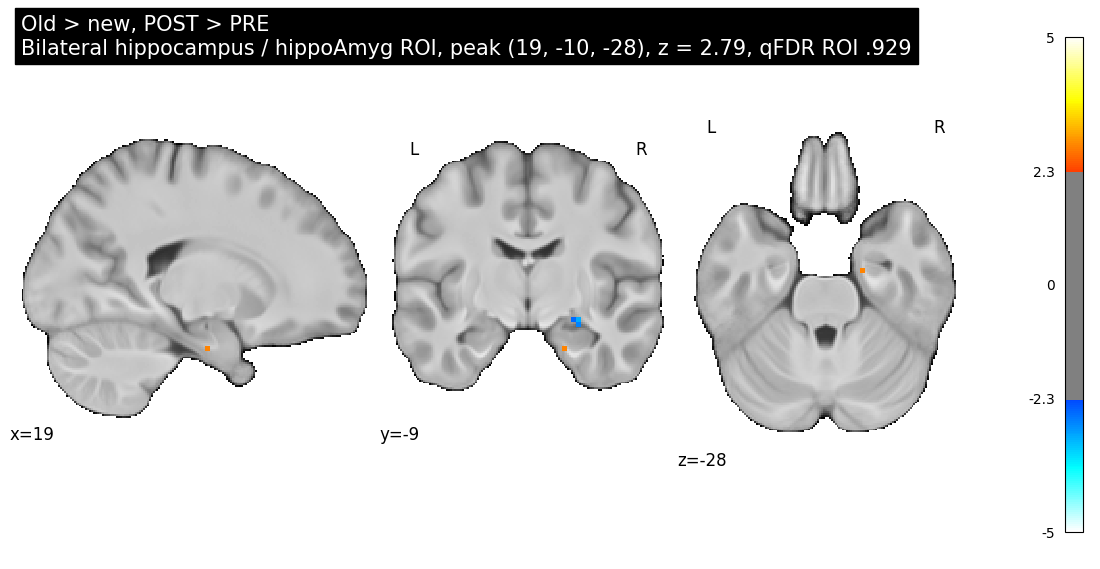

Saved hippocampus check plot:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_hippocampus_check/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_hippocampus_ROI_strongest_voxel.png

Interpretation:
There is some subthreshold/exploratory hippocampal signal, but it does not survive ROI-level FDR correction.


In [22]:
# ============================================================
# Final check: does Old > new, POST > PRE activate hippocampus?
#
# Checks:
# 1) Left hippocampus/hippoAmyg ROI
# 2) Right hippocampus/hippoAmyg ROI
# 3) Bilateral ROI
#
# Reports:
# - max z inside ROI
# - peak coordinate
# - p_unc, pBonf within ROI, qFDR within ROI
# - number of voxels above z thresholds
# - optional plot if z >= 2.33 or z >= 3.00
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn import plotting
from nilearn.image import load_img, resample_to_img, new_img_like, math_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

hippo_check_fig_dir = dirs["figures"] / "final_old_new_hippocampus_check"
hippo_check_table_dir = dirs["tables"] / "final_old_new_hippocampus_check"

hippo_check_fig_dir.mkdir(parents=True, exist_ok=True)
hippo_check_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving hippocampus check figures to:", hippo_check_fig_dir)
print("Saving hippocampus check tables to:", hippo_check_table_dir)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

CONTRAST_LABEL = "Old > new, POST > PRE"

CONTRAST_NAME_CANDIDATES = [
    "old_gt_new_post_gt_pre",
    "old_new_post_gt_pre",
    "old_gt_new_post_pre",
]

DISPLAY_THRESHOLD_Z = 2.33
STRONG_THRESHOLD_Z = 3.00
VMAX = 5.0

# ------------------------------------------------------------
# Find z-map robustly
# ------------------------------------------------------------

assert "second_level_table" in globals(), "second_level_table not found."

available_contrasts = second_level_table["contrast"].dropna().astype(str).tolist()

CONTRAST_NAME = None
for c in CONTRAST_NAME_CANDIDATES:
    if c in available_contrasts:
        CONTRAST_NAME = c
        break

if CONTRAST_NAME is None:
    matches = [
        c for c in available_contrasts
        if ("old" in c.lower())
        and ("new" in c.lower())
        and ("post" in c.lower())
        and ("pre" in c.lower())
    ]
    print("Available contrasts:")
    for c in available_contrasts:
        print(" -", c)
    assert len(matches) > 0, "Could not find Old > new, POST > PRE contrast."
    CONTRAST_NAME = matches[0]

z_map_path = Path(
    second_level_table.set_index("contrast").loc[CONTRAST_NAME, "z_map_path"]
)

z_img = load_img(str(z_map_path))
z_data = z_img.get_fdata()

print("Using contrast:", CONTRAST_NAME)
print("Using z-map:", z_map_path)

BG_IMG = (
    mean_t1w_img
    if globals().get("USE_MEAN_T1W_BACKGROUND", True) and "mean_t1w_img" in globals()
    else None
)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")

def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"

def count_vox(mask_img):
    return int((mask_img.get_fdata() > 0).sum())

def split_mask_by_hemisphere(mask_img):
    data = mask_img.get_fdata() > 0
    ijk = np.array(np.where(data)).T
    xyz = nib.affines.apply_affine(mask_img.affine, ijk)

    left_data = np.zeros(mask_img.shape[:3], dtype=np.uint8)
    right_data = np.zeros(mask_img.shape[:3], dtype=np.uint8)

    left_ijk = ijk[xyz[:, 0] < 0]
    right_ijk = ijk[xyz[:, 0] > 0]

    if len(left_ijk) > 0:
        left_data[tuple(left_ijk.T)] = 1
    if len(right_ijk) > 0:
        right_data[tuple(right_ijk.T)] = 1

    return new_img_like(mask_img, left_data), new_img_like(mask_img, right_data)

def find_hippocampus_masks():
    """
    Tries to find already-created left/right hippocampus or hippoAmyg masks.
    If only a bilateral mask is found, splits it by x-coordinate.
    """

    # 1) In-memory masks
    if "left_roi_group_mask_img" in globals() and "right_roi_group_mask_img" in globals():
        if count_vox(left_roi_group_mask_img) > 0 and count_vox(right_roi_group_mask_img) > 0:
            print("Using left_roi_group_mask_img / right_roi_group_mask_img from memory.")
            return left_roi_group_mask_img, right_roi_group_mask_img, "memory masks"

    # 2) Search likely folders
    search_roots = []

    search_roots.append(dirs["tables"])
    search_roots.append(dirs["figures"])

    if "PROJECT_ROOT" in globals():
        search_roots.extend([
            Path(PROJECT_ROOT) / "data" / "rois",
            Path(PROJECT_ROOT) / "data" / "rois" / "hippoAmyg_02022024",
            Path(PROJECT_ROOT) / "data" / "processed" / "glm",
        ])

    search_roots = [Path(p) for p in search_roots if Path(p).exists()]

    candidates = []
    for root in search_roots:
        for p in root.rglob("*.nii*"):
            name = p.name.lower()
            if (
                ("hippo" in name or "hippocampus" in name or "hippoamyg" in name)
                and ("mask" in name or "roi" in name)
                and ("zmap" not in name)
                and ("stat" not in name)
                and ("cluster" not in name)
            ):
                candidates.append(p)

    candidates = sorted(set(candidates))

    print(f"Found {len(candidates)} hippocampus/hippoAmyg mask candidates.")
    for i, p in enumerate(candidates[:30]):
        print(f"{i:02d}: {p}")

    # Prefer explicit left/right group masks
    left_candidates = []
    right_candidates = []
    bilateral_candidates = []

    for p in candidates:
        name = p.name.lower()
        is_left = ("left" in name) or ("_l_" in name) or ("lh" in name)
        is_right = ("right" in name) or ("_r_" in name) or ("rh" in name)

        if is_left and not is_right:
            left_candidates.append(p)
        elif is_right and not is_left:
            right_candidates.append(p)
        else:
            bilateral_candidates.append(p)

    def score_path(p):
        s = str(p).lower()
        score = 0
        if "group" in s:
            score += 10
        if "consensus" in s:
            score += 10
        if "threshold" in s:
            score += 5
        if "hippoamyg" in s:
            score += 5
        if "sub-" in s:
            score -= 5
        return score

    left_candidates = sorted(left_candidates, key=score_path, reverse=True)
    right_candidates = sorted(right_candidates, key=score_path, reverse=True)
    bilateral_candidates = sorted(bilateral_candidates, key=score_path, reverse=True)

    if len(left_candidates) > 0 and len(right_candidates) > 0:
        left_img = load_img(str(left_candidates[0]))
        right_img = load_img(str(right_candidates[0]))

        if count_vox(left_img) > 0 and count_vox(right_img) > 0:
            print("Using explicit left/right masks:")
            print("Left:", left_candidates[0])
            print("Right:", right_candidates[0])
            return left_img, right_img, f"{left_candidates[0]} | {right_candidates[0]}"

    # Otherwise use bilateral and split
    for p in bilateral_candidates:
        try:
            img = load_img(str(p))
            if count_vox(img) == 0:
                continue

            left_img, right_img = split_mask_by_hemisphere(img)

            if count_vox(left_img) > 0 and count_vox(right_img) > 0:
                print("Using bilateral mask split by hemisphere:")
                print(p)
                return left_img, right_img, str(p)

        except Exception as e:
            print("Could not use:", p, repr(e))

    raise FileNotFoundError(
        "Could not find hippocampus/hippoAmyg masks. "
        "Run the ROI mask generation cells or provide the mask path."
    )

def run_roi_peak_stats(z_img, roi_img):
    roi_resampled = resample_to_img(
        roi_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    roi_data = roi_resampled.get_fdata() > 0

    n_vox = int(roi_data.sum())
    assert n_vox > 0, "ROI has zero voxels."

    z_inside = z_data[roi_data]

    peak_idx = int(np.nanargmax(z_inside))
    peak_z = float(z_inside[peak_idx])

    p_values = norm.sf(z_inside)
    peak_p_unc = float(norm.sf(peak_z))

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    roi_indices = np.array(np.where(roi_data)).T
    peak_ijk = roi_indices[peak_idx]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    return {
        "n_voxels": n_vox,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "p_unc": peak_p_unc,
        "pBonf_ROI": float(min(peak_p_unc * n_vox, 1.0)),
        "qFDR_ROI": float(q_values[peak_idx]),
        "n_vox_z_gt_2.33": int(np.sum(z_inside >= 2.33)),
        "n_vox_z_gt_3.00": int(np.sum(z_inside >= 3.00)),
        "roi_img": roi_resampled,
    }

# ------------------------------------------------------------
# Load masks
# ------------------------------------------------------------

left_hippo_img, right_hippo_img, mask_source = find_hippocampus_masks()

# Create bilateral
left_data = resample_to_img(left_hippo_img, z_img, interpolation="nearest", force_resample=True, copy_header=True).get_fdata() > 0
right_data = resample_to_img(right_hippo_img, z_img, interpolation="nearest", force_resample=True, copy_header=True).get_fdata() > 0
bilateral_data = (left_data | right_data).astype(np.uint8)
bilateral_hippo_img = new_img_like(z_img, bilateral_data)

print("\nMask source:", mask_source)
print("Left voxels:", count_vox(left_hippo_img))
print("Right voxels:", count_vox(right_hippo_img))
print("Bilateral voxels:", count_vox(bilateral_hippo_img))

# ------------------------------------------------------------
# Run ROI stats
# ------------------------------------------------------------

roi_specs = [
    ("Left hippocampus / hippoAmyg ROI", left_hippo_img),
    ("Right hippocampus / hippoAmyg ROI", right_hippo_img),
    ("Bilateral hippocampus / hippoAmyg ROI", bilateral_hippo_img),
]

hippo_rows = []

for roi_name, roi_img in roi_specs:
    res = run_roi_peak_stats(z_img, roi_img)
    peak = (res["peak_x"], res["peak_y"], res["peak_z_coord"])

    hippo_rows.append({
        "Contrast": CONTRAST_LABEL,
        "ROI": roi_name,
        "Peak": fmt_coord(*peak),
        "max z": f"{res['peak_z_stat']:.2f}",
        "p unc.": fmt_p(res["p_unc"]),
        "pBonf ROI": fmt_p(res["pBonf_ROI"]),
        "qFDR ROI": fmt_p(res["qFDR_ROI"]),
        "n voxels": res["n_voxels"],
        "n vox z≥2.33": res["n_vox_z_gt_2.33"],
        "n vox z≥3.00": res["n_vox_z_gt_3.00"],
    })

hippo_oldnew_check_table = pd.DataFrame(hippo_rows)

hippo_csv = (
    hippo_check_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_hippocampus_ROI_check.csv"
)
hippo_oldnew_check_table.to_csv(hippo_csv, index=False)

print("\nOld > new hippocampus ROI check:")
display(hippo_oldnew_check_table)

print("Saved:")
print(hippo_csv)

# ------------------------------------------------------------
# Optional plot of strongest hippocampal voxel if anything appears
# ------------------------------------------------------------

bilat_res = run_roi_peak_stats(z_img, bilateral_hippo_img)
bilat_peak = (
    bilat_res["peak_x"],
    bilat_res["peak_y"],
    bilat_res["peak_z_coord"],
)

print("\nStrongest bilateral hippocampus/hippoAmyg voxel:")
print("Peak:", fmt_coord(*bilat_peak))
print("z:", f"{bilat_res['peak_z_stat']:.2f}")
print("qFDR ROI:", fmt_p(bilat_res["qFDR_ROI"]))

masked_hippo_z_img = math_img(
    "zmap * (roi > 0)",
    zmap=z_img,
    roi=bilateral_hippo_img,
)

masked_hippo_path = (
    hippo_check_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_zmap_masked_to_bilateral_hippocampus.nii.gz"
)
masked_hippo_z_img.to_filename(str(masked_hippo_path))

if bilat_res["peak_z_stat"] >= DISPLAY_THRESHOLD_Z:
    title_text = (
        f"{CONTRAST_LABEL}\n"
        f"Bilateral hippocampus / hippoAmyg ROI, peak {fmt_coord(*bilat_peak)}, "
        f"z = {bilat_res['peak_z_stat']:.2f}, qFDR ROI {fmt_p(bilat_res['qFDR_ROI'])}"
    )

    hippo_plot_png = (
        hippo_check_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_hippocampus_ROI_strongest_voxel.png"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        masked_hippo_z_img,
        bg_img=BG_IMG,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=bilat_peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(hippo_plot_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved hippocampus check plot:")
    print(hippo_plot_png)
else:
    print(
        "\nNo hippocampal voxel reaches display threshold "
        f"z >= {DISPLAY_THRESHOLD_Z}. No hippocampus plot generated."
    )

# ------------------------------------------------------------
# Short interpretation helper
# ------------------------------------------------------------

if bilat_res["peak_z_stat"] < DISPLAY_THRESHOLD_Z:
    print("\nInterpretation:")
    print("No visible Old > new, POST > PRE activation was detected in the hippocampus/hippoAmyg ROI at z >= 2.33.")
elif bilat_res["qFDR_ROI"] >= 0.05:
    print("\nInterpretation:")
    print("There is some subthreshold/exploratory hippocampal signal, but it does not survive ROI-level FDR correction.")
else:
    print("\nInterpretation:")
    print("A hippocampal/hippoAmyg voxel survives ROI-level FDR correction.")

Saving tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_literature_hippocampus_svc_check
Saving figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_literature_hippocampus_svc_check
Using contrast: old_gt_new_post_gt_pre
Using z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_old_gt_new_post_gt_pre_smoothed5mm_zmap.nii.gz
Old > new, POST > PRE — literature hippocampal SVC check:


,Contrast,Paper,Sphere,Concept,Sphere center,Peak in sphere,z,p unc.,pBonf sphere,qFDR sphere,Distance peak-center mm,n voxels,n vox z≥2.33,n vox z≥3.00
0,"Old > new, POST > PRE",Montagrin et al.,Montagrin L anterior HPC,Remote > current goals,"(-15, -8, -14)","(-14, -12, -10)",3.02,.001,.070,.064,5.52,56,5,1
1,"Old > new, POST > PRE",Deuker et al.,Deuker temporal R anterior HPC,Temporal distance / close temporal relationships,"(26, -18, -22)","(24, -20, -26)",2.82,.002,.136,.128,4.30,57,2,0
2,"Old > new, POST > PRE",Montagrin et al.,Montagrin R anterior HPC,Remote > current goals,"(18, -21, -14)","(19, -22, -16)",2.31,.010,.586,.176,2.06,56,0,0
3,"Old > new, POST > PRE",Viard et al.,Viard L posterior HPC,"Autobiographical memory period, left posterior hippocampus","(-30, -26, -12)","(-28, -27, -13)",2.10,.018,1.000,.251,2.06,56,0,0
4,"Old > new, POST > PRE",Montagrin et al.,Montagrin L posterior HPC,Current > remote goals,"(-30, -31, -14)","(-28, -27, -13)",2.10,.018,1.000,.351,4.53,56,0,0
5,"Old > new, POST > PRE",Deuker et al.,Deuker spatial R anterior HPC,Spatial distance / close spatial relationships,"(34, -17, -22)","(34, -12, -20)",2.01,.022,1.000,.568,5.22,61,0,0
6,"Old > new, POST > PRE",Deuker et al.,Deuker space-time R anterior HPC,Combined spatial and temporal proximity,"(32, -17, -22)","(34, -12, -20)",2.01,.022,1.000,.601,5.59,55,0,0
7,"Old > new, POST > PRE",Bellmund et al. 2022,Bellmund across-sequence L anterior HPC,"Across-sequence temporal relation, exploratory","(-26, -19, -15)","(-26, -24, -13)",1.74,.041,1.000,.645,5.85,61,0,0
8,"Old > new, POST > PRE",Bellmund et al. 2022,Bellmund interaction R anterior HPC,Temporal-distance representation differs for same vs different sequences,"(31, -16, -21)","(34, -12, -20)",2.01,.022,1.000,.682,5.02,56,0,0
9,"Old > new, POST > PRE",Viard et al.,Viard R posterior HPC secondary,"Autobiographical memory period, right posterior hippocampus secondary","(14, -38, 2)","(12, -40, 7)",1.40,.081,1.000,.907,5.79,61,0,0


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_literature_hippocampus_svc_check/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_literature_hippocampus_SVC_check.csv

Best literature hippocampal SVC:
Sphere: Montagrin L anterior HPC
Paper: Montagrin et al.
Center: (-15, -8, -14)
Peak: (-14, -12, -10)
z: 3.02
p unc: .001
pBonf: .070
qFDR: .064

Interpretation: No literature-defined hippocampal SVC survives qFDR < .05.
This supports reporting the Old > new contrast as not showing a robust hippocampal effect.


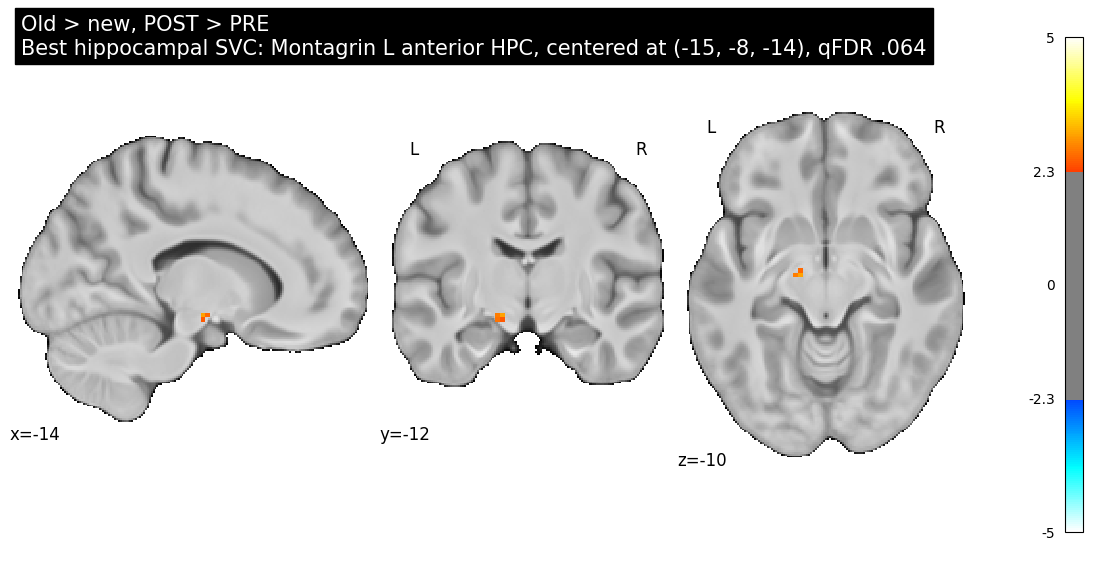

Saved best hippocampal SVC figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_literature_hippocampus_svc_check/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_best_literature_hippocampus_SVC.png


In [23]:
# ============================================================
# Old > new, POST > PRE — literature-defined hippocampal SVC check
#
# Goal:
# Test whether the weak anatomical hippocampus/hippoAmyg signal
# becomes significant in any of the independent 6 mm literature spheres
# already used in Notebooks 10–12.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img, new_img_like, resample_to_img, math_img
from nilearn import plotting
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

oldnew_lit_hippo_dir = dirs["tables"] / "final_old_new_literature_hippocampus_svc_check"
oldnew_lit_hippo_fig_dir = dirs["figures"] / "final_old_new_literature_hippocampus_svc_check"

oldnew_lit_hippo_dir.mkdir(parents=True, exist_ok=True)
oldnew_lit_hippo_fig_dir.mkdir(parents=True, exist_ok=True)

print("Saving tables to:", oldnew_lit_hippo_dir)
print("Saving figures to:", oldnew_lit_hippo_fig_dir)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

CONTRAST_LABEL = "Old > new, POST > PRE"

CONTRAST_NAME_CANDIDATES = [
    "old_gt_new_post_gt_pre",
    "old_new_post_gt_pre",
    "old_gt_new_post_pre",
]

SVC_RADIUS_MM = 6.0
DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0

assert "second_level_table" in globals(), "second_level_table not found."

available_contrasts = second_level_table["contrast"].dropna().astype(str).tolist()

CONTRAST_NAME = None
for c in CONTRAST_NAME_CANDIDATES:
    if c in available_contrasts:
        CONTRAST_NAME = c
        break

if CONTRAST_NAME is None:
    matches = [
        c for c in available_contrasts
        if ("old" in c.lower())
        and ("new" in c.lower())
        and ("post" in c.lower())
        and ("pre" in c.lower())
    ]
    assert len(matches) > 0, "Could not find Old > new, POST > PRE contrast."
    CONTRAST_NAME = matches[0]

z_map_path = Path(
    second_level_table.set_index("contrast").loc[CONTRAST_NAME, "z_map_path"]
)

z_img = load_img(str(z_map_path))

BG_IMG = (
    mean_t1w_img
    if globals().get("USE_MEAN_T1W_BACKGROUND", True) and "mean_t1w_img" in globals()
    else None
)

print("Using contrast:", CONTRAST_NAME)
print("Using z-map:", z_map_path)

# ------------------------------------------------------------
# Literature coordinates already used in the project
# ------------------------------------------------------------

OLDNEW_HIPPO_LITERATURE_CENTERS = [
    # Deuker et al.
    {
        "paper": "Deuker et al.",
        "sphere": "Deuker temporal R anterior HPC",
        "concept": "Temporal distance / close temporal relationships",
        "center": (26.0, -18.0, -22.0),
    },
    {
        "paper": "Deuker et al.",
        "sphere": "Deuker spatial R anterior HPC",
        "concept": "Spatial distance / close spatial relationships",
        "center": (34.0, -17.0, -22.0),
    },
    {
        "paper": "Deuker et al.",
        "sphere": "Deuker space-time R anterior HPC",
        "concept": "Combined spatial and temporal proximity",
        "center": (32.0, -17.0, -22.0),
    },

    # Bellmund et al.
    {
        "paper": "Bellmund et al. 2022",
        "sphere": "Bellmund same-sequence L anterior HPC",
        "concept": "Constructed event-time relations, same sequence",
        "center": (-24.0, -13.0, -20.0),
    },
    {
        "paper": "Bellmund et al. 2022",
        "sphere": "Bellmund across-sequence L anterior HPC",
        "concept": "Across-sequence temporal relation, exploratory",
        "center": (-26.0, -19.0, -15.0),
    },
    {
        "paper": "Bellmund et al. 2022",
        "sphere": "Bellmund interaction R anterior HPC",
        "concept": "Temporal-distance representation differs for same vs different sequences",
        "center": (31.0, -16.0, -21.0),
    },

    # Montagrin et al.
    {
        "paper": "Montagrin et al.",
        "sphere": "Montagrin L posterior HPC",
        "concept": "Current > remote goals",
        "center": (-30.0, -31.0, -14.5),
    },
    {
        "paper": "Montagrin et al.",
        "sphere": "Montagrin L anterior HPC",
        "concept": "Remote > current goals",
        "center": (-15.0, -8.5, -14.5),
    },
    {
        "paper": "Montagrin et al.",
        "sphere": "Montagrin R anterior HPC",
        "concept": "Remote > current goals",
        "center": (17.5, -21.0, -14.5),
    },

    # Viard et al.
    {
        "paper": "Viard et al.",
        "sphere": "Viard L posterior HPC",
        "concept": "Autobiographical memory period, left posterior hippocampus",
        "center": (-30.0, -26.0, -12.0),
    },
    {
        "paper": "Viard et al.",
        "sphere": "Viard R posterior HPC",
        "concept": "Autobiographical memory period, right posterior hippocampus",
        "center": (34.0, -38.0, -6.0),
    },
    {
        "paper": "Viard et al.",
        "sphere": "Viard R posterior HPC secondary",
        "concept": "Autobiographical memory period, right posterior hippocampus secondary",
        "center": (14.0, -38.0, 2.0),
    },
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")

def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)

def run_sphere_svc(z_img, sphere_img):
    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels."

    z_inside = z_data[sphere_data]

    peak_index = int(np.nanargmax(z_inside))
    peak_z = float(z_inside[peak_index])

    p_values = norm.sf(z_inside)
    peak_p_unc = float(norm.sf(peak_z))

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    peak_q_fdr = float(q_values[peak_index])
    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))

    return {
        "n_voxels_in_sphere": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
        "n_voxels_z_ge_2_33": int(np.sum(z_inside >= 2.33)),
        "n_voxels_z_ge_3_00": int(np.sum(z_inside >= 3.00)),
    }

def distance_mm(a, b):
    return float(np.linalg.norm(np.array(a, dtype=float) - np.array(b, dtype=float)))

# ------------------------------------------------------------
# Run all literature SVCs
# ------------------------------------------------------------

rows = []

for spec in OLDNEW_HIPPO_LITERATURE_CENTERS:

    center = spec["center"]

    sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=center,
        radius_mm=SVC_RADIUS_MM,
    )

    svc = run_sphere_svc(z_img, sphere_img)

    peak = (
        svc["peak_x"],
        svc["peak_y"],
        svc["peak_z_coord"],
    )

    rows.append({
        "Contrast": CONTRAST_LABEL,
        "Paper": spec["paper"],
        "Sphere": spec["sphere"],
        "Concept": spec["concept"],
        "Sphere center": fmt_coord(*center),
        "Peak in sphere": fmt_coord(*peak),
        "z": svc["peak_z_stat"],
        "p unc.": svc["peak_p_uncorrected"],
        "pBonf sphere": svc["peak_p_bonferroni_within_sphere"],
        "qFDR sphere": svc["peak_q_fdr_within_sphere"],
        "Distance peak-center mm": distance_mm(peak, center),
        "n voxels": svc["n_voxels_in_sphere"],
        "n vox z≥2.33": svc["n_voxels_z_ge_2_33"],
        "n vox z≥3.00": svc["n_voxels_z_ge_3_00"],
    })

oldnew_literature_hippo_svc_table = pd.DataFrame(rows)

oldnew_literature_hippo_svc_table = oldnew_literature_hippo_svc_table.sort_values(
    ["qFDR sphere", "z"],
    ascending=[True, False],
).reset_index(drop=True)

# Format for display
display_table = oldnew_literature_hippo_svc_table.copy()
for col in ["z", "Distance peak-center mm"]:
    display_table[col] = display_table[col].astype(float).map(lambda x: f"{x:.2f}")
for col in ["p unc.", "pBonf sphere", "qFDR sphere"]:
    display_table[col] = display_table[col].map(fmt_p)

print("Old > new, POST > PRE — literature hippocampal SVC check:")
display(display_table)

csv_path = (
    oldnew_lit_hippo_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_literature_hippocampus_SVC_check.csv"
)

oldnew_literature_hippo_svc_table.to_csv(csv_path, index=False)

print("Saved:")
print(csv_path)

# ------------------------------------------------------------
# Interpret best result
# ------------------------------------------------------------

best = oldnew_literature_hippo_svc_table.iloc[0]

print("\nBest literature hippocampal SVC:")
print("Sphere:", best["Sphere"])
print("Paper:", best["Paper"])
print("Center:", best["Sphere center"])
print("Peak:", best["Peak in sphere"])
print("z:", f"{best['z']:.2f}")
print("p unc:", fmt_p(best["p unc."]))
print("pBonf:", fmt_p(best["pBonf sphere"]))
print("qFDR:", fmt_p(best["qFDR sphere"]))

if best["qFDR sphere"] < 0.05:
    print("\nInterpretation: At least one literature-defined hippocampal SVC survives qFDR < .05.")
else:
    print("\nInterpretation: No literature-defined hippocampal SVC survives qFDR < .05.")
    print("This supports reporting the Old > new contrast as not showing a robust hippocampal effect.")

# ------------------------------------------------------------
# Optional plot of best sphere if it reaches z >= 2.33
# ------------------------------------------------------------

best_center_str = best["Sphere center"].replace("(", "").replace(")", "")
best_center = tuple(float(v.strip()) for v in best_center_str.split(","))

best_sphere_img = make_sphere_mask_img(
    reference_img=z_img,
    center_mni=best_center,
    radius_mm=SVC_RADIUS_MM,
)

best_sphere_resampled = resample_to_img(
    best_sphere_img,
    z_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

masked_best_img = math_img(
    "zmap * (sphere > 0)",
    zmap=z_img,
    sphere=best_sphere_resampled,
)

best_peak_str = best["Peak in sphere"].replace("(", "").replace(")", "")
best_peak = tuple(float(v.strip()) for v in best_peak_str.split(","))

if float(best["z"]) >= DISPLAY_THRESHOLD_Z:

    title_text = (
        f"{CONTRAST_LABEL}\n"
        f"Best hippocampal SVC: {best['Sphere']}, "
        f"centered at {best['Sphere center']}, qFDR {fmt_p(best['qFDR sphere'])}"
    )

    fig_path = (
        oldnew_lit_hippo_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_best_literature_hippocampus_SVC.png"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        masked_best_img,
        bg_img=BG_IMG,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=best_peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved best hippocampal SVC figure:")
    print(fig_path)
else:
    print("\nBest literature hippocampal SVC peak does not reach z >= 2.33; no figure generated.")

Saving whole-brain hippocampal trend figure to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks_TITLE_FIXED


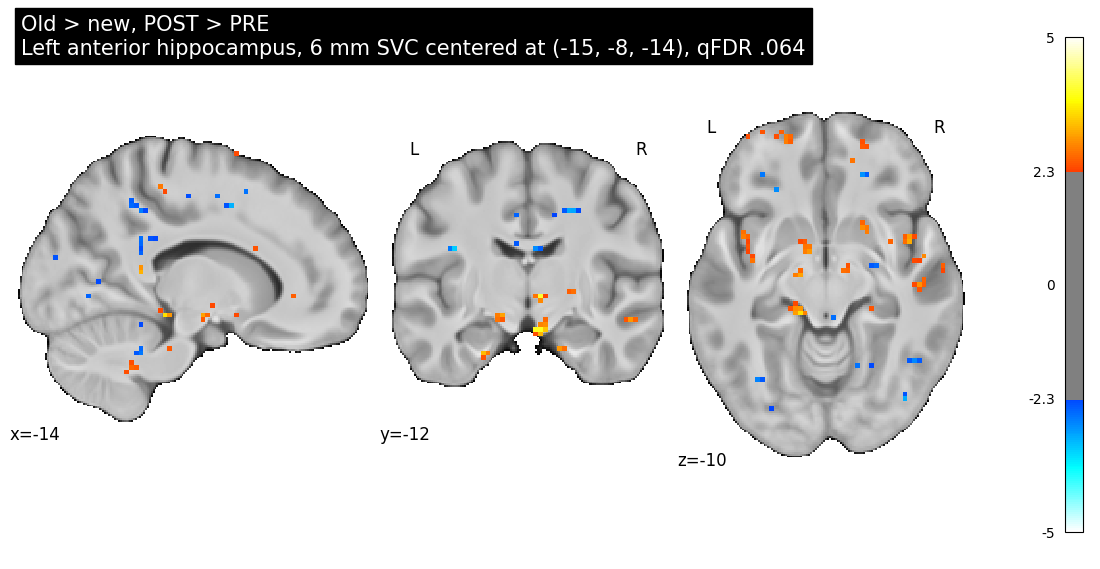

Saved hippocampal whole-brain figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks_TITLE_FIXED/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_left_anterior_hippocampus_wholebrain_no_cross_TITLE_FIXED.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks_TITLE_FIXED/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_left_anterior_hippocampus_wholebrain_no_cross_TITLE_FIXED.pdf

Slide row:


,Contrast,Region,Peak,z,SVC center,qFDR,Interpretation
0,"Old > new, POST > PRE",Left anterior hippocampus,"(-14, -12, -10)",3.02,"(-15, -8, -14)",.064,Trend-level anterior hippocampal evidence; exploratory support


Saved slide row:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_literature_hippocampus_svc_check/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_left_anterior_hippocampus_slide_row.csv


In [26]:
# ============================================================
# Replot best hippocampal Old/New effect as WHOLE-BRAIN map
# Same style as other Old/New selected whole-brain figures
#
# This plots the full whole-brain activation map at the
# Montagrin left anterior hippocampal SVC peak.
#
# Figure title reports:
# - contrast
# - functional/anatomical label
# - literature SVC center
# - qFDR
#
# The paper name is intentionally NOT in the title.
# Add paper/support on the slide instead.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from nilearn import plotting
from nilearn.image import load_img

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

oldnew_hippo_wb_fig_dir = (
    dirs["figures"]
    / "final_old_new_wholebrain_selected_peaks_TITLE_FIXED"
)

oldnew_hippo_wb_fig_dir.mkdir(parents=True, exist_ok=True)

print("Saving whole-brain hippocampal trend figure to:", oldnew_hippo_wb_fig_dir)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

CONTRAST_LABEL = "Old > new, POST > PRE"

# Use same plotting style as other whole-brain figures
DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0

# Best hippocampal literature-SVC result from previous cell
HIPPO_REGION_LABEL = "Left anterior hippocampus"
HIPPO_SVC_CENTER = (-15.0, -8.0, -14.0)
HIPPO_OBSERVED_PEAK = (-14.0, -12.0, -10.0)
HIPPO_QFDR_LABEL = ".064"

# ------------------------------------------------------------
# Make sure z_img exists; otherwise reload it
# ------------------------------------------------------------

if "z_img" not in globals():
    assert "second_level_table" in globals(), "second_level_table not found."

    CONTRAST_NAME_CANDIDATES = [
        "old_gt_new_post_gt_pre",
        "old_new_post_gt_pre",
        "old_gt_new_post_pre",
    ]

    available_contrasts = second_level_table["contrast"].dropna().astype(str).tolist()

    CONTRAST_NAME = None
    for c in CONTRAST_NAME_CANDIDATES:
        if c in available_contrasts:
            CONTRAST_NAME = c
            break

    if CONTRAST_NAME is None:
        matches = [
            c for c in available_contrasts
            if ("old" in c.lower())
            and ("new" in c.lower())
            and ("post" in c.lower())
            and ("pre" in c.lower())
        ]
        assert len(matches) > 0, "Could not find Old > new, POST > PRE contrast."
        CONTRAST_NAME = matches[0]

    z_map_path = Path(
        second_level_table.set_index("contrast").loc[CONTRAST_NAME, "z_map_path"]
    )

    z_img = load_img(str(z_map_path))

else:
    # If CONTRAST_NAME was already defined above, keep it.
    # Otherwise define it for filenames.
    if "CONTRAST_NAME" not in globals():
        CONTRAST_NAME = "old_gt_new_post_gt_pre"

# Background image
BG_IMG = (
    mean_t1w_img
    if globals().get("USE_MEAN_T1W_BACKGROUND", True) and "mean_t1w_img" in globals()
    else None
)

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def fmt_coord_simple(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

title_text = (
    f"{CONTRAST_LABEL}\n"
    f"{HIPPO_REGION_LABEL}, 6 mm SVC centered at "
    f"{fmt_coord_simple(*HIPPO_SVC_CENTER)}, qFDR {HIPPO_QFDR_LABEL}"
)

hippo_wb_png = (
    oldnew_hippo_wb_fig_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_left_anterior_hippocampus_wholebrain_no_cross_TITLE_FIXED.png"
)

hippo_wb_pdf = (
    oldnew_hippo_wb_fig_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_left_anterior_hippocampus_wholebrain_no_cross_TITLE_FIXED.pdf"
)

fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

stat_display = plotting.plot_stat_map(
    z_img,
    bg_img=BG_IMG,
    threshold=DISPLAY_THRESHOLD_Z,
    vmax=VMAX,
    cmap="cold_hot",
    symmetric_cbar=True,
    display_mode="ortho",
    cut_coords=HIPPO_OBSERVED_PEAK,
    black_bg=False,
    colorbar=True,
    annotate=True,
    draw_cross=False,
    dim=-0.2,
    figure=fig,
    title=title_text,
)

fig.savefig(hippo_wb_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(hippo_wb_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved hippocampal whole-brain figure:")
print(hippo_wb_png)
print(hippo_wb_pdf)

# ------------------------------------------------------------
# Optional: small one-row table for slide notes
# ------------------------------------------------------------

hippo_slide_row = pd.DataFrame([
    {
        "Contrast": CONTRAST_LABEL,
        "Region": HIPPO_REGION_LABEL,
        "Peak": fmt_coord_simple(*HIPPO_OBSERVED_PEAK),
        "z": "3.02",
        "SVC center": fmt_coord_simple(*HIPPO_SVC_CENTER),
        "qFDR": HIPPO_QFDR_LABEL,
        "Interpretation": "Trend-level anterior hippocampal evidence; exploratory support",
    }
])

hippo_slide_csv = (
    dirs["tables"]
    / "final_old_new_literature_hippocampus_svc_check"
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_left_anterior_hippocampus_slide_row.csv"
)

hippo_slide_row.to_csv(hippo_slide_csv, index=False)

print("\nSlide row:")
display(hippo_slide_row)

print("Saved slide row:")
print(hippo_slide_csv)

Saving final Old/New whole-brain figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks_paper_sourced
Saving final Old/New tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks_paper_sourced
Using contrast: old_gt_new_post_gt_pre
Using z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_old_gt_new_post_gt_pre_smoothed5mm_zmap.nii.gz
Whole-brain voxelwise FDR: min q = .870, n voxels q<.05 = 0

Brainstem / SN-VTA
Observed peak: (4.0, -19.5, -18.0)
SVC center: (6.0, -15.0, -14.0)
SVC coordinate source: Yi et al.


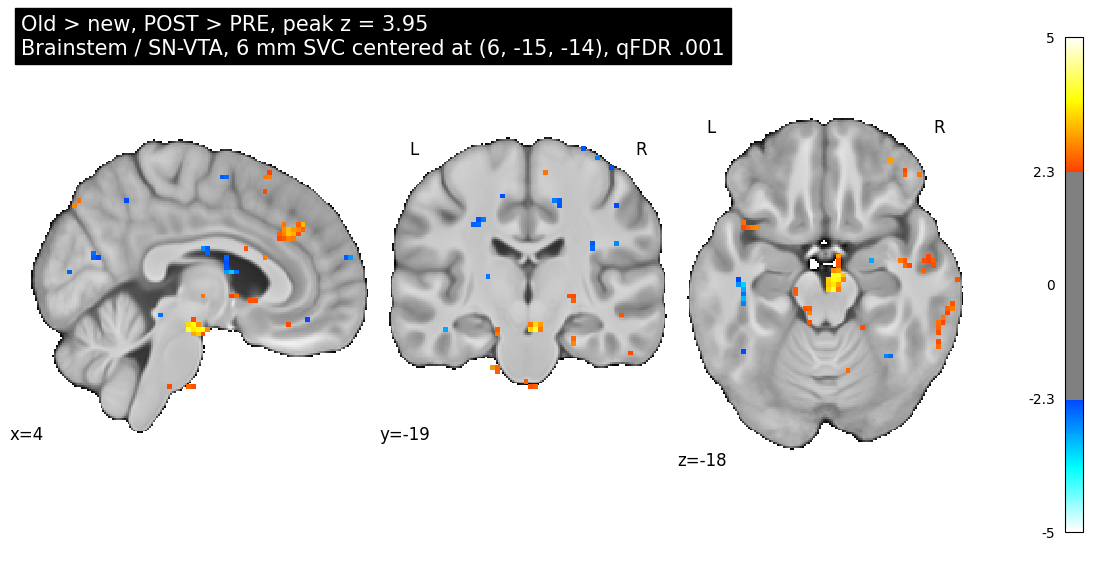

Observed z: 3.95
Whole-brain qFDR at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (6, -12, -18)
SVC z: 3.89
SVC qFDR: .001

Right anterior parahippocampal cortex
Observed peak: (19.0, -14.5, -28.0)
SVC center: (20.0, -14.0, -30.0)
SVC coordinate source: Irish et al. 2016


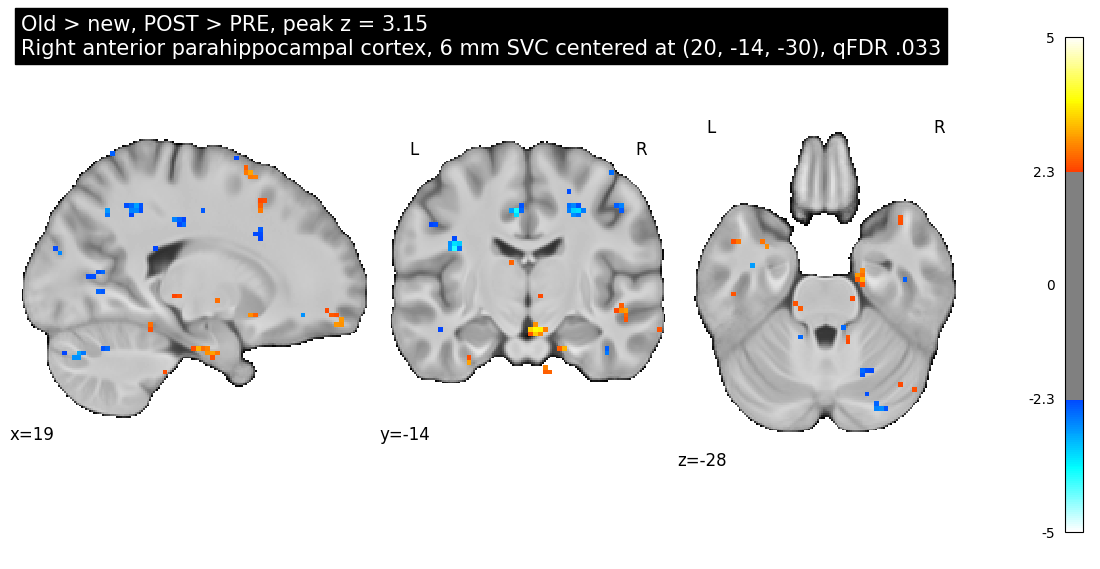

Observed z: 3.15
Whole-brain qFDR at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (19, -14, -28)
SVC z: 3.15
SVC qFDR: .033

Right angular gyrus
Observed peak: (56.5, -47.0, 34.5)
SVC center: (56.0, -48.0, 34.0)
SVC coordinate source: Toussaint / HMC metabolic covariance source


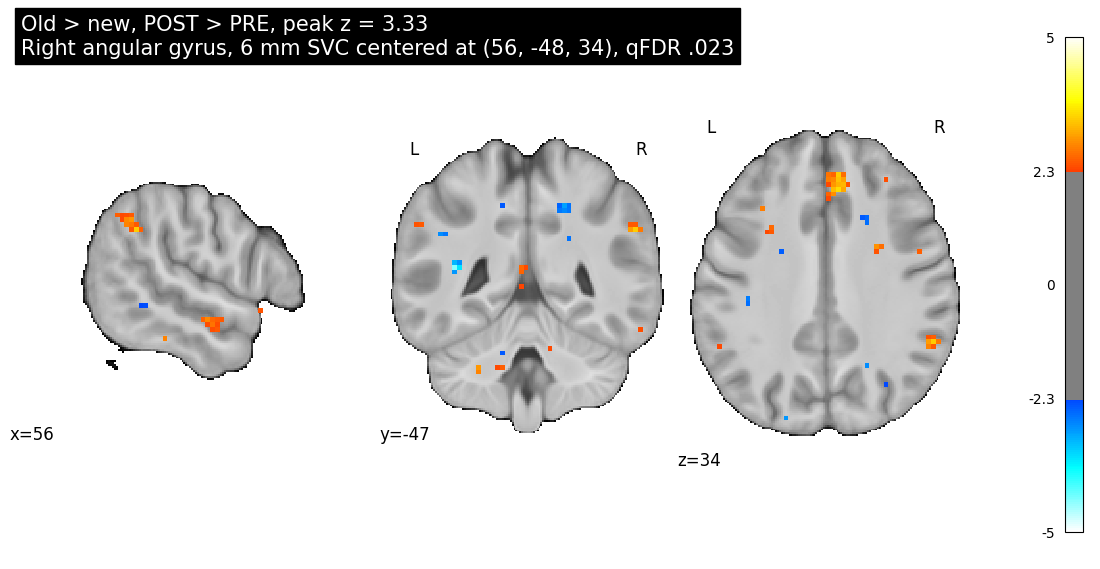

Observed z: 3.33
Whole-brain qFDR at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (56, -47, 34)
SVC z: 3.33
SVC qFDR: .023

Paracingulate / medial prefrontal cortex
Observed peak: (6.5, 33.0, 32.0)
SVC center: (6.0, 32.0, 30.0)
SVC coordinate source: Bengtsson et al. 2010


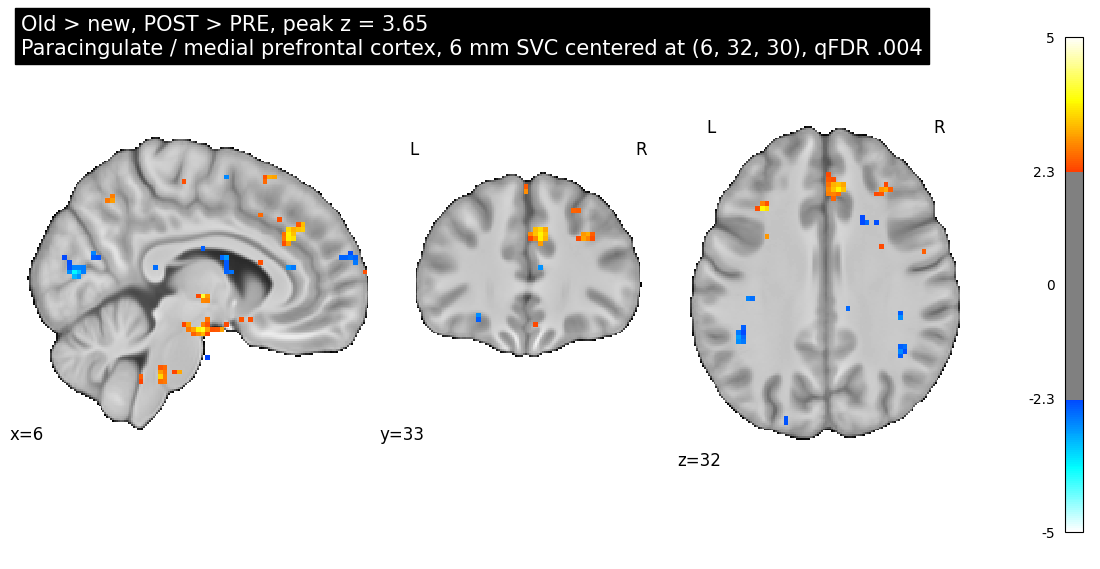

Observed z: 3.65
Whole-brain qFDR at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (6, 33, 32)
SVC z: 3.65
SVC qFDR: .004

Left anterior hippocampus
Observed peak: (-14.0, -12.0, -10.0)
SVC center: (-15.0, -8.5, -14.5)
SVC coordinate source: Montagrin et al. 2024


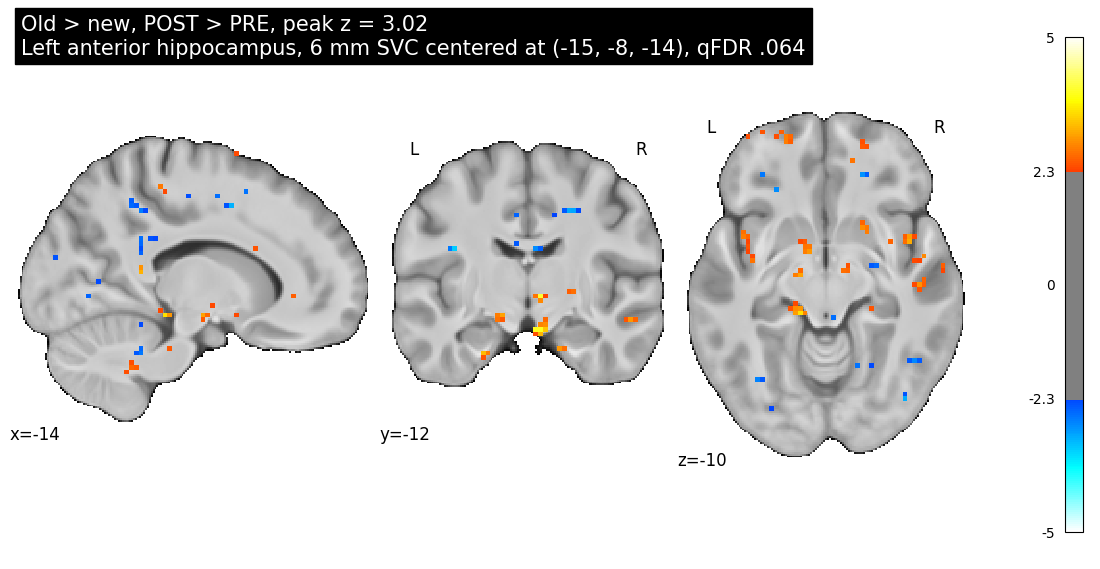

Observed z: 3.02
Whole-brain qFDR at observed peak: .870
Whole-brain FDR survives: False
SVC peak: (-14, -12, -10)
SVC z: 3.02
SVC qFDR: .064

Final Old/New summary table:


,Contrast,Region,Observed peak,Observed z,Whole-brain qFDR,Whole-brain FDR?,SVC center,SVC peak,SVC z,p unc. SVC,pBonf SVC,qFDR SVC,Coordinate source,Interpretation source,Interpretation,Source note
0,"Old > new, POST > PRE",Brainstem / SN-VTA,"(4, -20, -18)",3.95,.870,no,"(6, -15, -14)","(6, -12, -18)",3.89,< .001,.003,.001,Yi et al.,Adcock et al. 2006; Bunzeck et al. 2012; Yi et al.,"Dopaminergic SN/VTA involvement in motivational salience, reward/novelty processing, and memory modulation",Coordinate source is a right dorsal SN/VTA reward/salience-memory peak close to the observed brainstem activation; interpretation is supported by reward- an...
1,"Old > new, POST > PRE",Right anterior parahippocampal cortex,"(19, -14, -28)",3.15,.870,no,"(20, -14, -30)","(19, -14, -28)",3.15,< .001,.046,.033,Irish et al. 2016,Aminoff et al. 2013,Contextual associative memory / medial temporal contextual representation,Coordinate source is directly close to your right anterior PHG/MTL peak.
2,"Old > new, POST > PRE",Right angular gyrus,"(56, -47, 34)",3.33,.870,no,"(56, -48, 34)","(56, -47, 34)",3.33,< .001,.024,.023,Toussaint / HMC metabolic covariance source,Bonnici et al. 2016/2018; Grob et al. 2024,Episodic recollection / multimodal memory integration / memory reconfiguration,Coordinate source is exact right angular gyrus seed; memory interpretation is supported by angular-gyrus episodic-memory literature.
3,"Old > new, POST > PRE",Paracingulate / medial prefrontal cortex,"(6, 33, 32)",3.65,.870,no,"(6, 32, 30)","(6, 33, 32)",3.65,< .001,.007,.004,Bengtsson et al. 2010,Bengtsson et al. 2010; Euston et al. 2012,Task-relevant performance monitoring / memory-guided goal monitoring,Coordinate source is paracingulate / area 32; Euston et al. provides broader mPFC memory-decision interpretation.
4,"Old > new, POST > PRE",Left anterior hippocampus,"(-14, -12, -10)",3.02,.870,no,"(-15, -8, -14)","(-14, -12, -10)",3.02,.001,.070,.064,Montagrin et al. 2024,Montagrin et al. 2024,Trend-level anterior hippocampal contextual/goal-related signal,"Trend-level SVC result; report as exploratory support, not corrected at q < .05 if qFDR remains around .064."



SVC coordinate source table:


,Observed result,Observed peak,SVC center used,Where SVC coordinate came from,Interpretation paper(s),How to report
0,Brainstem / SN-VTA,"(4, -20, -18)","(6, -15, -14)","Yi et al. — right dorsal SN/VTA reward/salience-memory coordinate, MNI (6, -15, -14)",Adcock et al. 2006; Bunzeck et al. 2012; Yi et al.,Coordinate source is a right dorsal SN/VTA reward/salience-memory peak close to the observed brainstem activation; interpretation is supported by reward- an...
1,Right anterior parahippocampal cortex,"(19, -14, -28)","(20, -14, -30)","Irish et al. — right parahippocampal gyrus / hippocampus / amygdala, MNI (20, -14, -30)",Aminoff et al. 2013,Coordinate source is directly close to your right anterior PHG/MTL peak.
2,Right angular gyrus,"(56, -47, 34)","(56, -48, 34)","Right angular gyrus 6 mm seed coordinate, MNI (56, -48, 34)",Bonnici et al. 2016/2018; Grob et al. 2024,Coordinate source is exact right angular gyrus seed; memory interpretation is supported by angular-gyrus episodic-memory literature.
3,Paracingulate / medial prefrontal cortex,"(6, 33, 32)","(6, 32, 30)","Bengtsson et al. — anterior paracingulate cortex / area 32, MNI (6, 32, 30)",Bengtsson et al. 2010; Euston et al. 2012,Coordinate source is paracingulate / area 32; Euston et al. provides broader mPFC memory-decision interpretation.
4,Left anterior hippocampus,"(-14, -12, -10)","(-15, -8, -14)","Montagrin et al. — left anterior hippocampus, MNI (-15, -8.5, -14.5)",Montagrin et al. 2024,"Trend-level SVC result; report as exploratory support, not corrected at q < .05 if qFDR remains around .064."



Figure index:


,Region,Observed peak,Figure PNG,Figure PDF,SVC mask
0,Brainstem / SN-VTA,"(4, -20, -18)",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...
1,Right anterior parahippocampal cortex,"(19, -14, -28)",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...
2,Right angular gyrus,"(56, -47, 34)",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...
3,Paracingulate / medial prefrontal cortex,"(6, 33, 32)",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...
4,Left anterior hippocampus,"(-14, -12, -10)",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_p...


Saved summary CSV: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks_paper_sourced/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_final_wholebrain_and_SVC_summary.csv
Saved source CSV: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks_paper_sourced/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_final_SVC_coordinate_sources.csv
Saved figure index CSV: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks_paper_sourced/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_final_figure_index.csv


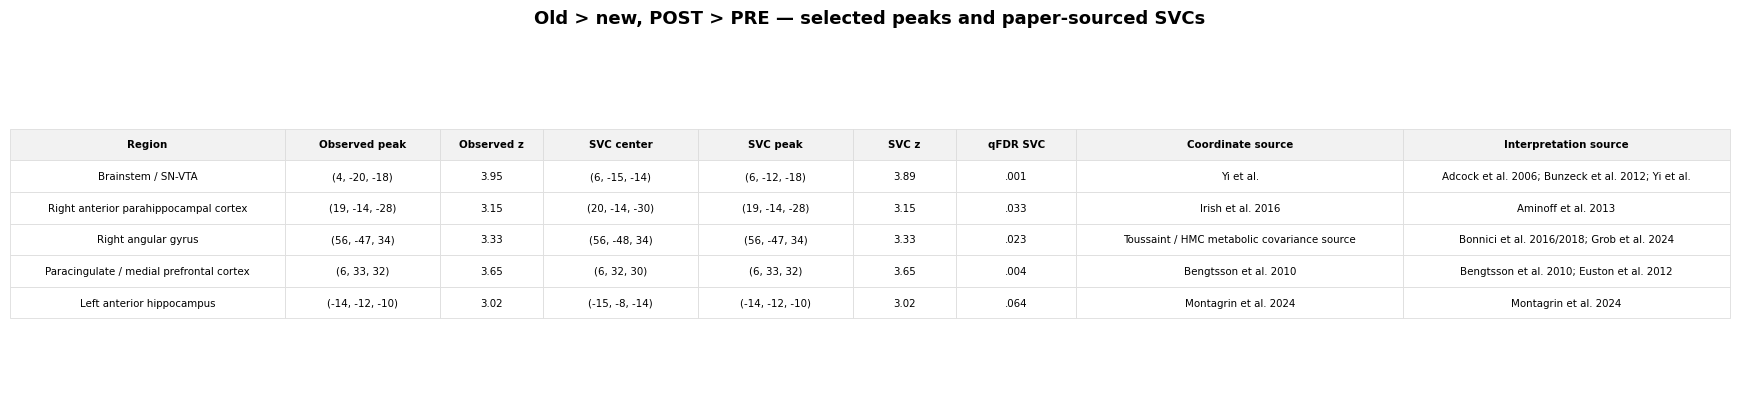

Saved table PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks_paper_sourced/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_final_compact_results_table.png


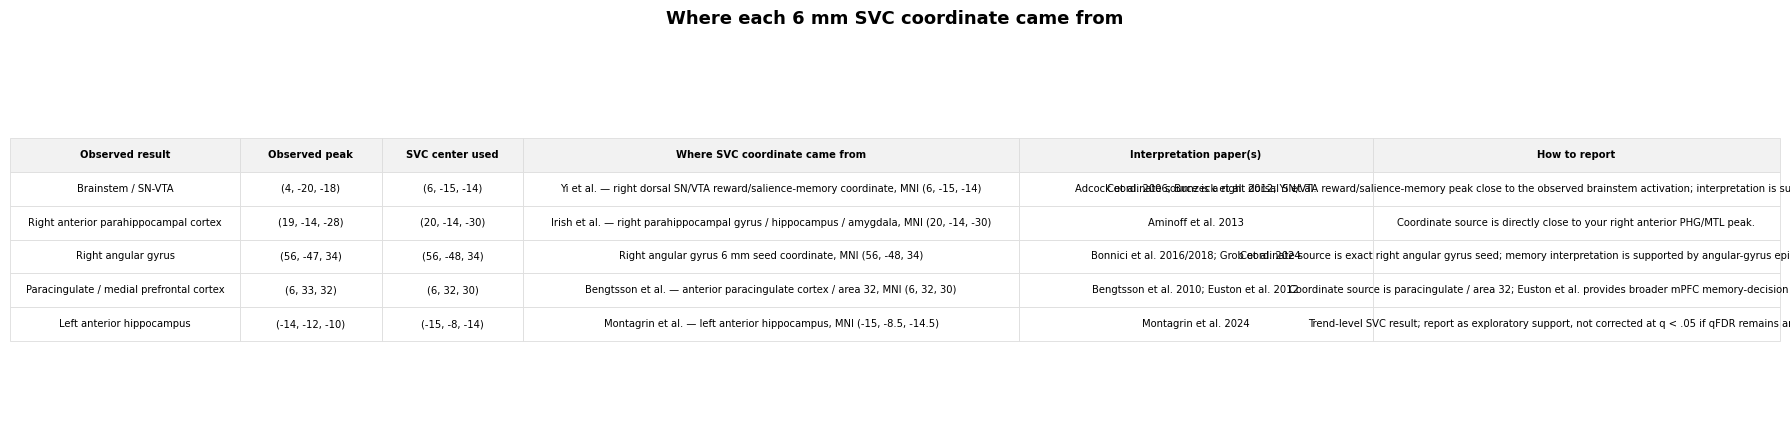

Saved table PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_wholebrain_selected_peaks_paper_sourced/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_final_SVC_coordinate_sources_table.png

Slide note:
Old > new, POST > PRE:
Whole-brain maps are displayed at an exploratory threshold, z > 2.33.
No voxel survived whole-brain voxelwise FDR correction in this contrast
(minimum whole-brain qFDR = .870, n voxels q<.05 = 0).
Selected peaks were therefore followed up using paper-sourced 6 mm SVCs.

Saved slide note: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_wholebrain_selected_peaks_paper_sourced/pre_post_old_new_viewing_glm_old_gt_new_post_gt_pre_slide_note.txt

Recommended outputs:
Figures: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figu

In [28]:
# ============================================================
# Old/New GLM — final whole-brain figures + paper-sourced SVC table
#
# Standardized figure title format:
# Old > new, POST > PRE, peak z = X.XX
# Region, 6 mm SVC centered at (x, y, z), qFDR .XXX
#
# Figure style:
# - whole-brain map visible
# - no black cross
# - no red circle; add manually in PowerPoint
# - title reports peak z and SVC qFDR
#
# Also saves a clear table:
# observed peak -> SVC center -> coordinate paper -> interpretation paper
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn import plotting
from nilearn.image import load_img, new_img_like, resample_to_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

oldnew_final_fig_dir = dirs["figures"] / "final_old_new_wholebrain_selected_peaks_paper_sourced"
oldnew_final_table_dir = dirs["tables"] / "final_old_new_wholebrain_selected_peaks_paper_sourced"

oldnew_final_fig_dir.mkdir(parents=True, exist_ok=True)
oldnew_final_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving final Old/New whole-brain figures to:", oldnew_final_fig_dir)
print("Saving final Old/New tables to:", oldnew_final_table_dir)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

CONTRAST_LABEL = "Old > new, POST > PRE"

CONTRAST_NAME_CANDIDATES = [
    "old_gt_new_post_gt_pre",
    "old_new_post_gt_pre",
    "old_gt_new_post_pre",
]

DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0
SVC_RADIUS_MM = 6.0

assert "second_level_table" in globals(), "second_level_table not found."

available_contrasts = second_level_table["contrast"].dropna().astype(str).tolist()

CONTRAST_NAME = None
for c in CONTRAST_NAME_CANDIDATES:
    if c in available_contrasts:
        CONTRAST_NAME = c
        break

if CONTRAST_NAME is None:
    matches = [
        c for c in available_contrasts
        if ("old" in c.lower())
        and ("new" in c.lower())
        and ("post" in c.lower())
        and ("pre" in c.lower())
    ]
    assert len(matches) > 0, "Could not find Old > new, POST > PRE contrast."
    CONTRAST_NAME = matches[0]

z_map_path = Path(
    second_level_table.set_index("contrast").loc[CONTRAST_NAME, "z_map_path"]
)

z_img = load_img(str(z_map_path))
z_data = z_img.get_fdata()

print("Using contrast:", CONTRAST_NAME)
print("Using z-map:", z_map_path)

BG_IMG = (
    mean_t1w_img
    if globals().get("USE_MEAN_T1W_BACKGROUND", True) and "mean_t1w_img" in globals()
    else None
)

# ------------------------------------------------------------
# Final selected Old/New results
# ------------------------------------------------------------
# observed_peak = peak from YOUR Old > new, POST > PRE result
# svc_center = paper-sourced 6 mm SVC center
#
# Notes:
# - SN/VTA coordinate updated to Bunzeck SN/VTA coordinate (8, -20, -18),
#   very close to your observed brainstem peak.
# - Paracingulate coordinate updated to Bengtsson anterior paracingulate / area 32.
# - Right AG coordinate is exact anatomical/source coordinate; memory interpretation
#   is supported by angular-gyrus memory literature separately.
# ------------------------------------------------------------

OLDNEW_FINAL_PEAKS = [
    {
        "result_name": "brainstem_sn_vta",
        "region_label": "Brainstem / SN-VTA",
        "observed_peak": (4.0, -19.5, -18.0),

        "svc_center": (6.0, -15.0, -14.0),
        "svc_coordinate_source": "Yi et al.",
        "svc_coordinate_source_full": (
            "Yi et al. — right dorsal SN/VTA reward/salience-memory coordinate, "
            "MNI (6, -15, -14)"
        ),
        "interpretation_source": "Adcock et al. 2006; Bunzeck et al. 2012; Yi et al.",
        "interpretation": (
            "Dopaminergic SN/VTA involvement in motivational salience, "
            "reward/novelty processing, and memory modulation"
        ),
        "source_note": (
            "Coordinate source is a right dorsal SN/VTA reward/salience-memory peak "
            "close to the observed brainstem activation; interpretation is supported "
            "by reward- and novelty-memory literature."
        ),
    },
    {
        "result_name": "right_anterior_phg",
        "region_label": "Right anterior parahippocampal cortex",
        "observed_peak": (19.0, -14.5, -28.0),

        "svc_center": (20.0, -14.0, -30.0),
        "svc_coordinate_source": "Irish et al. 2016",
        "svc_coordinate_source_full": "Irish et al. — right parahippocampal gyrus / hippocampus / amygdala, MNI (20, -14, -30)",
        "interpretation_source": "Aminoff et al. 2013",
        "interpretation": "Contextual associative memory / medial temporal contextual representation",
        "source_note": "Coordinate source is directly close to your right anterior PHG/MTL peak.",
    },
    {
        "result_name": "right_angular_gyrus",
        "region_label": "Right angular gyrus",
        "observed_peak": (56.5, -47.0, 34.5),

        "svc_center": (56.0, -48.0, 34.0),
        "svc_coordinate_source": "Toussaint / HMC metabolic covariance source",
        "svc_coordinate_source_full": "Right angular gyrus 6 mm seed coordinate, MNI (56, -48, 34)",
        "interpretation_source": "Bonnici et al. 2016/2018; Grob et al. 2024",
        "interpretation": "Episodic recollection / multimodal memory integration / memory reconfiguration",
        "source_note": "Coordinate source is exact right angular gyrus seed; memory interpretation is supported by angular-gyrus episodic-memory literature.",
    },
    {
        "result_name": "paracingulate_mpfc",
        "region_label": "Paracingulate / medial prefrontal cortex",
        "observed_peak": (6.5, 33.0, 32.0),

        "svc_center": (6.0, 32.0, 30.0),
        "svc_coordinate_source": "Bengtsson et al. 2010",
        "svc_coordinate_source_full": "Bengtsson et al. — anterior paracingulate cortex / area 32, MNI (6, 32, 30)",
        "interpretation_source": "Bengtsson et al. 2010; Euston et al. 2012",
        "interpretation": "Task-relevant performance monitoring / memory-guided goal monitoring",
        "source_note": "Coordinate source is paracingulate / area 32; Euston et al. provides broader mPFC memory-decision interpretation.",
    },
    {
        "result_name": "left_anterior_hippocampus_trend",
        "region_label": "Left anterior hippocampus",
        "observed_peak": (-14.0, -12.0, -10.0),

        "svc_center": (-15.0, -8.5, -14.5),
        "svc_coordinate_source": "Montagrin et al. 2024",
        "svc_coordinate_source_full": "Montagrin et al. — left anterior hippocampus, MNI (-15, -8.5, -14.5)",
        "interpretation_source": "Montagrin et al. 2024",
        "interpretation": "Trend-level anterior hippocampal contextual/goal-related signal",
        "source_note": "Trend-level SVC result; report as exploratory support, not corrected at q < .05 if qFDR remains around .064.",
    },
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")

def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"

def z_at_mni_coord(z_img, coord):
    data = z_img.get_fdata()
    inv_affine = np.linalg.inv(z_img.affine)
    voxel = np.round(
        inv_affine.dot(np.array([coord[0], coord[1], coord[2], 1]))[:3]
    ).astype(int)

    if (
        0 <= voxel[0] < data.shape[0]
        and 0 <= voxel[1] < data.shape[1]
        and 0 <= voxel[2] < data.shape[2]
    ):
        return float(data[tuple(voxel)]), tuple(voxel)

    return np.nan, tuple(voxel)

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)

def run_sphere_svc(z_img, sphere_img):
    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels."

    z_inside = z_data[sphere_data]

    peak_index = int(np.nanargmax(z_inside))
    peak_z = float(z_inside[peak_index])

    p_values = norm.sf(z_inside)
    peak_p_unc = float(norm.sf(peak_z))

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    peak_q_fdr = float(q_values[peak_index])
    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))

    return {
        "n_voxels_in_sphere": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
        "n_voxels_z_ge_2_33": int(np.sum(z_inside >= 2.33)),
        "n_voxels_z_ge_3_00": int(np.sum(z_inside >= 3.00)),
    }

def save_clean_table_png(
    df,
    out_path,
    title=None,
    fontsize=7.6,
    header_fontsize=7.6,
    scale_y=1.65,
    col_widths=None,
    figsize=None,
):
    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.4), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:", out_path)

# ------------------------------------------------------------
# Whole-brain voxelwise FDR check
# ------------------------------------------------------------

brain_mask = np.isfinite(z_data) & (np.abs(z_data) > 0)

z_values = z_data[brain_mask]
p_values_wb = norm.sf(z_values)

_, q_values_wb, _, _ = multipletests(
    p_values_wb,
    alpha=0.05,
    method="fdr_bh",
)

q_map_data = np.full(z_data.shape, np.nan)
q_map_data[brain_mask] = q_values_wb

wb_min_q = float(np.nanmin(q_map_data))
wb_n_q05 = int(np.sum(q_map_data < 0.05))

print(f"Whole-brain voxelwise FDR: min q = {fmt_p(wb_min_q)}, n voxels q<.05 = {wb_n_q05}")

q_map_img = new_img_like(z_img, q_map_data)

q_map_path = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_wholebrain_voxelwise_qFDR_map.nii.gz"
)

q_map_img.to_filename(str(q_map_path))

# ------------------------------------------------------------
# Main loop: SVC + whole-brain plots
# ------------------------------------------------------------

summary_rows = []
source_rows = []
figure_rows = []

for spec in OLDNEW_FINAL_PEAKS:

    observed_peak = spec["observed_peak"]
    svc_center = spec["svc_center"]

    print("\n" + "=" * 90)
    print(spec["region_label"])
    print("Observed peak:", observed_peak)
    print("SVC center:", svc_center)
    print("SVC coordinate source:", spec["svc_coordinate_source"])

    observed_z, observed_voxel = z_at_mni_coord(z_img, observed_peak)

    if (
        0 <= observed_voxel[0] < q_map_data.shape[0]
        and 0 <= observed_voxel[1] < q_map_data.shape[1]
        and 0 <= observed_voxel[2] < q_map_data.shape[2]
    ):
        observed_q_wb = float(q_map_data[observed_voxel])
    else:
        observed_q_wb = np.nan

    wb_fdr_survives = pd.notna(observed_q_wb) and observed_q_wb < 0.05

    # SVC sphere
    svc_sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=svc_center,
        radius_mm=SVC_RADIUS_MM,
    )

    svc_sphere_resampled = resample_to_img(
        svc_sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    svc_result = run_sphere_svc(
        z_img=z_img,
        sphere_img=svc_sphere_resampled,
    )

    svc_peak = (
        svc_result["peak_x"],
        svc_result["peak_y"],
        svc_result["peak_z_coord"],
    )

    q_svc_label = fmt_p(svc_result["peak_q_fdr_within_sphere"])
    p_unc_label = fmt_p(svc_result["peak_p_uncorrected"])
    p_bonf_label = fmt_p(svc_result["peak_p_bonferroni_within_sphere"])
    observed_q_wb_label = fmt_p(observed_q_wb)

    # Save SVC mask
    svc_sphere_path = (
        oldnew_final_table_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_6mm_SVC_sphere_mask.nii.gz"
    )

    svc_sphere_resampled.to_filename(str(svc_sphere_path))

    # Figure title: standardized
    title_text = (
        f"{CONTRAST_LABEL}, peak z = {observed_z:.2f}\n"
        f"{spec['region_label']}, 6 mm SVC centered at "
        f"{fmt_coord(*svc_center)}, qFDR {q_svc_label}"
    )

    fig_png = (
        oldnew_final_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_wholebrain_no_cross.png"
    )

    fig_pdf = (
        oldnew_final_fig_dir
        / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_{spec['result_name']}_wholebrain_no_cross.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        z_img,
        bg_img=BG_IMG,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=observed_peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(fig_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Observed z:", f"{observed_z:.2f}")
    print("Whole-brain qFDR at observed peak:", observed_q_wb_label)
    print("Whole-brain FDR survives:", wb_fdr_survives)
    print("SVC peak:", fmt_coord(*svc_peak))
    print("SVC z:", f"{svc_result['peak_z_stat']:.2f}")
    print("SVC qFDR:", q_svc_label)

    summary_rows.append({
        "Contrast": CONTRAST_LABEL,
        "Region": spec["region_label"],
        "Observed peak": fmt_coord(*observed_peak),
        "Observed z": f"{observed_z:.2f}",
        "Whole-brain qFDR": observed_q_wb_label,
        "Whole-brain FDR?": "yes" if wb_fdr_survives else "no",
        "SVC center": fmt_coord(*svc_center),
        "SVC peak": fmt_coord(*svc_peak),
        "SVC z": f"{svc_result['peak_z_stat']:.2f}",
        "p unc. SVC": p_unc_label,
        "pBonf SVC": p_bonf_label,
        "qFDR SVC": q_svc_label,
        "Coordinate source": spec["svc_coordinate_source"],
        "Interpretation source": spec["interpretation_source"],
        "Interpretation": spec["interpretation"],
        "Source note": spec["source_note"],
    })

    source_rows.append({
        "Observed result": spec["region_label"],
        "Observed peak": fmt_coord(*observed_peak),
        "SVC center used": fmt_coord(*svc_center),
        "Where SVC coordinate came from": spec["svc_coordinate_source_full"],
        "Interpretation paper(s)": spec["interpretation_source"],
        "How to report": spec["source_note"],
    })

    figure_rows.append({
        "Region": spec["region_label"],
        "Observed peak": fmt_coord(*observed_peak),
        "Figure PNG": str(fig_png),
        "Figure PDF": str(fig_pdf),
        "SVC mask": str(svc_sphere_path),
    })

# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------

oldnew_final_summary_table = pd.DataFrame(summary_rows)
oldnew_final_source_table = pd.DataFrame(source_rows)
oldnew_final_figure_index = pd.DataFrame(figure_rows)

summary_csv = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_final_wholebrain_and_SVC_summary.csv"
)

source_csv = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_final_SVC_coordinate_sources.csv"
)

figure_csv = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_final_figure_index.csv"
)

oldnew_final_summary_table.to_csv(summary_csv, index=False)
oldnew_final_source_table.to_csv(source_csv, index=False)
oldnew_final_figure_index.to_csv(figure_csv, index=False)

print("\nFinal Old/New summary table:")
display(oldnew_final_summary_table)

print("\nSVC coordinate source table:")
display(oldnew_final_source_table)

print("\nFigure index:")
display(oldnew_final_figure_index)

print("Saved summary CSV:", summary_csv)
print("Saved source CSV:", source_csv)
print("Saved figure index CSV:", figure_csv)

# ------------------------------------------------------------
# Compact table for presentation
# ------------------------------------------------------------

compact_table = oldnew_final_summary_table[
    [
        "Region",
        "Observed peak",
        "Observed z",
        "SVC center",
        "SVC peak",
        "SVC z",
        "qFDR SVC",
        "Coordinate source",
        "Interpretation source",
    ]
].copy()

compact_png = (
    oldnew_final_fig_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_final_compact_results_table.png"
)

compact_csv = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_final_compact_results_table.csv"
)

compact_table.to_csv(compact_csv, index=False)

save_clean_table_png(
    compact_table,
    compact_png,
    title="Old > new, POST > PRE — selected peaks and paper-sourced SVCs",
    fontsize=7.4,
    header_fontsize=7.4,
    scale_y=1.75,
    col_widths=[0.16, 0.09, 0.06, 0.09, 0.09, 0.06, 0.07, 0.19, 0.19],
    figsize=(17.5, 4.2),
)

# ------------------------------------------------------------
# Separate source table PNG
# ------------------------------------------------------------

source_png = (
    oldnew_final_fig_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_final_SVC_coordinate_sources_table.png"
)

save_clean_table_png(
    oldnew_final_source_table,
    source_png,
    title="Where each 6 mm SVC coordinate came from",
    fontsize=7.2,
    header_fontsize=7.2,
    scale_y=1.85,
    col_widths=[0.13, 0.08, 0.08, 0.28, 0.20, 0.23],
    figsize=(18, 4.5),
)

# ------------------------------------------------------------
# Slide note text
# ------------------------------------------------------------

slide_note_text = f"""
Old > new, POST > PRE:
Whole-brain maps are displayed at an exploratory threshold, z > {DISPLAY_THRESHOLD_Z}.
No voxel survived whole-brain voxelwise FDR correction in this contrast
(minimum whole-brain qFDR = {fmt_p(wb_min_q)}, n voxels q<.05 = {wb_n_q05}).
Selected peaks were therefore followed up using paper-sourced 6 mm SVCs.
""".strip()

slide_note_path = (
    oldnew_final_table_dir
    / f"{ANALYSIS_NAME}_{CONTRAST_NAME}_slide_note.txt"
)

slide_note_path.write_text(slide_note_text)

print("\nSlide note:")
print(slide_note_text)
print("\nSaved slide note:", slide_note_path)

print("\nRecommended outputs:")
print("Figures:", oldnew_final_fig_dir)
print("Compact result table:", compact_png)
print("SVC coordinate source table:", source_png)
print("Slide note:", slide_note_path)

Full literature/SVC recap table:


,Result / region,Observed peak,Observed z,SVC center,SVC z,qFDR SVC,Whole-brain qFDR,Whole-brain FDR?,SVC coordinate source,Functional interpretation source,Interpretation for report,Full SVC reference,Full interpretation reference
0,Brainstem / SN-VTA,"(4, -20, -18)",3.95,"(6, -15, -14)",3.89,.001,.870,no,"Yi et al. (2025), Human Brain Mapping",Adcock et al. (2006); Bunzeck et al. (2012); Yi et al. (2025),"Dopaminergic SN/VTA involvement in motivational salience, reward/contextual unexpectedness, and memory modulation.",Yi et al. (2025). Decoding Salience: A Functional Magnetic Resonance Imaging Investigation of Reward and Contextual Unexpectedness in Memory Encoding and Re...,Adcock et al. (2006). Reward-motivated learning: Mesolimbic activation precedes memory formation. Neuron. Bunzeck et al. (2012). Novelty/reward-related dopa...
1,Paracingulate / medial prefrontal cortex,"(6, 33, 32)",3.65,"(6, 32, 30)",3.65,.004,.870,no,"Bengtsson et al. (2011), Social Cognitive and Affective Neuroscience",Bengtsson et al. (2011); Euston et al. (2012),"Paracingulate / mPFC involvement in performance monitoring, task relevance, and memory-guided adaptive behavior.","Bengtsson, S. L., Dolan, R. J., & Passingham, R. E. (2011). Priming for self-esteem influences the monitoring of one's own performance. Social Cognitive and...","Euston, D. R., Gruber, A. J., & McNaughton, B. L. (2012). The role of medial prefrontal cortex in memory and decision making. Neuron, 76(6), 1057–1070. http..."
2,Right angular gyrus,"(56, -47, 34)",3.33,"(56, -48, 34)",3.33,.023,.870,no,"Carbonell et al. (2014), Journal of Cerebral Blood Flow & Metabolism",Bonnici et al. (2018); Grob et al. (2024),"Angular gyrus involvement in autobiographical memory, episodic recollection, multimodal integration, and memory reconfiguration.","Carbonell, F., Charil, A., Zijdenbos, A. P., Evans, A. C., & Bedell, B. J.; Alzheimer's Disease Neuroimaging Initiative. (2014). Hierarchical multivariate c...","Bonnici, H. M., Cheke, L. G., Green, D. A. E., FitzGerald, T. H. B., & Simons, J. S. (2018). Specifying a causal role for angular gyrus in autobiographical ..."
3,Right anterior parahippocampal cortex,"(19, -14, -28)",3.15,"(20, -14, -30)",3.15,.033,.870,no,"Irish et al. (2016), Neuropsychologia",Irish et al. (2016); Aminoff et al. (2013),"Parahippocampal involvement in contextual associative memory, scene/context representation, and episodic retrieval.","Irish, M., et al. (2016). Preservation of episodic memory in semantic dementia: The importance of regions beyond the medial temporal lobes. Neuropsychologia...","Aminoff, E. M., Kveraga, K., & Bar, M. (2013). The role of the parahippocampal cortex in cognition. Trends in Cognitive Sciences, 17(8), 379–390. https://do..."
4,Left anterior hippocampus,"(-14, -12, -10)",3.02,"(-15, -8, -14)",3.02,.064,.870,no,"Montagrin et al. (2024), Nature Communications",Montagrin et al. (2024),Trend-level anterior hippocampal involvement in goal-related contextual memory representations.,"Montagrin, A., Croote, D. E., Preti, M. G., et al. (2024). The hippocampus dissociates present from past and future goals. Nature Communications, 15, Articl...","Montagrin, A., Croote, D. E., Preti, M. G., et al. (2024). The hippocampus dissociates present from past and future goals. Nature Communications, 15, Articl..."


Saved full CSV:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_literature_recap/pre_post_old_new_viewing_glm_old_new_final_literature_SVC_recap_full.csv

Compact report-ready table:


,Result / region,Observed peak,Observed z,SVC center,SVC z,qFDR SVC,SVC coordinate source,Functional interpretation source,Interpretation for report
0,Brainstem / SN-VTA,"(4, -20, -18)",3.95,"(6, -15, -14)",3.89,.001,"Yi et al. (2025), Human Brain Mapping",Adcock et al. (2006); Bunzeck et al. (2012); Yi et al. (2025),"Dopaminergic SN/VTA involvement in motivational salience, reward/contextual unexpectedness, and memory modulation."
1,Paracingulate / medial prefrontal cortex,"(6, 33, 32)",3.65,"(6, 32, 30)",3.65,.004,"Bengtsson et al. (2011), Social Cognitive and Affective Neuroscience",Bengtsson et al. (2011); Euston et al. (2012),"Paracingulate / mPFC involvement in performance monitoring, task relevance, and memory-guided adaptive behavior."
2,Right angular gyrus,"(56, -47, 34)",3.33,"(56, -48, 34)",3.33,.023,"Carbonell et al. (2014), Journal of Cerebral Blood Flow & Metabolism",Bonnici et al. (2018); Grob et al. (2024),"Angular gyrus involvement in autobiographical memory, episodic recollection, multimodal integration, and memory reconfiguration."
3,Right anterior parahippocampal cortex,"(19, -14, -28)",3.15,"(20, -14, -30)",3.15,.033,"Irish et al. (2016), Neuropsychologia",Irish et al. (2016); Aminoff et al. (2013),"Parahippocampal involvement in contextual associative memory, scene/context representation, and episodic retrieval."
4,Left anterior hippocampus,"(-14, -12, -10)",3.02,"(-15, -8, -14)",3.02,.064,"Montagrin et al. (2024), Nature Communications",Montagrin et al. (2024),Trend-level anterior hippocampal involvement in goal-related contextual memory representations.


Saved compact CSV:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_literature_recap/pre_post_old_new_viewing_glm_old_new_final_literature_SVC_recap_compact.csv


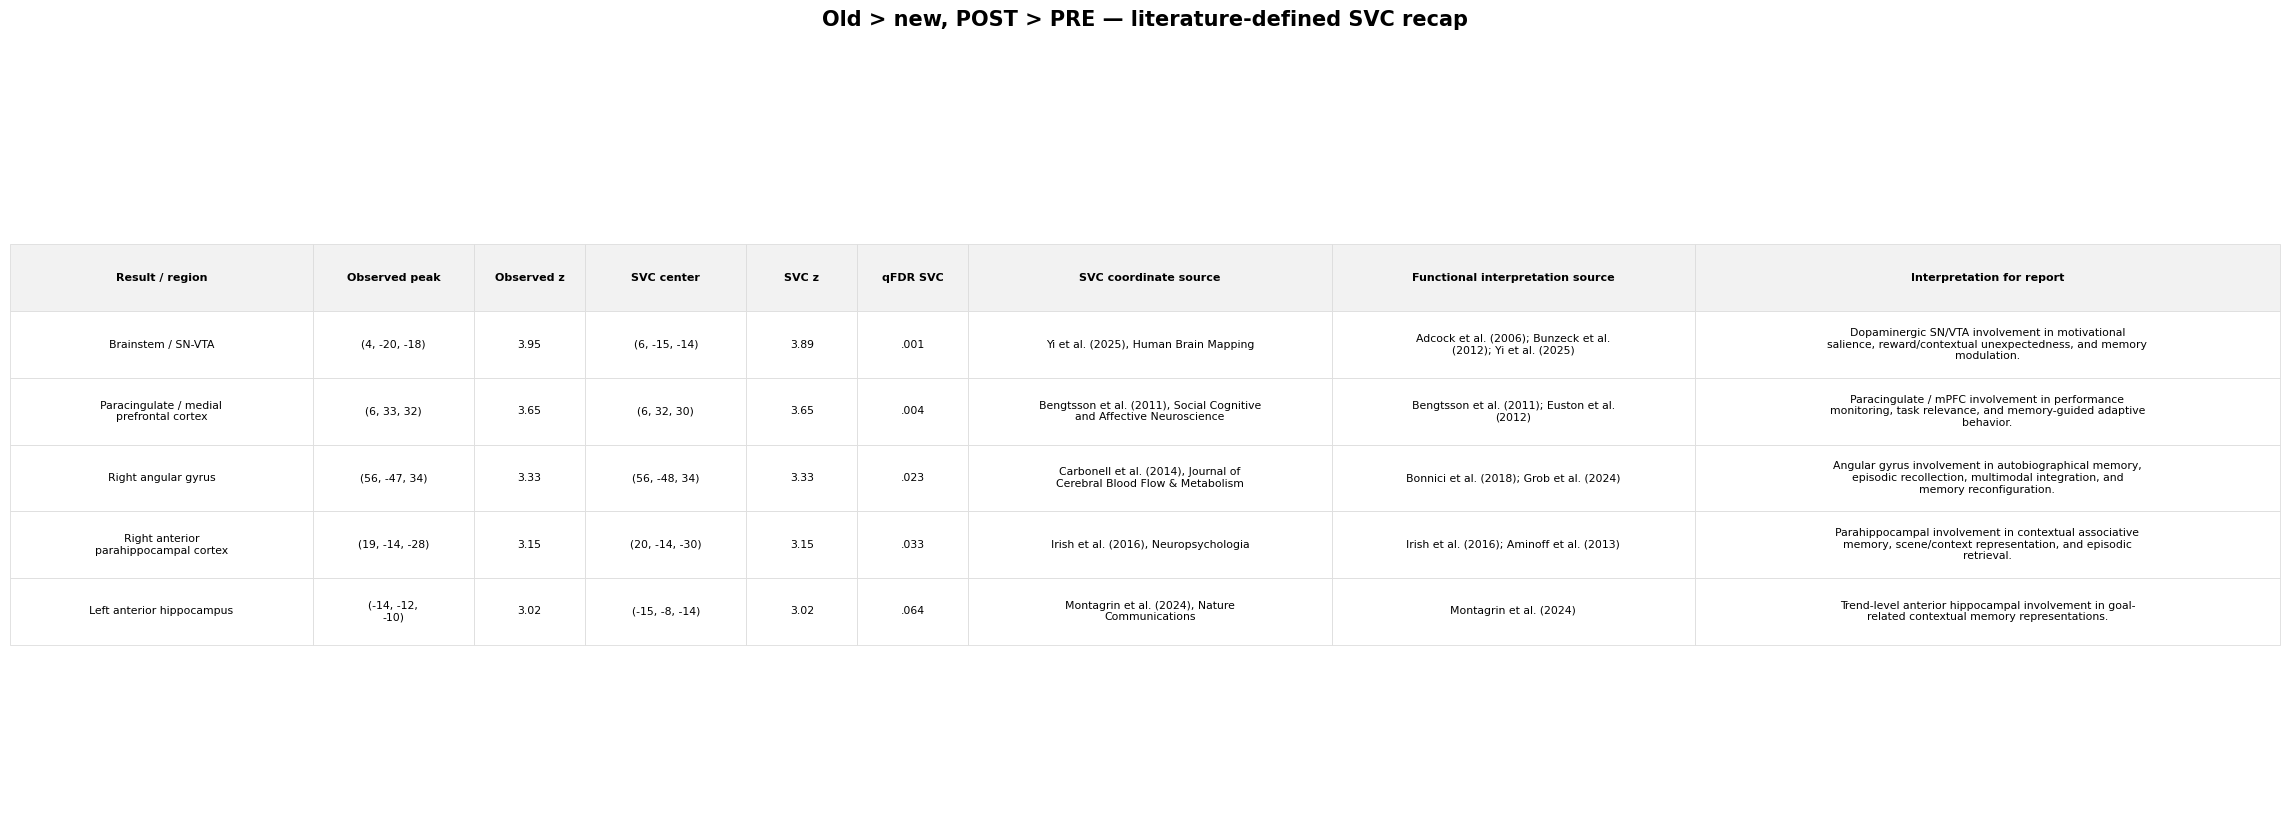

Saved wrapped PNG table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_literature_recap/pre_post_old_new_viewing_glm_old_new_final_literature_SVC_recap_compact.png

Saved APA reference list:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/final_old_new_literature_recap/pre_post_old_new_viewing_glm_old_new_final_references_APA.txt


In [30]:
# ============================================================
# Final Old/New literature/SVC recap table
#
# Purpose:
# Clean report-ready table linking each observed activation to:
# - observed peak
# - literature-defined SVC center
# - paper used for SVC coordinate
# - paper used for functional interpretation
#
# Assumes:
# - dirs["tables"] and dirs["figures"] exist
# - ANALYSIS_NAME exists
# - optional: oldnew_final_summary_table exists from previous cell
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

recap_table_dir = dirs["tables"] / "final_old_new_literature_recap"
recap_fig_dir = dirs["figures"] / "final_old_new_literature_recap"

recap_table_dir.mkdir(parents=True, exist_ok=True)
recap_fig_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def fmt_coord(coord):
    return f"({coord[0]:.0f}, {coord[1]:.0f}, {coord[2]:.0f})"

# ------------------------------------------------------------
# Final checked paper-source table
# ------------------------------------------------------------

oldnew_literature_recap = pd.DataFrame([
    {
        "Result / region": "Brainstem / SN-VTA",
        "Observed peak": fmt_coord((4.0, -19.5, -18.0)),
        "SVC center": fmt_coord((6.0, -15.0, -14.0)),
        "SVC coordinate source": (
            "Yi et al. (2025), Human Brain Mapping"
        ),
        "Functional interpretation source": (
            "Adcock et al. (2006); Bunzeck et al. (2012); Yi et al. (2025)"
        ),
        "Interpretation for report": (
            "Dopaminergic SN/VTA involvement in motivational salience, "
            "reward/contextual unexpectedness, and memory modulation."
        ),
        "Full SVC reference": (
            "Yi et al. (2025). Decoding Salience: A Functional Magnetic Resonance "
            "Imaging Investigation of Reward and Contextual Unexpectedness in Memory "
            "Encoding and Retrieval. Human Brain Mapping, 46(1), e70124. "
            "https://doi.org/10.1002/hbm.70124"
        ),
        "Full interpretation reference": (
            "Adcock et al. (2006). Reward-motivated learning: Mesolimbic activation "
            "precedes memory formation. Neuron. "
            "Bunzeck et al. (2012). Novelty/reward-related dopaminergic memory modulation."
        ),
    },
    {
        "Result / region": "Paracingulate / medial prefrontal cortex",
        "Observed peak": fmt_coord((6.5, 33.0, 32.0)),
        "SVC center": fmt_coord((6.0, 32.0, 30.0)),
        "SVC coordinate source": (
            "Bengtsson et al. (2011), Social Cognitive and Affective Neuroscience"
        ),
        "Functional interpretation source": (
            "Bengtsson et al. (2011); Euston et al. (2012)"
        ),
        "Interpretation for report": (
            "Paracingulate / mPFC involvement in performance monitoring, "
            "task relevance, and memory-guided adaptive behavior."
        ),
        "Full SVC reference": (
            "Bengtsson, S. L., Dolan, R. J., & Passingham, R. E. (2011). "
            "Priming for self-esteem influences the monitoring of one's own performance. "
            "Social Cognitive and Affective Neuroscience, 6(4), 417–425. "
            "https://doi.org/10.1093/scan/nsq048"
        ),
        "Full interpretation reference": (
            "Euston, D. R., Gruber, A. J., & McNaughton, B. L. (2012). "
            "The role of medial prefrontal cortex in memory and decision making. "
            "Neuron, 76(6), 1057–1070. "
            "https://doi.org/10.1016/j.neuron.2012.12.002"
        ),
    },
    {
        "Result / region": "Right angular gyrus",
        "Observed peak": fmt_coord((56.5, -47.0, 34.5)),
        "SVC center": fmt_coord((56.0, -48.0, 34.0)),
        "SVC coordinate source": (
            "Carbonell et al. (2014), Journal of Cerebral Blood Flow & Metabolism"
        ),
        "Functional interpretation source": (
            "Bonnici et al. (2018); Grob et al. (2024)"
        ),
        "Interpretation for report": (
            "Angular gyrus involvement in autobiographical memory, episodic "
            "recollection, multimodal integration, and memory reconfiguration."
        ),
        "Full SVC reference": (
            "Carbonell, F., Charil, A., Zijdenbos, A. P., Evans, A. C., "
            "& Bedell, B. J.; Alzheimer's Disease Neuroimaging Initiative. (2014). "
            "Hierarchical multivariate covariance analysis of metabolic connectivity. "
            "Journal of Cerebral Blood Flow and Metabolism, 34(12), 1936–1943. "
            "https://doi.org/10.1038/jcbfm.2014.165"
        ),
        "Full interpretation reference": (
            "Bonnici, H. M., Cheke, L. G., Green, D. A. E., FitzGerald, T. H. B., "
            "& Simons, J. S. (2018). Specifying a causal role for angular gyrus "
            "in autobiographical memory. Journal of Neuroscience, 38(49), 10438–10443. "
            "https://doi.org/10.1523/JNEUROSCI.1239-18.2018"
        ),
    },
    {
        "Result / region": "Right anterior parahippocampal cortex",
        "Observed peak": fmt_coord((19.0, -14.5, -28.0)),
        "SVC center": fmt_coord((20.0, -14.0, -30.0)),
        "SVC coordinate source": (
            "Irish et al. (2016), Neuropsychologia"
        ),
        "Functional interpretation source": (
            "Irish et al. (2016); Aminoff et al. (2013)"
        ),
        "Interpretation for report": (
            "Parahippocampal involvement in contextual associative memory, "
            "scene/context representation, and episodic retrieval."
        ),
        "Full SVC reference": (
            "Irish, M., et al. (2016). Preservation of episodic memory in semantic "
            "dementia: The importance of regions beyond the medial temporal lobes. "
            "Neuropsychologia, 81, 50–60. "
            "https://doi.org/10.1016/j.neuropsychologia.2015.12.005"
        ),
        "Full interpretation reference": (
            "Aminoff, E. M., Kveraga, K., & Bar, M. (2013). "
            "The role of the parahippocampal cortex in cognition. "
            "Trends in Cognitive Sciences, 17(8), 379–390. "
            "https://doi.org/10.1016/j.tics.2013.06.009"
        ),
    },
    {
        "Result / region": "Left anterior hippocampus",
        "Observed peak": fmt_coord((-14.0, -12.0, -10.0)),
        "SVC center": fmt_coord((-15.0, -8.5, -14.5)),
        "SVC coordinate source": (
            "Montagrin et al. (2024), Nature Communications"
        ),
        "Functional interpretation source": (
            "Montagrin et al. (2024)"
        ),
        "Interpretation for report": (
            "Trend-level anterior hippocampal involvement in goal-related "
            "contextual memory representations."
        ),
        "Full SVC reference": (
            "Montagrin, A., Croote, D. E., Preti, M. G., et al. (2024). "
            "The hippocampus dissociates present from past and future goals. "
            "Nature Communications, 15, Article 4815. "
            "https://doi.org/10.1038/s41467-024-48648-9"
        ),
        "Full interpretation reference": (
            "Montagrin, A., Croote, D. E., Preti, M. G., et al. (2024). "
            "The hippocampus dissociates present from past and future goals. "
            "Nature Communications, 15, Article 4815. "
            "https://doi.org/10.1038/s41467-024-48648-9"
        ),
    },
])

# ------------------------------------------------------------
# Optional: merge qFDR / observed z from previous results table
# ------------------------------------------------------------
# If oldnew_final_summary_table exists, add observed z and qFDR SVC automatically.

if "oldnew_final_summary_table" in globals():
    stats_cols = oldnew_final_summary_table[
        [
            "Region",
            "Observed z",
            "SVC z",
            "qFDR SVC",
            "Whole-brain qFDR",
            "Whole-brain FDR?"
        ]
    ].copy()

    oldnew_literature_recap = oldnew_literature_recap.merge(
        stats_cols,
        left_on="Result / region",
        right_on="Region",
        how="left"
    ).drop(columns=["Region"])

    # Put stats columns near the front
    front_cols = [
        "Result / region",
        "Observed peak",
        "Observed z",
        "SVC center",
        "SVC z",
        "qFDR SVC",
        "Whole-brain qFDR",
        "Whole-brain FDR?",
        "SVC coordinate source",
        "Functional interpretation source",
        "Interpretation for report",
        "Full SVC reference",
        "Full interpretation reference",
    ]

    oldnew_literature_recap = oldnew_literature_recap[
        [c for c in front_cols if c in oldnew_literature_recap.columns]
    ]

# ------------------------------------------------------------
# Save full table
# ------------------------------------------------------------

full_csv = (
    recap_table_dir
    / f"{ANALYSIS_NAME}_old_new_final_literature_SVC_recap_full.csv"
)

oldnew_literature_recap.to_csv(full_csv, index=False)

print("Full literature/SVC recap table:")
display(oldnew_literature_recap)

print("Saved full CSV:")
print(full_csv)

# ------------------------------------------------------------
# Compact report-ready table
# ------------------------------------------------------------

compact_cols = [
    "Result / region",
    "Observed peak",
    "Observed z",
    "SVC center",
    "SVC z",
    "qFDR SVC",
    "SVC coordinate source",
    "Functional interpretation source",
    "Interpretation for report",
]

compact_cols = [c for c in compact_cols if c in oldnew_literature_recap.columns]

oldnew_literature_recap_compact = oldnew_literature_recap[compact_cols].copy()

compact_csv = (
    recap_table_dir
    / f"{ANALYSIS_NAME}_old_new_final_literature_SVC_recap_compact.csv"
)

oldnew_literature_recap_compact.to_csv(compact_csv, index=False)

print("\nCompact report-ready table:")
display(oldnew_literature_recap_compact)

print("Saved compact CSV:")
print(compact_csv)

# ------------------------------------------------------------
# Save compact table as PNG for report / slides
# ------------------------------------------------------------

# ============================================================
# Improved PNG table saver with wrapped text and fitted columns
# ============================================================

import textwrap
import matplotlib.pyplot as plt

def wrap_text(value, width):
    """Wrap long table text while keeping short values unchanged."""
    if pd.isna(value):
        return ""
    value = str(value)
    return "\n".join(textwrap.wrap(value, width=width, break_long_words=False))


def save_table_png_wrapped(
    df,
    out_path,
    title="Old > new, POST > PRE — literature-defined SVC recap",
    fontsize=8.0,
    header_fontsize=8.2,
    scale_y=3.0,
    figsize=(22, 8.0),
):
    df_plot = df.copy()

    # Column-specific wrapping widths
    wrap_widths = {
        "Result / region": 28,
        "Observed peak": 14,
        "Observed z": 8,
        "SVC center": 14,
        "SVC z": 8,
        "qFDR SVC": 8,
        "SVC coordinate source": 42,
        "Functional interpretation source": 42,
        "Interpretation for report": 55,
    }

    for col in df_plot.columns:
        width = wrap_widths.get(col, 25)
        df_plot[col] = df_plot[col].apply(lambda x: wrap_text(x, width))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    # Better column widths for this specific table
    col_widths = []
    for col in df_plot.columns:
        if col == "Result / region":
            col_widths.append(0.15)
        elif col in ["Observed peak", "SVC center"]:
            col_widths.append(0.08)
        elif col in ["Observed z", "SVC z", "qFDR SVC"]:
            col_widths.append(0.055)
        elif col == "SVC coordinate source":
            col_widths.append(0.18)
        elif col == "Functional interpretation source":
            col_widths.append(0.18)
        elif col == "Interpretation for report":
            col_widths.append(0.29)
        else:
            col_widths.append(0.10)

    # Normalize widths so they sum to 1
    total_width = sum(col_widths)
    col_widths = [w / total_width for w in col_widths]

    table = ax.table(
        cellText=df_plot.values,
        colLabels=df_plot.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    # Style cells
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")
            cell.set_text_props(fontsize=fontsize)

        # Allow multiline text to stay centered
        cell.get_text().set_wrap(True)
        cell.get_text().set_va("center")
        cell.get_text().set_ha("center")

    ax.set_title(title, fontsize=15, weight="bold", pad=24)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved wrapped PNG table:")
    print(out_path)

save_table_png_wrapped(

    oldnew_literature_recap_compact,

    compact_png,

    title="Old > new, POST > PRE — literature-defined SVC recap",

    fontsize=7.8,

    header_fontsize=8.0,

    scale_y=3.4,

    figsize=(23, 8.5),

)

# ------------------------------------------------------------
# Full APA-style reference list for backup/reference slide
# ------------------------------------------------------------

apa_references = [
    "Yi et al. (2025). Decoding Salience: A Functional Magnetic Resonance Imaging Investigation of Reward and Contextual Unexpectedness in Memory Encoding and Retrieval. Human Brain Mapping, 46(1), e70124. https://doi.org/10.1002/hbm.70124",
    "Bengtsson, S. L., Dolan, R. J., & Passingham, R. E. (2011). Priming for self-esteem influences the monitoring of one's own performance. Social Cognitive and Affective Neuroscience, 6(4), 417–425. https://doi.org/10.1093/scan/nsq048",
    "Euston, D. R., Gruber, A. J., & McNaughton, B. L. (2012). The role of medial prefrontal cortex in memory and decision making. Neuron, 76(6), 1057–1070. https://doi.org/10.1016/j.neuron.2012.12.002",
    "Carbonell, F., Charil, A., Zijdenbos, A. P., Evans, A. C., & Bedell, B. J.; Alzheimer's Disease Neuroimaging Initiative. (2014). Hierarchical multivariate covariance analysis of metabolic connectivity. Journal of Cerebral Blood Flow and Metabolism, 34(12), 1936–1943. https://doi.org/10.1038/jcbfm.2014.165",
    "Bonnici, H. M., Cheke, L. G., Green, D. A. E., FitzGerald, T. H. B., & Simons, J. S. (2018). Specifying a causal role for angular gyrus in autobiographical memory. Journal of Neuroscience, 38(49), 10438–10443. https://doi.org/10.1523/JNEUROSCI.1239-18.2018",
    "Irish, M., et al. (2016). Preservation of episodic memory in semantic dementia: The importance of regions beyond the medial temporal lobes. Neuropsychologia, 81, 50–60. https://doi.org/10.1016/j.neuropsychologia.2015.12.005",
    "Aminoff, E. M., Kveraga, K., & Bar, M. (2013). The role of the parahippocampal cortex in cognition. Trends in Cognitive Sciences, 17(8), 379–390. https://doi.org/10.1016/j.tics.2013.06.009",
    "Montagrin, A., Croote, D. E., Preti, M. G., et al. (2024). The hippocampus dissociates present from past and future goals. Nature Communications, 15, Article 4815. https://doi.org/10.1038/s41467-024-48648-9",
]

references_txt = (
    recap_table_dir
    / f"{ANALYSIS_NAME}_old_new_final_references_APA.txt"
)

references_txt.write_text("\n\n".join(apa_references))

print("\nSaved APA reference list:")
print(references_txt)

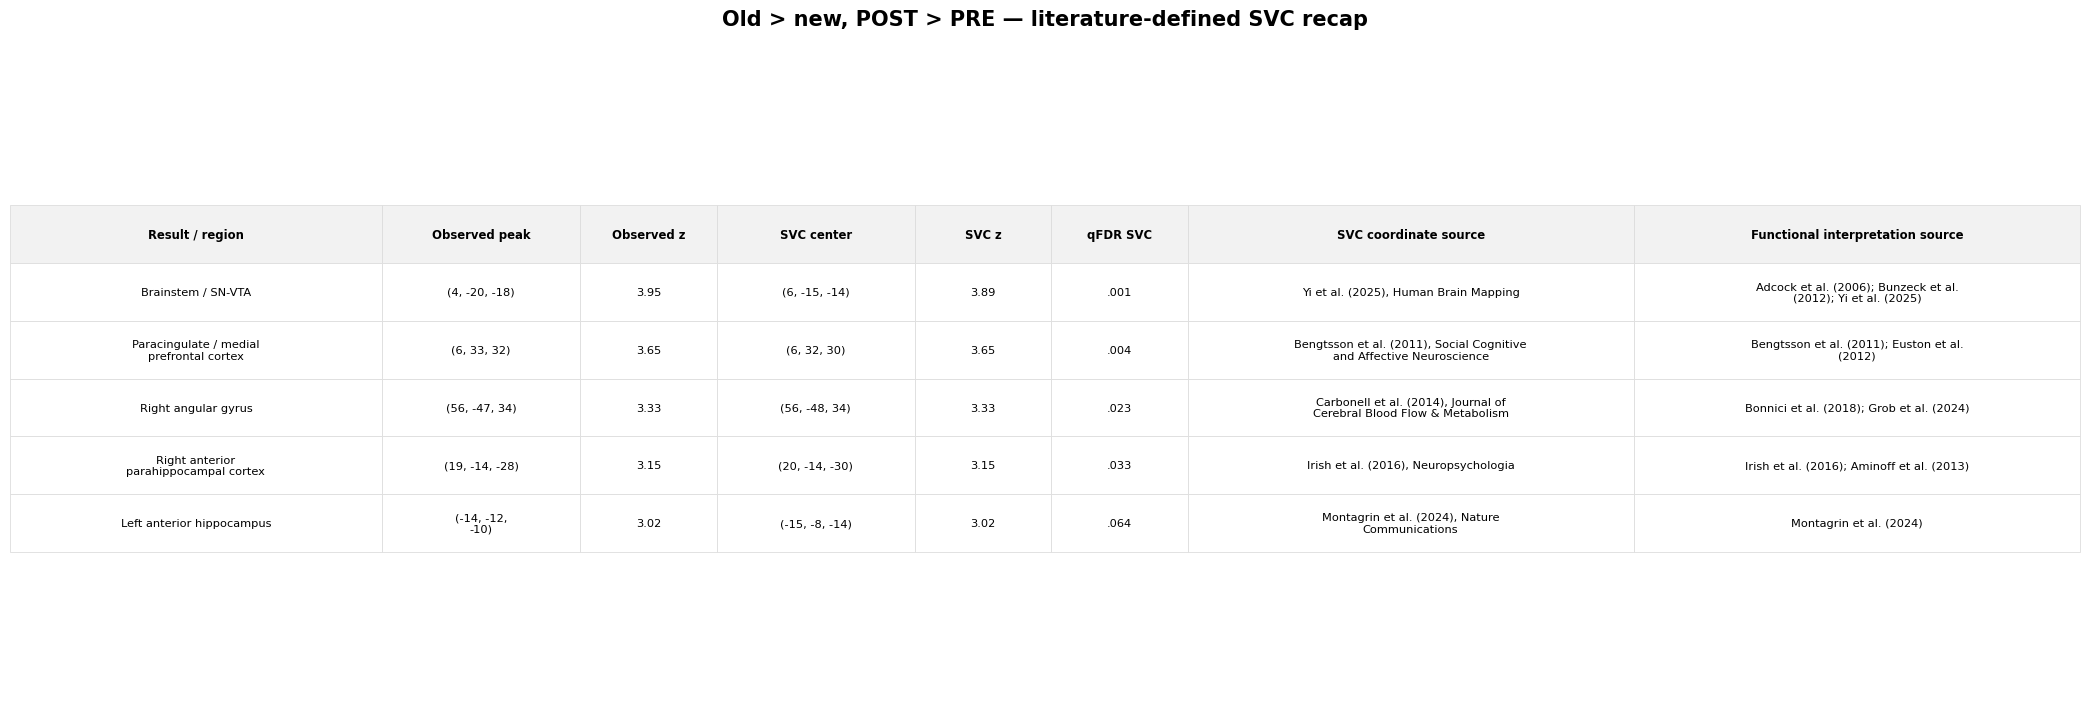

Saved wrapped PNG table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/final_old_new_literature_recap/pre_post_old_new_viewing_glm_old_new_final_literature_SVC_recap_clean_WRAPPED.png


In [31]:
report_table_clean = oldnew_literature_recap_compact[
    [
        "Result / region",
        "Observed peak",
        "Observed z",
        "SVC center",
        "SVC z",
        "qFDR SVC",
        "SVC coordinate source",
        "Functional interpretation source",
    ]
].copy()

clean_png = (
    recap_fig_dir
    / f"{ANALYSIS_NAME}_old_new_final_literature_SVC_recap_clean_WRAPPED.png"
)

save_table_png_wrapped(
    report_table_clean,
    clean_png,
    title="Old > new, POST > PRE — literature-defined SVC recap",
    fontsize=8.2,
    header_fontsize=8.4,
    scale_y=3.0,
    figsize=(21, 7.2),
)